In [36]:
# bootstrap: raiz do projeto
import os, pathlib
_r = pathlib.Path.cwd()
while not (_r / 'CLAUDE.md').exists() and _r != _r.parent:
    _r = _r.parent
os.chdir(_r)

# Experimento — Seleção de Modelo: Valor de Propostas

**Objetivo:** Comparar modelos fixos e abordagens avançadas usando validação cruzada
por séries temporais, para substituir o TPOT com um modelo confiável e rápido.

**Metodologia aplicada de `experimento_qtd.ipynb`:**
- **Parte 1:** Modelos simples com TimeSeriesSplit alinhado ao backup
- **Parte 2:** Seleção de variáveis, tuning, ensembles e pipelines
- **Parte 3:** Pipelines TPOT de produção (avaliação retrospectiva)
- **Seção 4:** Comparação final e seleção do melhor modelo

**Features:** `dia_semana`, `lag_0`(qntd-1), `lag_1..6`(valor-1..6), `lag_7`(fila-1) — **Target:** `valor`

**Correção aplicada:** `DIAS_QUERY` calculado a partir de `DATA_REFERENCIA_MIN`
(data mínima do backup) para cobrir todo o período histórico.

## Imports e preparação

In [37]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from datetime import datetime, timedelta
import hashlib, pickle, os, copy, sys, types

import clickhouse_connect
from workadays import workdays as wd
from sklearn.base import clone
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
import joblib, glob

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
print('Imports OK')

Imports OK


In [38]:
# ==================== CONFIGURAÇÃO ====================
HOST           = '10.101.150.150'
PORT           = 8123
USER           = 'debora_jesus'
PASS           = '3fDsSF1$pe1yDv'
JANELA_DIAS    = 45
N_SPLITS_INNER = 5
INCLUIR_SABADO_TREINO = True

_cache_dir = 'cache'
os.makedirs(_cache_dir, exist_ok=True)

_bkp = pd.read_excel(r'resultados\backup_valor.xlsx')
_col_data = 'Data previsao'
_dp = pd.to_datetime(_bkp[_col_data], errors='coerce').dt.normalize().dropna()

DATA_REFERENCIA     = pd.Timestamp(_dp.max().date())
DATA_REFERENCIA_MIN = pd.Timestamp(_dp.min().date())
N_SPLITS_CV = len(_dp)
# CORREÇÃO: DIAS_QUERY calculado da data MÍNIMA para cobrir todo o backup
DIAS_QUERY  = (datetime.today() - DATA_REFERENCIA_MIN).days + 70 + 10

print(f'Período backup : {DATA_REFERENCIA_MIN.date()} → {DATA_REFERENCIA.date()}')
print(f'N_SPLITS_CV    : {N_SPLITS_CV}  |  intervalo query: {DIAS_QUERY} dias')

Período backup : 2025-02-18 → 2026-04-22
N_SPLITS_CV    : 295  |  intervalo query: 586 dias


In [39]:
# ==================== DADOS (cache 1x/dia; fallback p/ cache antigo se o
# ClickHouse estiver inacessivel -- ex.: de casa sem VPN) ====================
import sys
sys.path.insert(0, 'scripts')
from cache_utils import carregar_com_cache

query = f"""
SELECT
    toStartOfFifteenMinutes(ultimaalteracao) AS Intervalo,
    SUM(valor) AS valor,
    COUNT(propostaid) AS qntd
FROM crefaz.ft_proposta fp
WHERE
    propostaetapaid = 16
    AND propostadecisaoid IS NULL
    AND toDate(ultimaalteracao) BETWEEN toDate(today() - INTERVAL {DIAS_QUERY} DAY) AND toDate(today() - INTERVAL 1 DAY)
GROUP BY Intervalo
"""

query_fila = f"""
WITH cte_total AS (
    SELECT
        prop.propostaid,
        argMax(prop.propostaetapaid, prop.data) AS etapa,
        MAX(toDate(prop.data)) AS Data
    FROM crefazon15m.dbo_propostastatushistorico AS prop
    WHERE prop.data >= today() - INTERVAL {DIAS_QUERY} DAY AND prop.data < today()
    GROUP BY prop.propostaid, toDate(prop.data)
)
SELECT
    tot.Data,
    COUNT(tot.propostaid) AS QUANTIDADE
FROM cte_total AS tot
WHERE tot.etapa = 15
GROUP BY tot.Data
"""

def _consultar_valor():
    client = clickhouse_connect.get_client(host=HOST, port=PORT, username=USER, password=PASS)
    return client.query_df(query), client.query_df(query_fila)

df, df_fila = carregar_com_cache(
    'query_valor',
    [pd.Timestamp.today().date(), DIAS_QUERY, query, query_fila],
    _consultar_valor,
)

df['Intervalo'] = df['Intervalo'].astype(str)
df['data_hora'] = pd.to_datetime(df['Intervalo'].str.split('+').str[0])
df['data']      = pd.to_datetime(df['data_hora'].dt.date)

df_fila['Data'] = pd.to_datetime(df_fila['Data'], yearfirst=True)
df_fila = df_fila.rename(columns={'Data': 'data'})

print(f'Propostas: {len(df)} registros | Fila: {len(df_fila)} dias')


[cache hit] query_valor <- query_valor_f2175cae622b.pkl
Propostas: 19793 registros | Fila: 585 dias


In [40]:
# ==================== FEATURE ENGINEERING ====================
data_referencia = DATA_REFERENCIA
data_min        = DATA_REFERENCIA_MIN - timedelta(days=70)  # buffer de lags antes do 1º fold

print(f'Período FE: {data_min.date()} → {data_referencia.date()}')

df_ag = df[(df['data'] <= data_referencia) & (df['data'] >= data_min)].copy()
df_ag = df_ag.groupby('data').agg({'qntd': 'sum', 'valor': 'sum'}).reset_index()
df_ag['qntd'] = df_ag['qntd'].astype(int)
df_ag = pd.merge(df_ag, df_fila, on='data', how='left')

df_ag['dia_semana'] = df_ag['data'].dt.day_of_week
df_ag['lag_0'] = df_ag['qntd'].shift(1)
df_ag['lag_1'] = df_ag['valor'].shift(1)
df_ag['lag_2'] = df_ag['valor'].shift(2)
df_ag['lag_3'] = df_ag['valor'].shift(3)
df_ag['lag_4'] = df_ag['valor'].shift(4)
df_ag['lag_5'] = df_ag['valor'].shift(5)
df_ag['lag_6'] = df_ag['valor'].shift(6)
df_ag['lag_7'] = df_ag['QUANTIDADE'].shift(1)
df_ag.dropna(inplace=True)
df_ag.reset_index(drop=True, inplace=True)

# Domingos e feriados: excluídos de predição e treino
mask_invalido = df_ag['data'].apply(
    lambda d: d.dayofweek == 6 or bool(wd.is_holiday(d.date(), country='BR'))
)

# Dataset de PREDIÇÃO/TEST: seg–sex, sem feriados
mask_pred = ~mask_invalido & (df_ag['data'].dt.dayofweek < 5)
df_pred   = df_ag[mask_pred].reset_index(drop=True)
dates     = df_pred['data'].reset_index(drop=True)
X         = df_pred.drop(columns=['data', 'qntd', 'QUANTIDADE', 'valor']).astype(float)
y         = df_pred['valor'].astype(float)

# Dataset de TREINO: inclui sábados se flag ativa
mask_train   = ~mask_invalido if INCLUIR_SABADO_TREINO else mask_pred
df_train_all = df_ag[mask_train].reset_index(drop=True)
dates_train  = df_train_all['data'].reset_index(drop=True)
X_train      = df_train_all.drop(columns=['data', 'qntd', 'QUANTIDADE', 'valor']).astype(float)
y_train      = df_train_all['valor'].astype(float)

print(f'Dataset pred  : {len(X)} amostras (seg–sex, não feriado)')
print(f'Dataset treino: {len(X_train)} amostras (inclui sábado={INCLUIR_SABADO_TREINO})')
print(f'Features: {list(X.columns)}')

Período FE: 2024-12-10 → 2026-04-22
Dataset pred  : 337 amostras (seg–sex, não feriado)
Dataset treino: 406 amostras (inclui sábado=True)
Features: ['dia_semana', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']


### Dias especiais — por que cada dia é excluído da base (outliers)

Antes de comparar os modelos, alguns dias são **removidos da base de realizados e preditos**.
O motivo é sempre o mesmo: nesses dias o realizado **não reflete a demanda normal** — ou houve
falha/instabilidade operacional que interrompeu ou represou a captação de propostas, ou é um dia
de atividade atipicamente baixa. Mantê-los penalizaria (ou premiaria) os modelos por **ruído
operacional**, não por capacidade preditiva, distorcendo o MAPE/RMSPE da comparação.

A remoção efetiva acontece na consolidação do ranking, via `mask_dias_excluir(...)`. São três
critérios:

#### (a) Log de Erro operacional — `logs/Log_Erro.xlsx`
Cada evento registra a **data** da falha, o **sistema/causa** e o **Impacto/dias**. A janela de
impacto é contada em **dias úteis** (seg–sex, exclui feriado BR): o 1º dia é o do evento e os
demais são os dias úteis seguintes (a fila represada costuma "vazar" para o(s) dia(s) seguinte(s),
inflando-os). Cada dia da janela é retirado da comparação.

| Data do evento | Sistema / causa | Impacto (dias úteis) | Dias removidos | Por quê |
|---|---|---|---|---|
| 06/02/2025 | BrSCAM | 3 | 06, 07 e 10/02/2025 | Instabilidade do BrSCAM interrompeu a originação; captação represada vaza p/ os dias úteis seguintes. |
| 26/02/2025 | CrefazOn | 2 | 26 e 27/02/2025 | Queda da plataforma interna CrefazOn — propostas não entram normalmente. |
| 05/03/2025 | Carnaval | 2 | 05 e 06/03/2025 | Período de Carnaval: dias úteis, mas com atividade atipicamente baixa. |
| 07/03/2025 | Bacen – Fila Pagamento | 2 | 07 e 10/03/2025 | Falha na fila de pagamento/averbação (Bacen) trava a conclusão das propostas. |
| 24/03/2025 | Enel – Mega | 3 | 24, 25 e 26/03/2025 | Indisponibilidade da integração Enel/Mega (crédito por conta de energia). |
| 22/04/2025 | CrefazOn | 2 | 22 e 23/04/2025 | Instabilidade do CrefazOn. |
| 22/05/2025 | Kamunda – Enel | 2 | 22 e 23/05/2025 | Falha na integração Kamunda/Enel. |
| 12/06/2025 | Unico – CrefazOn | 2 | 12 e 13/06/2025 | Falha na validação de identidade (Unico) integrada ao CrefazOn. |
| 23/06/2025 | Code – Mega | 1 | 23/06/2025 | Indisponibilidade do sistema Mega/Code. |
| 27/06/2025 | CrefazOn | 1 | 27/06/2025 | Instabilidade do CrefazOn. |
| 03/07/2025 | CrefazOn – Cobrança | 1 | 03/07/2025 | Falha no módulo de cobrança do CrefazOn. |
| 13/10/2025 | CrefazOn | 2 | 13 e 14/10/2025 | Queda do CrefazOn. |
| 24/10/2025 | E-Consulter | 2 | 24 e 27/10/2025 | Indisponibilidade da consulta/bureau E-Consulter. |
| 29/10/2025 | Microsoft | 1 | 29/10/2025 | Indisponibilidade de serviços Microsoft que afetou a operação. |
| 04/12/2025 | Crivo | 1 | 04/12/2025 | Falha no motor de crédito/score Crivo. |
| 05/02/2026 | RBM | 2 | 05 e 06/02/2026 | Indisponibilidade do RBM. |
| 02/04/2026 | RBM | 2 | 02 e 06/04/2026 | Indisponibilidade do RBM (06/04 é o próximo dia útil após o feriado). |

> Total de **31 dias úteis** marcados por erro operacional no `Log_Erro` (alguns podem estar fora
> da janela de comparação atual; só são efetivamente descontados os que caem no período avaliado).
> A função `sistema_erro(dia)` devolve o sistema responsável por um dia (ou `'Sem Erro'`).

#### (b) Vésperas atípicas (fixas)
**24/dez** (véspera de Natal) e **31/dez** (véspera de ano novo) são sempre removidas: expediente
reduzido e demanda muito abaixo do normal, sem relação com a qualidade do modelo.

#### (c) Outliers manuais — `DIAS_EXCLUIR_OUTLIERS`
Lista para datas adicionais a remover caso se identifique um dia anômalo não coberto por (a)/(b).
**No momento está vazia** (`[]`).


In [41]:
# ==================== DIAS ESPECIAIS / LOG DE ERRO ====================
# Conjunto de dias REMOVIDOS da base de realizados/preditos (aplicado na consolidacao):
#   (a) Log_Erro: dia do evento + (Impacto/dias - 1) dias UTEIS seguintes (dias de impacto).
#   (b) Vespera de Natal (24/dez), ano novo (31/dez) e de Carnaval -- dias atipicos de baixa atividade.
#   (c) DIAS_EXCLUIR_OUTLIERS: datas adicionais manuais.

def _bdays_from(_start, _n):
    """Primeiros _n dias UTEIS (seg-sex, exclui feriado BR) a partir de _start (inclusive)."""
    _out, _d = [], pd.Timestamp(_start).normalize()
    while len(_out) < _n:
        if _d.weekday() < 5 and not wd.is_holiday(_d.date(), country='BR'):
            _out.append(_d)
        _d += pd.Timedelta(days=1)
    return _out

# ---- Log de erros operacionais (logs/Log_Erro.xlsx) ----
LOG_ERRO_PATH = r'logs\Log_Erro.xlsx'
_mapa_erro = {}   # dia (Timestamp normalizado) -> sistema(s) em erro
try:
    _log_erro = pd.read_excel(LOG_ERRO_PATH)
    _log_erro['Data'] = pd.to_datetime(_log_erro['Data'], errors='coerce').dt.normalize()
    _log_erro['Impacto/dias'] = pd.to_numeric(_log_erro['Impacto/dias'], errors='coerce').fillna(1).astype(int)
    for _, _r in _log_erro.dropna(subset=['Data']).iterrows():
        _nome = str(_r['Sistema Erro']).strip()
        for _d in _bdays_from(_r['Data'], max(int(_r['Impacto/dias']), 1)):   # janela em dias UTEIS
            _mapa_erro[_d] = _nome if _d not in _mapa_erro else f'{_mapa_erro[_d]} + {_nome}'
    print(f'Log_Erro: {len(_log_erro)} eventos | dias de impacto (uteis): {len(_mapa_erro)}')
except Exception as _e:
    print(f'[Log_Erro indisponivel] {_e} -- seguindo sem remocao por erro operacional')

DIAS_ERRO = set(_mapa_erro)   # dias uteis impactados por erro operacional

def sistema_erro(d):
    """Sistema em erro no dia (1o dia = coluna Data; janela = Impacto/dias dias UTEIS). 'Sem Erro' se nao houver."""
    if d is None or pd.isna(d):
        return 'Sem Erro'
    return _mapa_erro.get(pd.Timestamp(d).normalize(), 'Sem Erro')

# Datas adicionais manuais a remover da base (alem de Log_Erro e vesperas)
DIAS_EXCLUIR_OUTLIERS = []

# ---- Vespera de Carnaval (Carnaval seg = Pascoa - 48 dias; NAO e feriado formal) ----
def _pascoa(_ano):
    a = _ano % 19; b = _ano // 100; c = _ano % 100; d = b // 4; e = b % 4
    f = (b + 8) // 25; g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30; i = c // 4; k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7; m = (a + 11 * h + 22 * l) // 451
    _mes = (h + l - 7 * m + 114) // 31; _dia = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(_ano, _mes, _dia)

def _vespera_carnaval(_ano):
    """Ultimo dia UTIL antes da segunda-feira de Carnaval (a sexta anterior, em geral)."""
    _d = _pascoa(_ano) - pd.Timedelta(days=48) - pd.Timedelta(days=1)
    while _d.weekday() >= 5 or wd.is_holiday(_d.date(), country='BR'):
        _d -= pd.Timedelta(days=1)
    return _d.normalize()

DIAS_VESPERA_CARNAVAL = {_vespera_carnaval(_y) for _y in range(2020, 2036)}

def mask_dias_excluir(serie_datas):
    """Mask booleana p/ remover da base de realizados/preditos E do TREINO:
    Log_Erro (dias de impacto) + vespera de Natal/ano novo (24 e 31/dez)
    + vespera de Carnaval + DIAS_EXCLUIR_OUTLIERS."""
    _dn = pd.to_datetime(serie_datas).dt.normalize()
    _m  = ((_dn.dt.month == 12) & (_dn.dt.day.isin([24, 31]))) | _dn.isin(DIAS_ERRO)
    _m  = _m | _dn.isin(DIAS_VESPERA_CARNAVAL)
    if DIAS_EXCLUIR_OUTLIERS:
        _m = _m | _dn.isin(set(pd.to_datetime(DIAS_EXCLUIR_OUTLIERS).normalize()))
    return _m

print(f'Dias especiais definidos | dias de erro={len(DIAS_ERRO)} | vesperas: 24, 31/dez e Carnaval')

Log_Erro: 17 eventos | dias de impacto (uteis): 31
Dias especiais definidos | dias de erro=31 | vesperas: 24, 31/dez e Carnaval


---
## PARTE 1 — Modelos Simples
Cada modelo avaliado com `TimeSeriesSplit(n_splits=N_SPLITS_CV, test_size=1, max_train_size=JANELA_DIAS)` — 1 fold por dia do backup.

In [42]:
MODELOS = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'HuberRegressor':   Pipeline([('scaler', StandardScaler()), ('huber', HuberRegressor(max_iter=300))]),
    'RandomForest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'ExtraTrees':       ExtraTreesRegressor(n_estimators=200, random_state=42),
    'XGBoost':          XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'SVR':              Pipeline([('scaler', StandardScaler()), ('svr', SVR(C=10, epsilon=0.1))]),
    'KNN':              KNeighborsRegressor(n_neighbors=5),
}

In [43]:
tscv = TimeSeriesSplit(n_splits=min(N_SPLITS_CV, len(X) - 1), test_size=1, max_train_size=JANELA_DIAS)

def get_train(train_idx):
    """Retorna X_tr, y_tr: inclui sábados se INCLUIR_SABADO_TREINO=True."""
    if INCLUIR_SABADO_TREINO:
        d0, d1 = dates.iloc[train_idx[0]], dates.iloc[train_idx[-1]]
        # remove dias atipicos (Log_Erro + vesperas 24/31/Carnaval) TAMBEM do treino
        mask = (dates_train >= d0) & (dates_train <= d1) & (~mask_dias_excluir(dates_train))
        return X_train.loc[mask].reset_index(drop=True), y_train.loc[mask].reset_index(drop=True)
    _sel = np.asarray(train_idx)[~mask_dias_excluir(dates.iloc[list(train_idx)]).values]
    return X.iloc[_sel], y.iloc[_sel]

resultados_p1 = {}
detalhes_p1   = []

In [44]:
_key_p1   = hashlib.md5(
    f"{DATA_REFERENCIA.date()}|{JANELA_DIAS}|{N_SPLITS_CV}|{INCLUIR_SABADO_TREINO}|rmatip|{sorted(MODELOS)}".encode()
).hexdigest()[:12]
_cache_p1 = os.path.join(_cache_dir, f'p1v_{_key_p1}.pkl')

_loaded = False
if os.path.exists(_cache_p1):
    try:
        with open(_cache_p1, 'rb') as _f:
            resultados_p1, detalhes_p1 = pickle.load(_f)
        _loaded = True
        print(f'[cache hit] P1 ← {_cache_p1}')
        for nome, mapes in resultados_p1.items():
            print(f'{nome:<25} MAPE médio={np.mean(mapes):6.2f}%  desvio={np.std(mapes):5.2f}%')
    except Exception as e:
        print(f'[cache inválido] {e} — retreinando...')

if not _loaded:
    resultados_p1 = {}
    detalhes_p1   = []
    for nome, modelo in MODELOS.items():
        mapes = []
        for train_idx, test_idx in tscv.split(X):
            X_tr, y_tr = get_train(train_idx)
            X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
            if len(X_tr) < 8:
                continue
            try:
                m = clone(modelo)
                m.fit(X_tr, y_tr)
                y_pred_fold = m.predict(X_te)
            except Exception:
                continue
            mape_fold = mean_absolute_percentage_error(y_te, y_pred_fold) * 100
            mapes.append(mape_fold)
            detalhes_p1.append({
                'Modelo':          nome,
                'Dia Prevista':    dates.iloc[test_idx[0]].date(),
                'Treino Início':   dates.iloc[train_idx[0]].date(),
                'Treino Fim':      dates.iloc[train_idx[-1]].date(),
                'Valor Previsto':  round(float(y_pred_fold[0]), 1),
                'Valor Realizado': round(float(y_te.values[0]), 1),
                'MAPE (%)':        round(mape_fold, 2),
            })
        if mapes:
            resultados_p1[nome] = mapes
            print(f'{nome:<25} MAPE médio={np.mean(mapes):6.2f}%  desvio={np.std(mapes):5.2f}%')
    try:
        with open(_cache_p1, 'wb') as _f:
            pickle.dump((resultados_p1, detalhes_p1), _f)
        print(f'\n[cache saved] P1 → {_cache_p1}')
    except Exception as e:
        print(f'[cache erro] {e}')

[cache hit] P1 ← cache\p1v_6abb6d6df9c6.pkl
LinearRegression          MAPE médio= 15.28%  desvio=21.17%
Ridge                     MAPE médio= 15.11%  desvio=21.06%
HuberRegressor            MAPE médio= 10.93%  desvio=12.88%
RandomForest              MAPE médio=  9.84%  desvio=14.31%
GradientBoosting          MAPE médio= 10.12%  desvio=14.65%
ExtraTrees                MAPE médio=  9.96%  desvio=13.64%
XGBoost                   MAPE médio= 10.08%  desvio=14.13%
SVR                       MAPE médio= 11.58%  desvio=12.90%
KNN                       MAPE médio= 13.59%  desvio=16.39%


In [45]:
df_detalhes_p1 = pd.DataFrame(detalhes_p1)
df_detalhes_p1['Intervalo Treinamento'] = (
    df_detalhes_p1['Treino Início'].astype(str) + ' → ' + df_detalhes_p1['Treino Fim'].astype(str)
)
df_detalhes_p1 = (
    df_detalhes_p1[['Modelo', 'Dia Prevista', 'Intervalo Treinamento', 'Valor Previsto', 'Valor Realizado', 'MAPE (%)']]
    .sort_values(['Dia Prevista', 'MAPE (%)'])
    .reset_index(drop=True)
)
df_detalhes_p1

,Modelo,Dia Prevista,Intervalo Treinamento,Valor Previsto,Valor Realizado,MAPE (%)
0,XGBoost,2025-02-17,2024-12-17 → 2025-02-14,4315165.00,4754598.00,9.24
1,RandomForest,2025-02-17,2024-12-17 → 2025-02-14,4259959.60,4754598.00,10.40
2,ExtraTrees,2025-02-17,2024-12-17 → 2025-02-14,4240237.30,4754598.00,10.82
3,HuberRegressor,2025-02-17,2024-12-17 → 2025-02-14,4222009.60,4754598.00,11.20
4,GradientBoosting,2025-02-17,2024-12-17 → 2025-02-14,4170005.00,4754598.00,12.30
...,...,...,...,...,...,...
2650,KNN,2026-04-22,2026-02-12 → 2026-04-20,5435790.70,5318804.30,2.20
2651,GradientBoosting,2026-04-22,2026-02-12 → 2026-04-20,5504996.40,5318804.30,3.50
2652,XGBoost,2026-04-22,2026-02-12 → 2026-04-20,5547382.00,5318804.30,4.30
2653,ExtraTrees,2026-04-22,2026-02-12 → 2026-04-20,5569287.80,5318804.30,4.71


In [46]:
def build_table(resultados):
    rows = {}
    for nome, mapes in resultados.items():
        n = len(mapes)
        rows[nome] = {
            'MAPE Médio (%)': round(np.mean(mapes), 2),
            'Mediana (%)':    round(np.median(mapes), 2),
            'Q1 (%)':         round(np.percentile(mapes, 25), 2),
            'Q3 (%)':         round(np.percentile(mapes, 75), 2),
            'Desvio (%)':     round(np.std(mapes), 2),
            'Mín (%)':        round(np.min(mapes), 2),
            'Máx (%)':        round(np.max(mapes), 2),
            '< 1%':           f"{sum(m <   1 for m in mapes)}/{n}",
            '< 2%':           f"{sum(m <   2 for m in mapes)}/{n}",
            '< 3%':           f"{sum(m <   3 for m in mapes)}/{n}",
            '< 5%':           f"{sum(m <   5 for m in mapes)}/{n}",
            '< 10%':          f"{sum(m <  10 for m in mapes)}/{n}",
            '< 50%':          f"{sum(m <  50 for m in mapes)}/{n}",
            '< 100%':         f"{sum(m < 100 for m in mapes)}/{n}",
            '< 300%':         f"{sum(m < 300 for m in mapes)}/{n}",
        }
    return pd.DataFrame(rows).T.sort_values('MAPE Médio (%)').rename_axis('Pipeline').reset_index()

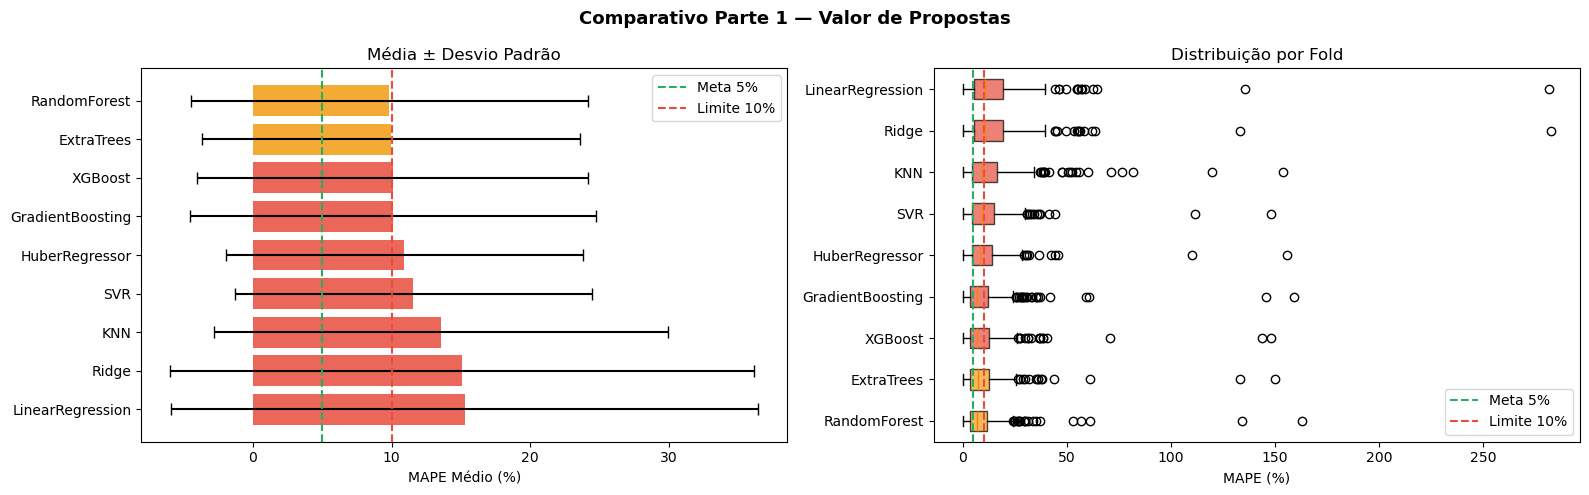

In [47]:
def plot_comparativo(resultados, titulo):
    df_plot = build_table(resultados)
    nomes   = df_plot['Pipeline'].tolist()
    medias  = df_plot['MAPE Médio (%)'].values
    desvios = df_plot['Desvio (%)'].values
    cores   = ['#2ecc71' if m < 5 else '#f39c12' if m < 10 else '#e74c3c' for m in medias]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(5, len(nomes) * 0.5)))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    ax1.barh(nomes, medias, xerr=desvios, color=cores, alpha=0.85, capsize=4)
    ax1.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax1.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax1.set_xlabel('MAPE Médio (%)')
    ax1.set_title('Média ± Desvio Padrão')
    ax1.legend(); ax1.invert_yaxis()

    bp = ax2.boxplot([resultados[n] for n in nomes], labels=nomes, vert=False, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor); patch.set_alpha(0.7)
    ax2.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax2.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax2.set_xlabel('MAPE (%)')
    ax2.set_title('Distribuição por Fold')
    ax2.legend()

    plt.tight_layout(); plt.show()

plot_comparativo(resultados_p1, 'Comparativo Parte 1 — Valor de Propostas')

In [48]:
df_p1     = build_table(resultados_p1)
melhor_p1 = df_p1['Pipeline'].iloc[0]
top3      = [n for n in df_p1['Pipeline'][:3].tolist() if n in MODELOS]

print(f'Melhor modelo P1 : {melhor_p1}   MAPE={df_p1["MAPE Médio (%)"].iloc[0]:.2f}%')
print(f'Top-3            : {top3}')
display(df_p1)

Melhor modelo P1 : RandomForest   MAPE=9.84%
Top-3            : ['RandomForest', 'ExtraTrees', 'XGBoost']


,Pipeline,MAPE Médio (%),Mediana (%),Q1 (%),Q3 (%),Desvio (%),Mín (%),Máx (%),< 1%,< 2%,< 3%,< 5%,< 10%,< 50%,< 100%,< 300%
0,RandomForest,9.84,6.89,3.16,11.52,14.31,0.04,162.81,25/295,48/295,72/295,107/295,198/295,290/295,293/295,295/295
1,ExtraTrees,9.96,7.10,3.17,12.28,13.64,0.01,149.74,23/295,46/295,65/295,104/295,196/295,292/295,293/295,295/295
2,XGBoost,10.08,6.95,3.36,12.47,14.13,0.08,148.16,21/295,39/295,67/295,114/295,195/295,292/295,293/295,295/295
3,GradientBoosting,10.12,6.57,3.52,11.79,14.65,0.15,159.13,22/295,39/295,60/295,112/295,198/295,291/295,293/295,295/295
4,HuberRegressor,10.93,8.34,4.16,13.95,12.88,0.03,155.79,13/295,31/295,51/295,90/295,170/295,293/295,293/295,295/295
5,SVR,11.58,9.08,4.57,14.88,12.90,0.02,148.22,19/295,32/295,50/295,79/295,157/295,293/295,293/295,295/295
6,KNN,13.59,9.29,4.43,16.37,16.39,0.02,153.73,16/295,32/295,50/295,92/295,158/295,284/295,293/295,295/295
7,Ridge,15.11,10.63,5.20,19.03,21.06,0.06,282.33,11/295,27/295,40/295,73/295,140/295,285/295,293/295,295/295
8,LinearRegression,15.28,10.68,5.19,19.19,21.17,0.06,281.74,12/295,29/295,41/295,70/295,139/295,285/295,293/295,295/295


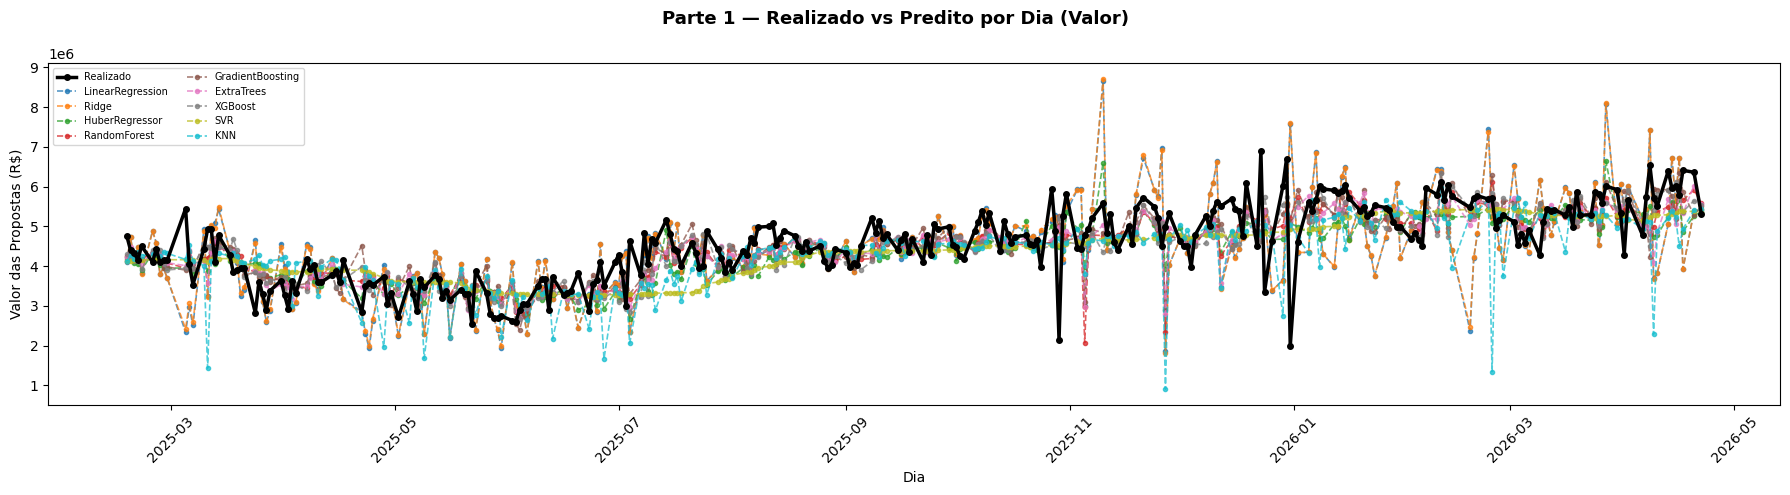

In [49]:
# ==================== SÉRIE TEMPORAL PARTE 1 ====================
df_detalhes_p1_plot = pd.DataFrame(detalhes_p1)

fig, ax = plt.subplots(figsize=(18, 5))
fig.suptitle('Parte 1 — Realizado vs Predito por Dia (Valor)', fontsize=13, fontweight='bold')

realizado = (
    df_detalhes_p1_plot.drop_duplicates('Dia Prevista')
    .sort_values('Dia Prevista').set_index('Dia Prevista')['Valor Realizado']
)
ax.plot(realizado.index, realizado.values, color='black', lw=2.5, marker='o', ms=4, label='Realizado', zorder=5)

cmap_p1 = plt.cm.get_cmap('tab10', len(MODELOS))
for i, nome_m in enumerate(df_detalhes_p1_plot['Modelo'].unique()):
    df_m = df_detalhes_p1_plot[df_detalhes_p1_plot['Modelo'] == nome_m].sort_values('Dia Prevista')
    ax.plot(df_m['Dia Prevista'], df_m['Valor Previsto'], '--', marker='o', ms=3, lw=1.2,
            color=cmap_p1(i), label=nome_m, alpha=0.75)

ax.set_xlabel('Dia'); ax.set_ylabel('Valor das Propostas (R$)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

---
## PARTE 2 — Abordagens Avançadas
Replica o que o TPOT faz de forma transparente e controlada:
- **Seleção de variáveis** — SelectKBest com diferentes k
- **Tuning de hiperparâmetros** — RandomizedSearchCV com CV interno
- **Ensembles** — VotingRegressor e StackingRegressor
- **Pipelines** — pré-processamento + modelo

In [50]:
detalhes_p2   = []
resultados_p2 = {}

In [51]:
# ---- Definições para tuning ----
param_grids = {
    'GradientBoosting': {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [2, 3, 4, 5],
        'learning_rate':    [0.03, 0.05, 0.1, 0.2],
        'subsample':        [0.7, 0.8, 0.9, 1.0],
        'min_samples_leaf': [1, 2, 3],
    },
    'XGBoost': {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [2, 3, 4, 5],
        'learning_rate':    [0.03, 0.05, 0.1, 0.2],
        'subsample':        [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'reg_alpha':        [0, 0.1, 0.5],
    },
    'RandomForest': {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 3, 5, 7, 10],
        'min_samples_split': [2, 4, 6],
        'min_samples_leaf':  [1, 2, 3],
        'max_features':      ['sqrt', 'log2', None],
    },
}

In [52]:
# ---- Definição de pipelines ----
pipelines_adv = {
    'Poly(2) + Ridge':           Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    'Scaler + XGBoost':          Pipeline([('scaler', StandardScaler()), ('xgb', XGBRegressor(n_estimators=200, random_state=42, verbosity=0))]),
    'Scaler + GradientBoosting': Pipeline([('scaler', StandardScaler()), ('gbm', GradientBoostingRegressor(n_estimators=200, random_state=42))]),
    'PCA(6) + GradientBoosting': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=6)), ('gbm', GradientBoostingRegressor(n_estimators=200, random_state=42))]),
}

In [53]:
from joblib import Parallel, delayed
import time as _time

# -1 = todos os núcleos; ajuste para N se quiser limitar
N_JOBS_P2 = -1

n_features   = X.shape[1]
cands_tuning = [n for n in top3 if n in param_grids]

_key_p2   = hashlib.md5(
    f"{DATA_REFERENCIA.date()}|{JANELA_DIAS}|{N_SPLITS_CV}|{INCLUIR_SABADO_TREINO}|rmatip|{top3}|{n_features}|{sorted(pipelines_adv)}".encode()
).hexdigest()[:12]
_cache_p2 = os.path.join(_cache_dir, f'p2v_{_key_p2}.pkl')

_loaded = False
if os.path.exists(_cache_p2):
    try:
        with open(_cache_p2, 'rb') as _f:
            resultados_p2, detalhes_p2 = pickle.load(_f)
        _loaded = True
        print(f'[cache hit] P2 ← {_cache_p2}')
        for nome, mapes in resultados_p2.items():
            print(f'{nome:<50} {np.mean(mapes):6.2f}% ± {np.std(mapes):5.2f}%')
    except Exception as e:
        print(f'[cache inválido] {e} — retreinando...')

if not _loaded:
    resultados_p2 = {}
    detalhes_p2   = []
    _tscv_splits  = list(tscv.split(X))  # pré-materializa para compartilhar entre threads

    # ---- helpers de fold (closures; threads compartilham escopo do notebook) ----
    def _fold_skb(k, mn, ti, tei):
        X_tr, y_tr = get_train(ti)
        X_te, y_te = X.iloc[tei], y.iloc[tei]
        if len(X_tr) < 8: return None
        try:
            sel = SelectKBest(f_regression, k=k)
            Xtr2 = sel.fit_transform(X_tr, y_tr); Xte2 = sel.transform(X_te)
            m = clone(MODELOS[mn]); m.fit(Xtr2, y_tr); yp = m.predict(Xte2)
            mape = mean_absolute_percentage_error(y_te, yp) * 100
            return mape, {'Dia Prevista': dates.iloc[tei[0]].date(),
                'Valor Previsto': round(float(yp[0]),1), 'Valor Realizado': round(float(y_te.values[0]),1)}
        except: return None

    def _fold_pipe(est, ti, tei, min_tr=8):
        X_tr, y_tr = get_train(ti)
        X_te, y_te = X.iloc[tei], y.iloc[tei]
        if len(X_tr) < min_tr: return None
        try:
            m = clone(est); m.fit(X_tr, y_tr); yp = m.predict(X_te)
            mape = mean_absolute_percentage_error(y_te, yp) * 100
            return mape, {'Dia Prevista': dates.iloc[tei[0]].date(),
                'Valor Previsto': round(float(yp[0]),1), 'Valor Realizado': round(float(y_te.values[0]),1)}
        except: return None

    def _processar(nome, raw):
        mapes, dets = [], []
        for r in (raw or []):
            if r:
                mape, det = r; mapes.append(mape)
                dets.append({'Modelo': nome, **det})
        return mapes, dets

    # ---- ETA tracker ----
    _n_skb   = (n_features - 3) * min(2, len(top3))
    _n_total = _n_skb + len(cands_tuning) + 2 + len(pipelines_adv)
    _tempos  = []; _count_p2 = [0]; _t0_p2 = _time.time()

    def _log_p2(nome, mapes, t_el):
        _tempos.append(t_el); _count_p2[0] += 1
        eta = np.mean(_tempos) * (_n_total - _count_p2[0])
        tag = f'[{t_el:.1f}s | ETA {eta:.0f}s]'
        if mapes: print(f'{nome:<52} {np.mean(mapes):6.2f}% ± {np.std(mapes):5.2f}%  {tag}')
        else:     print(f'{nome:<52} sem resultados  {tag}')

    # ---- 2a: SelectKBest — folds paralelos via threads ----
    for k in range(3, n_features):
        for mn in top3[:2]:
            nome = f'SelectKBest(k={k})+{mn}'
            t0 = _time.time()
            raw = Parallel(n_jobs=N_JOBS_P2, prefer='threads')(
                delayed(_fold_skb)(k, mn, ti, tei) for ti, tei in _tscv_splits
            )
            mapes, dets = _processar(nome, raw)
            _log_p2(nome, mapes, _time.time()-t0)
            if mapes: resultados_p2[nome] = mapes; detalhes_p2.extend(dets)

    # ---- 2b: Tuning — sequencial, n_jobs=-1 no inner CV ----
    for mn in cands_tuning:
        nome = f'{mn} (tuned)'
        t0 = _time.time(); mapes = []; dets = []
        for ti, tei in _tscv_splits:
            X_tr, y_tr = get_train(ti)
            X_te, y_te = X.iloc[tei], y.iloc[tei]
            if len(X_tr) < 12: continue
            try:
                n_in = min(N_SPLITS_INNER, len(X_tr)-1)
                s = RandomizedSearchCV(clone(MODELOS[mn]), param_grids[mn], n_iter=20,
                    cv=TimeSeriesSplit(n_splits=n_in, test_size=1),
                    scoring='neg_mean_absolute_percentage_error', random_state=42, n_jobs=-1)
                s.fit(X_tr, y_tr); yp = s.best_estimator_.predict(X_te)
                mape = mean_absolute_percentage_error(y_te, yp) * 100
                mapes.append(mape)
                dets.append({'Modelo': nome, 'Dia Prevista': dates.iloc[tei[0]].date(),
                    'Valor Previsto': round(float(yp[0]),1), 'Valor Realizado': round(float(y_te.values[0]),1)})
            except: continue
        _log_p2(nome, mapes, _time.time()-t0)
        if mapes: resultados_p2[nome] = mapes; detalhes_p2.extend(dets)

    # ---- 2c: Ensembles — folds paralelos via threads ----
    for _ens_nome, _ens_est in [
        (f'VotingRegressor ({" + ".join(top3)})', VotingRegressor([(n, clone(MODELOS[n])) for n in top3])),
        ('StackingRegressor (top3 + Ridge)', StackingRegressor(
            estimators=[(n, clone(MODELOS[n])) for n in top3],
            final_estimator=Ridge(), cv=TimeSeriesSplit(n_splits=3, test_size=1),
        )),
    ]:
        t0 = _time.time()
        raw = Parallel(n_jobs=N_JOBS_P2, prefer='threads')(
            delayed(_fold_pipe)(_ens_est, ti, tei, min_tr=12) for ti, tei in _tscv_splits
        )
        mapes, dets = _processar(_ens_nome, raw)
        _log_p2(_ens_nome, mapes, _time.time()-t0)
        if mapes: resultados_p2[_ens_nome] = mapes; detalhes_p2.extend(dets)

    # ---- 2d: Pipelines avançadas — folds paralelos via threads ----
    for nome_pipe, pipe in pipelines_adv.items():
        t0 = _time.time()
        raw = Parallel(n_jobs=N_JOBS_P2, prefer='threads')(
            delayed(_fold_pipe)(pipe, ti, tei) for ti, tei in _tscv_splits
        )
        mapes, dets = _processar(nome_pipe, raw)
        _log_p2(nome_pipe, mapes, _time.time()-t0)
        if mapes: resultados_p2[nome_pipe] = mapes; detalhes_p2.extend(dets)

    print(f'\nP2 concluído em {(_time.time()-_t0_p2)/60:.1f} min  ({_count_p2[0]}/{_n_total} variantes)')
    try:
        with open(_cache_p2, 'wb') as _f:
            pickle.dump((resultados_p2, detalhes_p2), _f)
        print(f'[cache saved] P2 → {_cache_p2}')
    except Exception as e:
        print(f'[cache erro] {e}')

[cache hit] P2 ← cache\p2v_07967027a8fc.pkl
SelectKBest(k=3)+RandomForest                       10.55% ± 13.77%
SelectKBest(k=3)+ExtraTrees                         10.92% ± 12.59%
SelectKBest(k=4)+RandomForest                       10.42% ± 15.09%
SelectKBest(k=4)+ExtraTrees                         10.48% ± 13.05%
SelectKBest(k=5)+RandomForest                       10.00% ± 14.60%
SelectKBest(k=5)+ExtraTrees                         10.15% ± 13.27%
SelectKBest(k=6)+RandomForest                        9.95% ± 14.54%
SelectKBest(k=6)+ExtraTrees                         10.13% ± 13.32%
SelectKBest(k=7)+RandomForest                        9.93% ± 14.49%
SelectKBest(k=7)+ExtraTrees                          9.94% ± 13.43%
SelectKBest(k=8)+RandomForest                        9.79% ± 14.47%
SelectKBest(k=8)+ExtraTrees                          9.90% ± 13.64%
RandomForest (tuned)                                 9.93% ± 14.05%
XGBoost (tuned)                                     10.09% ± 14.49%
Voti

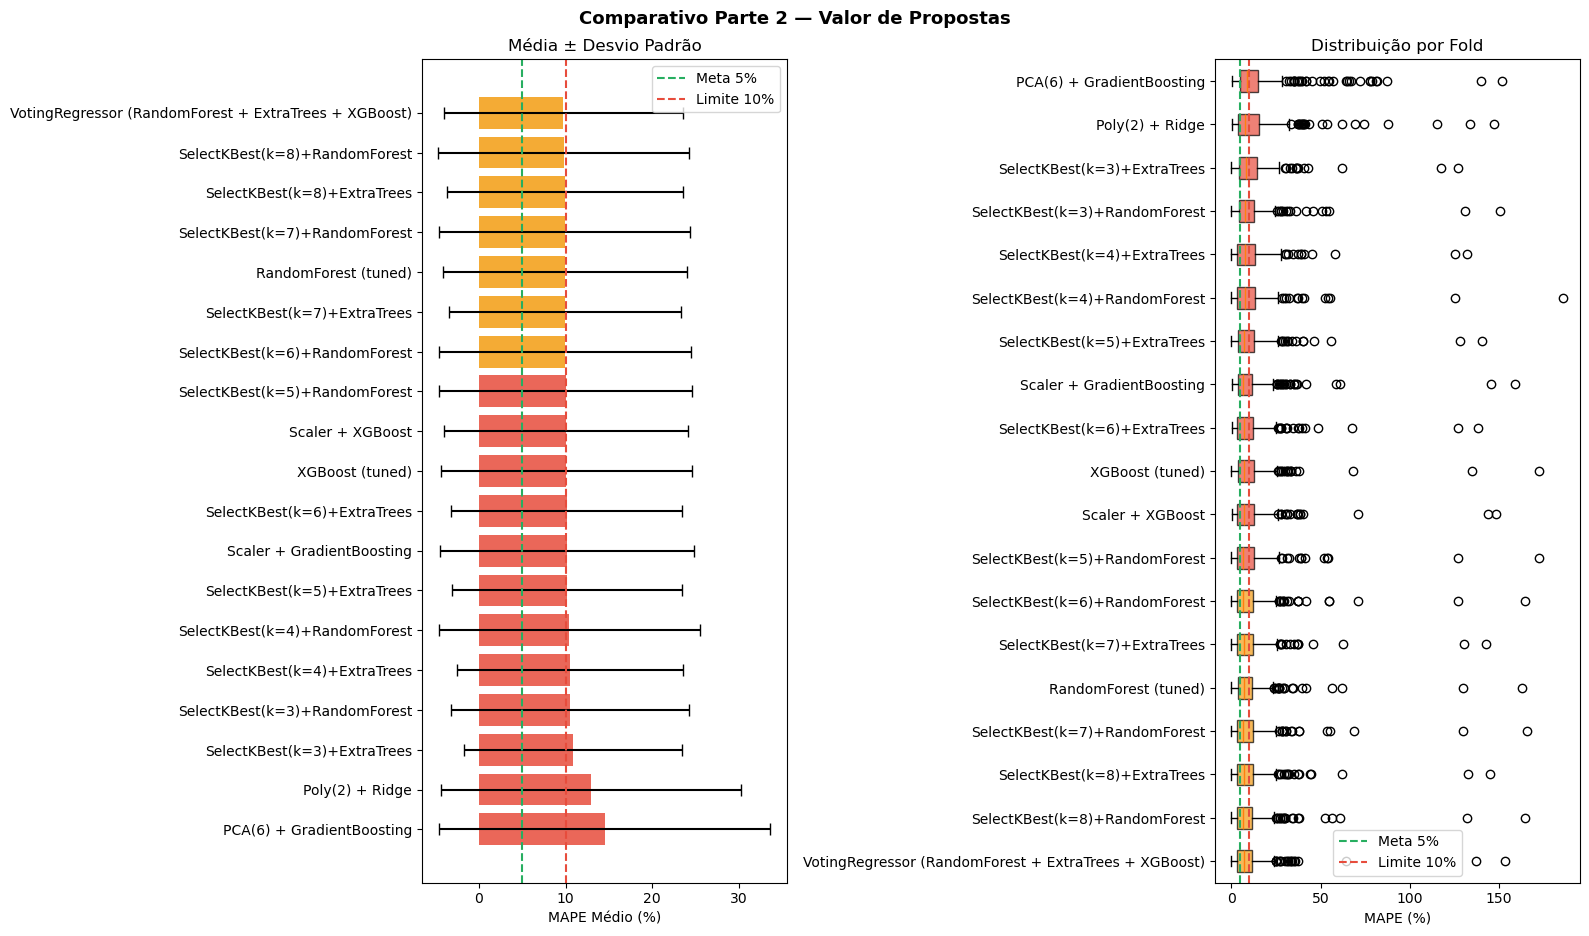

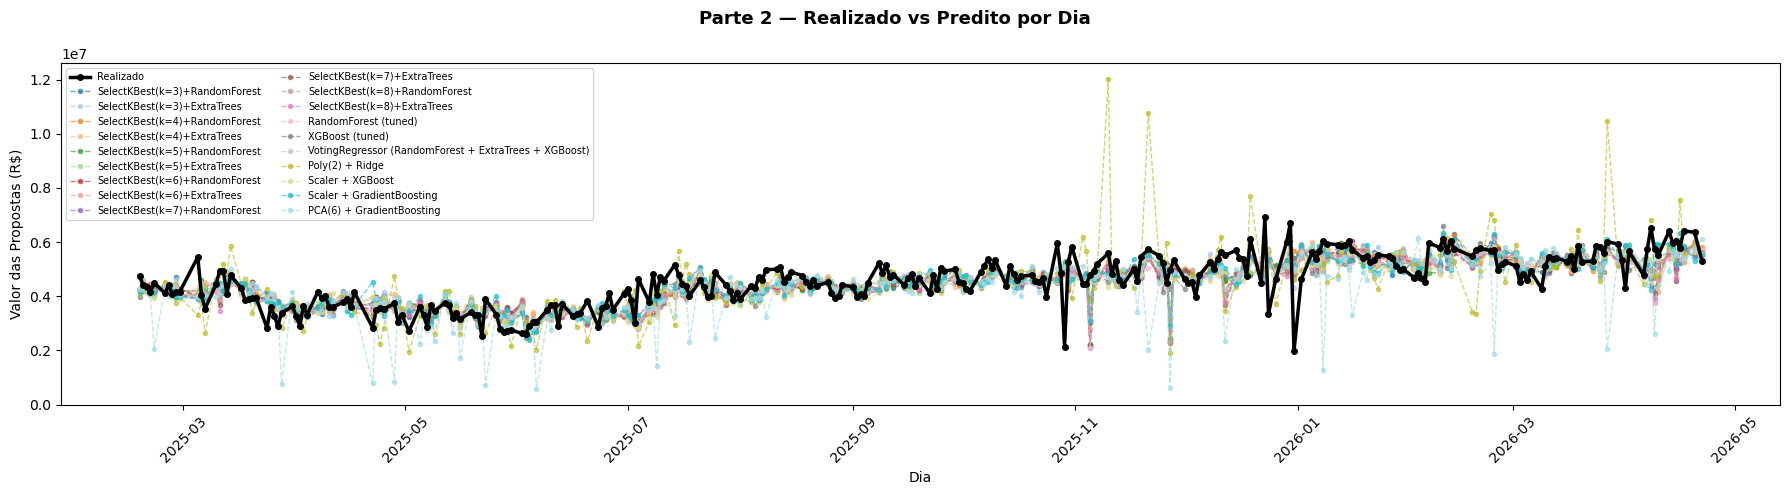

In [54]:
# ==================== SÉRIE TEMPORAL PARTE 2 ====================
df_detalhes_p2 = pd.DataFrame(detalhes_p2)

if not df_detalhes_p2.empty:
    plot_comparativo(resultados_p2, 'Comparativo Parte 2 — Valor de Propostas')

    fig, ax = plt.subplots(figsize=(18, 5))
    fig.suptitle('Parte 2 — Realizado vs Predito por Dia', fontsize=13, fontweight='bold')
    realizado2 = (
        df_detalhes_p2.drop_duplicates('Dia Prevista')
        .sort_values('Dia Prevista').set_index('Dia Prevista')['Valor Realizado']
    )
    ax.plot(realizado2.index, realizado2.values, color='black', lw=2.5, marker='o', ms=4, label='Realizado', zorder=5)
    cmap_p2 = plt.cm.get_cmap('tab20', len(resultados_p2))
    for i, nome_m in enumerate(df_detalhes_p2['Modelo'].unique()):
        df_m = df_detalhes_p2[df_detalhes_p2['Modelo'] == nome_m].sort_values('Dia Prevista')
        ax.plot(df_m['Dia Prevista'], df_m['Valor Previsto'], '--', marker='o', ms=3, lw=1.0,
                color=cmap_p2(i), label=nome_m, alpha=0.65)
    ax.set_xlabel('Dia'); ax.set_ylabel('Valor das Propostas (R$)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    plt.tight_layout(); plt.show()

---
## PARTE 3 — Pipelines TPOT de Produção (Avaliação Retrospectiva)

Carrega cada `.pkl` treinado pelo TPOT em `modelos\valor\` e avalia no mesmo conjunto
de folds de P1/P2.

**Estratégia:** para cada fold, retreina a pipeline TPOT nos dados de treino e prediz
o ponto de teste — replicando o comportamento real de produção.

In [55]:
import warnings; warnings.filterwarnings('ignore')

# ---- Patch sklearn._loss._loss ----
try:
    import sklearn._loss._loss as _sll
    def _sll_getattr(name):
        if name.startswith('__pyx_unpickle_'):
            def _unpickle(cls, checksum, state, **kw):
                try:
                    kw2 = {k: v for k, v in state.items()} if isinstance(state, dict) else {}
                    return cls(**kw2)
                except Exception:
                    try:    return cls.__new__(cls)
                    except: return object.__new__(cls)
            return _unpickle
        raise AttributeError(name)
    _sll.__getattr__ = _sll_getattr
except Exception: pass

# ---- Shim tpot.builtins / tpot.builtin_modules ----
class _ZeroCount:
    def fit(self, X, y=None): return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        n0 = (Xa == 0).sum(axis=1, keepdims=True).astype(float)
        n1 = (Xa != 0).sum(axis=1, keepdims=True).astype(float)
        return np.hstack([Xa, n0, n1])
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _OHE:
    def __init__(self, minimum_fraction=0.05, sparse=True, threshold=10, **kw):
        self.threshold = threshold; self._cat = []; self._ohe = None
    def fit(self, X, y=None):
        from sklearn.preprocessing import OneHotEncoder as _SOHE
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        self._cat = [i for i in range(Xa.shape[1]) if len(np.unique(Xa[:, i])) <= self.threshold]
        self._num = [i for i in range(Xa.shape[1]) if i not in self._cat]
        if self._cat:
            self._ohe = _SOHE(sparse_output=False, handle_unknown='ignore')
            self._ohe.fit(Xa[:, self._cat])
        return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        parts = [Xa[:, self._num]] if self._num else []
        if self._cat and self._ohe:
            parts.append(self._ohe.transform(Xa[:, self._cat]))
        return np.hstack(parts) if parts else Xa
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _SE:
    def __init__(self, estimator=None, **kw): self.estimator = estimator
    def fit(self, X, y=None):
        if self.estimator: self.estimator.fit(X, y)
        return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X, dtype=float)
        if self.estimator:
            p = np.atleast_1d(self.estimator.predict(Xa)).reshape(-1, 1)
            return np.hstack([Xa, p])
        return Xa
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _Pass:
    def fit(self,X,y=None): return self
    def transform(self,X): return X
    def fit_transform(self,X,y=None): return X

class _FSS:
    def __init__(self, sel_subset=0, feat_list=None, feat_dict=None, **kw):
        self.sel_subset = sel_subset; self.feat_list = feat_list or []; self.feat_dict = feat_dict or {}
    def fit(self, X, y=None): return self
    def transform(self, X):
        Xa = np.array(X.values if hasattr(X, 'values') else X, dtype=float)
        if not self.feat_dict: return Xa
        keys = list(self.feat_dict.keys())
        if isinstance(self.sel_subset, int) and self.sel_subset < len(keys):
            indices = self.feat_dict[keys[self.sel_subset]]
        elif isinstance(self.sel_subset, str) and self.sel_subset in self.feat_dict:
            indices = self.feat_dict[self.sel_subset]
        elif isinstance(self.sel_subset, (list, tuple)):
            indices = list(self.sel_subset)
        else: return Xa
        indices = [i for i in indices if i < Xa.shape[1]]
        return Xa[:, indices] if indices else Xa
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _PassThru:
    def __init__(self, **kw): pass
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.values if hasattr(X, 'values') else np.asarray(X, dtype=float)
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

_shim_defs = {
    'tpot.builtins':                                            {'StackingEstimator': _SE, 'ZeroCount': _ZeroCount, 'OneHotEncoder': _OHE},
    'tpot.builtins.stacking_estimator':                         {'StackingEstimator': _SE},
    'tpot.builtins.zero_count':                                 {'ZeroCount': _ZeroCount},
    'tpot.builtins.one_hot_encoder':                            {'OneHotEncoder': _OHE},
    'tpot.builtin_modules':                                     {'FeatureSetSelector': _FSS},
    'tpot.builtin_modules.passthrough':                         {'Passthrough': _Pass, 'SkipTransformer': _Pass},
    'tpot.builtin_modules.feature_set_selector':                {'FeatureSetSelector': _FSS},
    'tpot.builtin_modules.arithmetic_transformer':              {'ArithmeticTransformer': _PassThru, 'AddTransformer': _PassThru, 'mul_neg_1_Transformer': _PassThru},
    'tpot.builtin_modules.genetic_encoders':                    {'GeneticEncoderClassification': _PassThru, 'GeneticEncoderRegression': _PassThru, 'GeneticEncoder': _PassThru},
    'tpot.builtin_modules.feature_encoding_frequency_selector': {'FeatureEncodingFrequencySelector': _PassThru},
    'tpot.builtin_modules.nn':                                  {'PytorchLRClassifier': _PassThru, 'PytorchMLPClassifier': _PassThru},
    'tpot.builtin_modules.feature_transformers':                {'ContinuousSelector': _PassThru, 'CategoricalSelector': _PassThru},
}
for _mn, _attrs in _shim_defs.items():
    if _mn not in sys.modules:
        _m = types.ModuleType(_mn); _m.__path__ = []
        sys.modules[_mn] = _m
    else:
        _m = sys.modules[_mn]
    for _k, _v in _attrs.items():
        setattr(_m, _k, _v)
    _m.__getattr__ = lambda name: _PassThru

_bm = sys.modules['tpot.builtin_modules']
for _sub in ['passthrough','feature_set_selector','arithmetic_transformer',
             'genetic_encoders','feature_encoding_frequency_selector','nn','feature_transformers']:
    setattr(_bm, _sub, sys.modules[f'tpot.builtin_modules.{_sub}'])

# ---- Enumera PKL files em modelos\valor ----
_pasta_mod = r'modelos\valor'
_pkls_raw  = sorted(glob.glob(os.path.join(_pasta_mod, 'modelo_treinado-*.pkl')))
_pkl_entries = []
for _p in _pkls_raw:
    _stem = os.path.basename(_p).replace('modelo_treinado-', '').replace('.pkl', '').strip()
    if 'opia' in _stem: continue
    try:
        _pkl_entries.append((pd.Timestamp(_stem), _p, f'TPOT-{_stem}'))
    except Exception: pass
_pkl_entries.sort(key=lambda x: x[0])
print(f'PKL encontrados: {len(_pkl_entries)}')

# ---- Cache ----
_key_p4   = hashlib.md5(
    f"{DATA_REFERENCIA.date()}|{JANELA_DIAS}|{N_SPLITS_CV}|{INCLUIR_SABADO_TREINO}|rmatip|{[n for _,_,n in _pkl_entries]}|refit_folds|shim_v6".encode()
).hexdigest()[:12]
_cache_p4 = os.path.join(_cache_dir, f'p4v_{_key_p4}.pkl')

_loaded_p4 = False
if os.path.exists(_cache_p4):
    try:
        with open(_cache_p4, 'rb') as _f:
            resultados_p4, detalhes_p4 = pickle.load(_f)
        _loaded_p4 = True
        print(f'[cache hit] P4 ← {_cache_p4}')
        for _n, _m in resultados_p4.items():
            print(f'  {_n:<35} MAPE={np.mean(_m):6.2f}%  n={len(_m)}')
    except Exception as e:
        print(f'[cache inválido] {e} — recarregando...')

if not _loaded_p4:
    _pkls_mem  = {}
    _skip_load = []
    for _dt, _path, _nome in _pkl_entries:
        try:
            _pkls_mem[_nome] = (_dt, joblib.load(_path))
        except Exception as e:
            _skip_load.append((_nome, str(e)[:80]))
    print(f'Carregados: {len(_pkls_mem)}  |  Pulados: {len(_skip_load)}')

    resultados_p4 = {}
    detalhes_p4   = []
    for _nome, (_dt_mod, _pipeline) in _pkls_mem.items():
        mapes = []
        for train_idx, test_idx in tscv.split(X):
            X_tr, y_tr = get_train(train_idx)
            X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
            if len(X_tr) < 8: continue
            _pred = None
            for _drop in [[], ['lag_0']]:
                try:
                    _p    = copy.deepcopy(_pipeline)
                    _Xtr2 = X_tr.drop(columns=_drop, errors='ignore')
                    _Xte2 = X_te.drop(columns=_drop, errors='ignore')
                    _p.fit(_Xtr2, y_tr)
                    _pred = float(_p.predict(_Xte2)[0])
                    break
                except Exception: continue
            if _pred is None: continue
            _mape = mean_absolute_percentage_error(y_te, [_pred]) * 100
            mapes.append(_mape)
            detalhes_p4.append({
                'Modelo':          _nome,
                'Dia Prevista':    dates.iloc[test_idx[0]].date(),
                'Treino Inicio':   dates.iloc[train_idx[0]].date(),
                'Treino Fim':      dates.iloc[train_idx[-1]].date(),
                'Valor Previsto':  round(_pred, 1),
                'Valor Realizado': round(float(y_te.values[0]), 1),
                'MAPE (%)':        round(_mape, 2),
            })
        if mapes:
            resultados_p4[_nome] = mapes
            print(f'{_nome:<35} MAPE={np.mean(mapes):6.2f}%  n={len(mapes)}')

    print(f'\nPredições: {len(detalhes_p4)} | PKLs com resultado: {len(resultados_p4)}')
    try:
        with open(_cache_p4, 'wb') as _f:
            pickle.dump((resultados_p4, detalhes_p4), _f)
        print(f'[cache saved] P4 → {_cache_p4}')
    except Exception as e:
        print(f'[cache erro] {e}')

# ==================== TPOT Rename: data -> siglas ====================
def _pipeline_sigla(pipeline, _S={
    'GradientBoostingRegressor': 'GBR', 'XGBRegressor': 'XGB',
    'RandomForestRegressor': 'RFR',     'ExtraTreesRegressor': 'ETR',
    'Ridge': 'RID', 'Lasso': 'LAS',    'ElasticNet': 'EN',
    'LinearRegression': 'LR',           'HuberRegressor': 'HUB',
    'SVR': 'SVR', 'KNeighborsRegressor': 'KNR',
    'DecisionTreeRegressor': 'DTR',     'AdaBoostRegressor': 'ABR',
    'BaggingRegressor': 'BAG',          'ARDRegression': 'ARD',
    'StandardScaler': 'SS',             'RobustScaler': 'RS',
    'MaxAbsScaler': 'MAS',              'MinMaxScaler': 'MMS',
    'Normalizer': 'NRM', 'PCA': 'PCA', 'SelectKBest': 'SKB',
    'SelectPercentile': 'SPct',         'PolynomialFeatures': 'POLY',
    'FastICA': 'ICA', 'VarianceThreshold': 'VT', 'Binarizer': 'BIN',
    '_SE': 'SE',   'StackingEstimator': 'SE',
    '_ZeroCount': 'ZC', 'ZeroCount': 'ZC',
    '_OHE': 'OHE', 'OneHotEncoder': 'OHE',
    '_FSS': 'FSS', 'FeatureSetSelector': 'FSS',
    '_Pass': 'PASS', 'Passthrough': 'PASS', '_PassThru': 'PASS',
    'LinearSVR': 'LSVR',       'SGDRegressor': 'SGDR',  'ElasticNetCV': 'ENCV',
    'SelectFwe': 'SELE',        'FeatureUnion': 'FEAT',  'FunctionTransformer': 'FUNC',
    'Nystroem': 'NYS',          'RBFSampler': 'RBF',     'ExtraTreeRegressor': 'ETR1',
}):
    def _cls(est):
        c = type(est).__name__
        s = _S.get(c, c[:4].upper())
        if c in ('_SE', 'StackingEstimator') and getattr(est, 'estimator', None) is not None:
            ic = type(est.estimator).__name__
            s  = f"SE({_S.get(ic, ic[:4].upper())})"
        return s
    if hasattr(pipeline, 'steps'):
        return '+'.join(_cls(e) for _, e in pipeline.steps)
    return _cls(pipeline)

_tpot_rename_map = {}
_seen_siglas     = {}
for _dt_r, _path_r, _old_nome in _pkl_entries:
    if _old_nome not in resultados_p4: continue
    try:
        _pip_r = joblib.load(_path_r)
        _sigla = _pipeline_sigla(_pip_r)
    except Exception:
        _sigla = _old_nome.replace('TPOT-', 'TPOT')
    _cnt = _seen_siglas.get(_sigla, 0) + 1
    _seen_siglas[_sigla] = _cnt
    _tpot_rename_map[_old_nome] = _sigla if _cnt == 1 else f'{_sigla}-{_cnt}'

resultados_p4 = {_tpot_rename_map.get(k, k): v for k, v in resultados_p4.items()}
for _d in detalhes_p4:
    _d['Modelo'] = _tpot_rename_map.get(_d['Modelo'], _d['Modelo'])

print('\n[TPOT rename]')
for _old_r, _new_r in list(_tpot_rename_map.items())[:10]:
    print(f'  {_old_r}  ->  {_new_r}')

PKL encontrados: 101
[cache hit] P4 ← cache\p4v_1a4f81733604.pkl
  TPOT-2025-07-16                     MAPE= 10.13%  n=295
  TPOT-2025-07-19                     MAPE= 11.20%  n=295
  TPOT-2025-07-21                     MAPE=  9.88%  n=295
  TPOT-2025-07-29                     MAPE= 10.10%  n=295
  TPOT-2025-08-05                     MAPE= 10.28%  n=295
  TPOT-2025-08-13                     MAPE= 10.36%  n=295
  TPOT-2025-08-14                     MAPE= 11.62%  n=295
  TPOT-2025-08-19                     MAPE= 10.50%  n=295
  TPOT-2025-08-20                     MAPE= 10.31%  n=295
  TPOT-2025-08-23                     MAPE= 10.33%  n=295
  TPOT-2025-08-27                     MAPE= 10.14%  n=295
  TPOT-2025-08-28                     MAPE= 12.71%  n=295
  TPOT-2025-09-01                     MAPE= 14.20%  n=295
  TPOT-2025-09-03                     MAPE= 14.36%  n=295
  TPOT-2025-09-09                     MAPE= 10.68%  n=295
  TPOT-2025-09-15                     MAPE= 11.15%  n=295
  TPOT-

PKLs avaliados: 49  |  Predições: 14452


,Pipeline,MAPE Médio (%),Mediana (%),Q1 (%),Q3 (%),Desvio (%),Mín (%),Máx (%),< 1%,< 2%,< 3%,< 5%,< 10%,< 50%,< 100%,< 300%
0,SE(ETR)+SE(RFR)+LSVR,9.88,7.00,3.05,12.29,13.23,0.01,138.95,27/295,48/295,72/295,104/295,192/295,292/295,293/295,295/295
1,RFR,10.10,7.24,3.69,11.84,13.19,0.00,139.79,20/295,38/295,59/295,103/295,200/295,290/295,293/295,295/295
2,POLY+ABR,10.11,7.33,4.14,12.12,13.71,0.15,146.24,21/295,40/295,59/295,98/295,192/295,291/295,293/295,295/295
3,MAS+OHE+MAS+OHE+SE(SGDR)+MMS+LSVR,10.13,7.52,3.70,12.70,13.97,0.06,174.50,23/295,38/295,58/295,94/295,183/295,292/295,293/295,295/295
4,ABR,10.14,6.60,3.71,11.47,14.61,0.01,146.68,17/295,40/295,63/295,104/295,195/295,290/295,293/295,295/295
5,ABR-3,10.15,7.00,3.22,11.97,14.46,0.01,148.45,17/295,40/295,66/295,110/295,194/295,290/295,293/295,295/295
6,SE(ETR)+ABR,10.22,7.21,3.49,12.17,13.98,0.04,150.64,19/295,40/295,64/295,97/295,195/295,292/295,293/295,295/295
7,FEAT+ABR-2,10.23,6.66,3.61,12.32,14.53,0.07,153.56,20/295,41/295,60/295,114/295,185/295,290/295,293/295,295/295
8,SE(ABR)+ENCV,10.28,7.05,3.40,11.98,14.48,0.02,151.51,13/295,34/295,64/295,106/295,192/295,290/295,293/295,295/295
9,FEAT+ABR-6,10.29,6.99,3.11,12.11,14.91,0.02,162.04,16/295,41/295,72/295,106/295,192/295,290/295,293/295,295/295


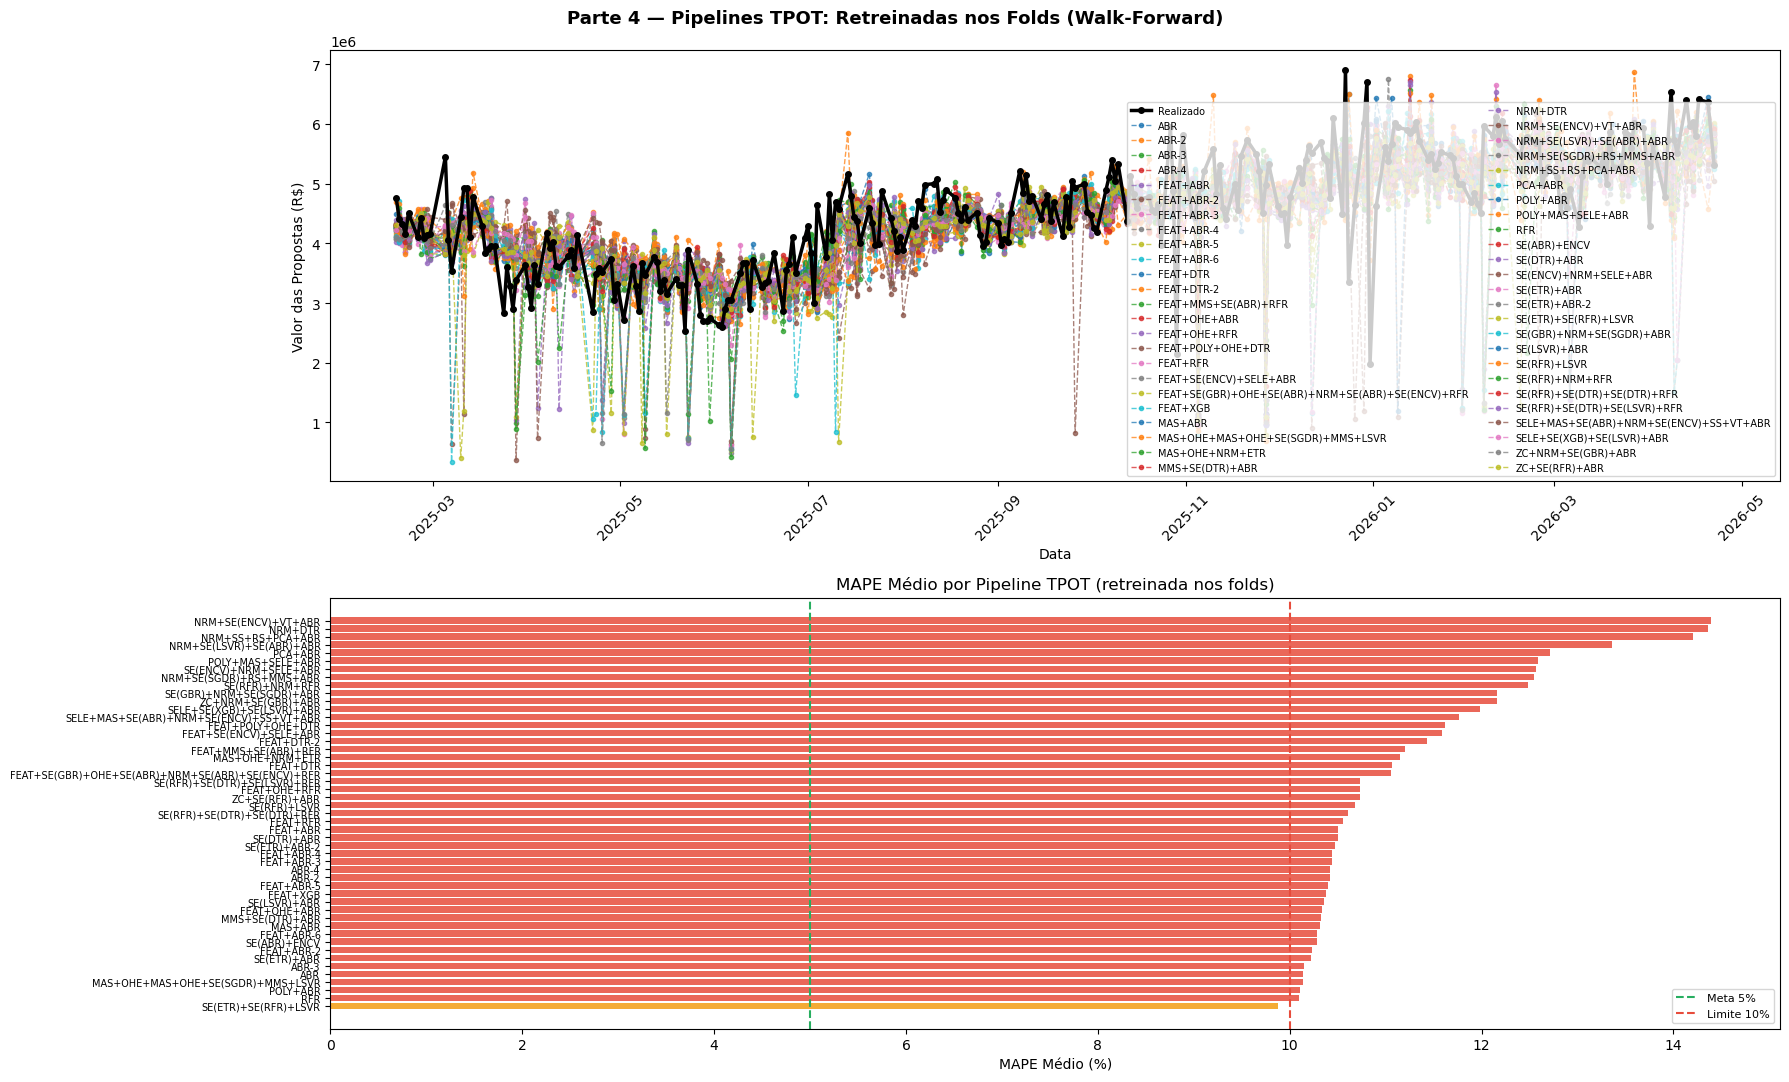

In [56]:
df_p4 = pd.DataFrame(detalhes_p4)
if not df_p4.empty:
    df_p4['Dia Prevista'] = pd.to_datetime(df_p4['Dia Prevista'])
    print(f'PKLs avaliados: {df_p4["Modelo"].nunique()}  |  Predições: {len(df_p4)}')
    display(build_table(resultados_p4))

    fig, axes = plt.subplots(2, 1, figsize=(18, 11))
    fig.suptitle('Parte 4 — Pipelines TPOT: Retreinadas nos Folds (Walk-Forward)', fontsize=13, fontweight='bold')

    _df_sorted = df_p4.sort_values('Dia Prevista')
    _real_u    = _df_sorted.drop_duplicates('Dia Prevista').set_index('Dia Prevista')
    axes[0].plot(_real_u.index, _real_u['Valor Realizado'], color='black', lw=2.5, marker='o', ms=4, label='Realizado', zorder=5)
    _cmap_l = plt.cm.tab10
    for _j, _n in enumerate(sorted(resultados_p4)):
        _sub = _df_sorted[_df_sorted['Modelo'] == _n].sort_values('Dia Prevista')
        axes[0].plot(_sub['Dia Prevista'], _sub['Valor Previsto'],
                     lw=1.0, linestyle='--', marker='o', ms=3, alpha=0.75, color=_cmap_l(_j % 10), label=_n)
    axes[0].set_ylabel('Valor das Propostas (R$)'); axes[0].set_xlabel('Data')
    axes[0].tick_params(axis='x', rotation=45); axes[0].legend(fontsize=7, ncol=2)

    _mape_med = pd.Series({k: np.mean(v) for k, v in resultados_p4.items()}).sort_values()
    _cores_b  = ['#2ecc71' if m < 5 else '#f39c12' if m < 10 else '#e74c3c' for m in _mape_med.values]
    axes[1].barh(list(_mape_med.index), _mape_med.values, color=_cores_b, alpha=0.85)
    axes[1].axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    axes[1].axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    axes[1].set_xlabel('MAPE Médio (%)')
    axes[1].set_title('MAPE Médio por Pipeline TPOT (retreinada nos folds)')
    axes[1].tick_params(axis='y', labelsize=7); axes[1].legend(fontsize=8)

    plt.tight_layout(); plt.show()

---
## Modelos importados (de `top15_valor_realinhado`)

Traz dois candidatos da analise de mediana e os avalia **nos mesmos folds walk-forward**
das Partes 1/2/4, para entrarem no ranking integrado de igual para igual:

- **`Voting(GBR+XGB+RFR)`** -- `VotingRegressor(GBR200 + XGB200 + RF200)`, features **BASE**, janela **45** (mesmo esquema das outras partes).
- **`ExtraTrees(EXT,j90)`** -- `ExtraTreesRegressor(n=300)`, features **ESTENDIDAS** (`+dia_mes, semana_mes, fim_mes, ma3/ma5_valor, ticket_1, ma3_ticket, qnt_lag2`), janela **90** (treina nas ultimas 90 obs antes de cada dia previsto).

Saidas em `resultados_novos`/`detalhes_novos` (Parte **NEW**), consumidas pela consolidacao da Secao 5.

In [57]:
# ============================================================
# MODELOS IMPORTADOS (top15_valor_realinhado) -- mesmos folds walk-forward
# ============================================================
JANELA_NOVOS = 90
NOME_VOTING  = 'Voting(GBR+XGB+RFR)'
NOME_EXTRA   = 'ExtraTrees(EXT,j90)'

def _mk_voting():
    return VotingRegressor([
        ('gbr', GradientBoostingRegressor(n_estimators=200, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=200, random_state=42, verbosity=0)),
        ('rf',  RandomForestRegressor(n_estimators=200, random_state=42)),
    ])
def _mk_extra():
    return ExtraTreesRegressor(n_estimators=300, random_state=42)

# --- Frame ESTENDIDO (EXT): refaz a engenharia de features com extras p/ ExtraTrees(EXT,j90)
_age = df[(df['data'] <= DATA_REFERENCIA) & (df['data'] >= DATA_REFERENCIA_MIN - timedelta(days=120))].copy()
_age = _age.groupby('data').agg({'qntd': 'sum', 'valor': 'sum'}).reset_index()
_age['qntd'] = _age['qntd'].astype(int)
_age = pd.merge(_age, df_fila, on='data', how='left').sort_values('data').reset_index(drop=True)
# base (igual ao FE principal)
_age['dia_semana'] = _age['data'].dt.day_of_week
_age['lag_0'] = _age['qntd'].shift(1)
for _i in range(1, 7):
    _age[f'lag_{_i}'] = _age['valor'].shift(_i)
_age['lag_7'] = _age['QUANTIDADE'].shift(1)
# estendidas (mesmas siglas EXT do top15_valor_realinhado)
_age['dia_mes']    = _age['data'].dt.day
_age['semana_mes'] = (_age['data'].dt.day - 1) // 7 + 1
_age['fim_mes']    = (_age['data'].dt.day >= 25).astype(int)
_age['ma3_valor']  = _age['valor'].shift(1).rolling(3).mean()
_age['ma5_valor']  = _age['valor'].shift(1).rolling(5).mean()
_age['ticket_1']   = (_age['valor'] / _age['qntd'].replace(0, np.nan)).shift(1)
_age['ma3_ticket'] = (_age['valor'] / _age['qntd'].replace(0, np.nan)).shift(1).rolling(3).mean()
_age['qnt_lag2']   = _age['qntd'].shift(2)
FEATS_BASE = ['dia_semana','lag_0','lag_1','lag_2','lag_3','lag_4','lag_5','lag_6','lag_7']
FEATS_EXT  = FEATS_BASE + ['dia_mes','semana_mes','fim_mes','ma3_valor','ma5_valor','ticket_1','ma3_ticket','qnt_lag2']
_age = _age.dropna(subset=FEATS_EXT + ['valor']).reset_index(drop=True)
_inval     = _age['data'].apply(lambda d: d.dayofweek == 6 or bool(wd.is_holiday(d.date(), country='BR')))
_pred_ext  = _age[(~_inval) & (_age['data'].dt.dayofweek < 5)].reset_index(drop=True)
_train_ext = _age[((~_inval) if INCLUIR_SABADO_TREINO else ((~_inval) & (_age['data'].dt.dayofweek < 5))) & (~mask_dias_excluir(_age['data']))].reset_index(drop=True)
_pred_ext_by_date = {pd.Timestamp(d): i for i, d in enumerate(_pred_ext['data'])}

# --- cache (heavy)
_key_nv = hashlib.md5(
    f"novos|{DATA_REFERENCIA.date()}|{JANELA_DIAS}|{N_SPLITS_CV}|{INCLUIR_SABADO_TREINO}|rmatip|{JANELA_NOVOS}|{NOME_VOTING}|{NOME_EXTRA}".encode()
).hexdigest()[:12]
_cache_nv = os.path.join(_cache_dir, f'novos_valor_{_key_nv}.pkl')

resultados_novos, detalhes_novos, _loaded_nv = {}, [], False
if os.path.exists(_cache_nv):
    try:
        with open(_cache_nv, 'rb') as _f:
            resultados_novos, detalhes_novos = pickle.load(_f)
        _loaded_nv = True
        print(f'[cache hit] NOVOS <- {_cache_nv}')
    except Exception as _e:
        print(f'[cache invalido] {_e}')

if not _loaded_nv:
    _acc = {NOME_VOTING: [], NOME_EXTRA: []}
    detalhes_novos = []
    for _tr_idx, _te_idx in tscv.split(X):
        _ti   = _te_idx[0]
        _td   = pd.Timestamp(dates.iloc[_ti])
        _real = float(y.iloc[_ti])
        if _real <= 0:
            continue
        # Voting (BASE, janela 45): mesmo walk-forward das demais partes
        _Xtr, _ytr = get_train(_tr_idx)
        if len(_Xtr) >= 8:
            try:
                _m = _mk_voting(); _m.fit(_Xtr, _ytr)
                _p = float(_m.predict(X.iloc[_te_idx])[0])
                _ape = abs(_p - _real) / abs(_real) * 100
                _acc[NOME_VOTING].append(_ape)
                detalhes_novos.append({'Modelo': NOME_VOTING, 'Dia Prevista': _td.date(),
                    'Treino Inicio': dates.iloc[_tr_idx[0]].date(), 'Treino Fim': dates.iloc[_tr_idx[-1]].date(),
                    'Valor Previsto': round(_p, 1), 'Valor Realizado': round(_real, 1), 'MAPE (%)': round(_ape, 2)})
            except Exception:
                pass
        # ExtraTrees (EXT, janela 90): treina nas ultimas 90 obs anteriores a _td
        if _td in _pred_ext_by_date:
            _pos = np.where((_train_ext['data'] < _td).values)[0][-JANELA_NOVOS:]
            if len(_pos) >= 8:
                try:
                    _Xt = _train_ext.iloc[_pos][FEATS_EXT].astype(float)
                    _yt = _train_ext.iloc[_pos]['valor'].astype(float)
                    _xe = _pred_ext.iloc[[_pred_ext_by_date[_td]]][FEATS_EXT].astype(float)
                    _m = _mk_extra(); _m.fit(_Xt, _yt)
                    _p = float(_m.predict(_xe)[0])
                    _ape = abs(_p - _real) / abs(_real) * 100
                    _acc[NOME_EXTRA].append(_ape)
                    detalhes_novos.append({'Modelo': NOME_EXTRA, 'Dia Prevista': _td.date(),
                        'Treino Inicio': _train_ext.iloc[_pos[0]]['data'].date(), 'Treino Fim': _train_ext.iloc[_pos[-1]]['data'].date(),
                        'Valor Previsto': round(_p, 1), 'Valor Realizado': round(_real, 1), 'MAPE (%)': round(_ape, 2)})
                except Exception:
                    pass
    resultados_novos = {k: v for k, v in _acc.items() if v}
    try:
        with open(_cache_nv, 'wb') as _f:
            pickle.dump((resultados_novos, detalhes_novos), _f)
        print(f'[cache salvo] -> {_cache_nv}')
    except Exception as _e:
        print(f'[cache erro] {_e}')

for _n, _mp in resultados_novos.items():
    print(f'{_n:<22} n={len(_mp):3d}  MAPE medio={np.mean(_mp):6.2f}%  mediana={np.median(_mp):.2f}%')

[cache hit] NOVOS <- cache\novos_valor_b3ba49dcef1d.pkl
Voting(GBR+XGB+RFR)    n=295  MAPE medio=  9.76%  mediana=6.61%
ExtraTrees(EXT,j90)    n=295  MAPE medio=  9.30%  mediana=6.67%


---
## Secao 4 - Comparacao e Selecao (sem correcao de vies)

**Metodologia:** todos os candidatos entram na comparacao com as previsoes **originais/cruas** -- nenhuma correcao de vies (debias) e aplicada em nenhum momento. O ranking e os graficos (5.A-5.D) usam a mesma base comum de datas (comparacao justa), apos a remocao dos dias especiais (Log_Erro + vesperas de Natal/ano novo/Carnaval + outliers manuais, ver secao de preparacao). A Pipeline Antiga entra como referencia, com o MAPE recomputado de forma consistente.


### 4.A — Todos os Modelos vs Pipeline Antiga


In [58]:
# ============================================================
# IMPORT: predicoes do SARIMA (exportadas por experimento_sarima.ipynb)
# ============================================================
# O SARIMA (com intervencao p/ Log_Erro/vesperas, ordem via auto_arima) e treinado
# e avaliado la -- aqui so importamos a previsao crua (sem debias) p/ entrar no
# ranking integrado nas mesmas condicoes dos demais candidatos.
_path_sarima_v = r'resultados\sarima_valor_predicoes.pkl'
detalhes_sarima, resultados_sarima = [], {}
if os.path.exists(_path_sarima_v):
    _df_sx = pd.read_pickle(_path_sarima_v)
    _df_sx['Dia Prevista'] = pd.to_datetime(_df_sx['Dia Prevista'])
    detalhes_sarima = _df_sx.to_dict('records')
    _mapes_sx = ((_df_sx['Valor Previsto'] - _df_sx['Valor Realizado']).abs()
                 / _df_sx['Valor Realizado'].abs().replace(0, np.nan) * 100).dropna().tolist()
    if _mapes_sx:
        resultados_sarima = {'SARIMA': _mapes_sx}
    print(f'[import] SARIMA (experimento_sarima) <- {_path_sarima_v} | '
          f'{len(_df_sx)} previsoes | '
          f'{_df_sx["Dia Prevista"].min().date()} -> {_df_sx["Dia Prevista"].max().date()}')
else:
    print(f'[import] SARIMA indisponivel ({_path_sarima_v} nao encontrado) -- '
          f'rode experimento_sarima.ipynb (Secao 3, area VALOR) p/ gerar o export')


[import] SARIMA (experimento_sarima) <- resultados\sarima_valor_predicoes.pkl | 204 previsoes | 2025-02-18 -> 2026-04-16


In [59]:
# ============================================================
# CARREGA PIPELINE ANTIGA EM PRODUCAO (backup_valor)
# ============================================================
bkp = pd.read_excel(r'resultados\backup_valor.xlsx')
_col_data_bkp = 'Data previsao'
bkp['Map'] = (
    bkp['Map'].astype(str)
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.-]', '', regex=True)
)
bkp['Map']          = pd.to_numeric(bkp['Map'], errors='coerce')
bkp[_col_data_bkp]  = pd.to_datetime(bkp[_col_data_bkp], errors='coerce').dt.normalize()
_col_vp = 'Valor Previsto' if 'Valor Previsto' in bkp.columns else 'Valor previsto'
bkp['_vp_num'] = pd.to_numeric(bkp[_col_vp], errors='coerce')
bkp = bkp.dropna(subset=[_col_data_bkp, 'Map', '_vp_num']).copy()

# Exclui sábados: o modelo de valor não deve prever fins de semana
_n_sab = (bkp[_col_data_bkp].dt.dayofweek == 5).sum()
bkp = bkp[bkp[_col_data_bkp].dt.dayofweek < 5].copy()
print(f'[backup_valor] {_n_sab} sábados removidos → {len(bkp)} previsões restantes (seg–sex)')

realizados_valor = df_ag.set_index('data')['valor'].to_dict()
NOME_ANTIGO = 'Pipeline Antiga em Producao'

df_antigo = pd.DataFrame({
    'Modelo':                NOME_ANTIGO,
    'Dia Prevista':          bkp[_col_data_bkp].values,
    'Intervalo Treinamento': [
        f"{(d - timedelta(days=45)).date()} -> {(d - timedelta(days=1)).date()}"
        for d in bkp[_col_data_bkp]
    ],
    'Valor Previsto':        bkp['_vp_num'].round(1).values,
    'Valor Realizado':       [
        round(realizados_valor[pd.Timestamp(d.date())], 1)
        if pd.Timestamp(d.date()) in realizados_valor else np.nan
        for d in bkp[_col_data_bkp]
    ],
    'MAPE (%)':              np.nan,   # recalculado abaixo (NAO usa bkp['Map'], enviesado)
})
# MAPE da antiga recomputado de forma consistente: |Previsto - Realizado| / Realizado.
# bkp['Map'] foi gravado em producao contra o realizado incompleto do proprio dia -> enviesado.
# ClickHouse devolve Decimal -> coage p/ float antes de operar (evita TypeError float - Decimal)
_prev_f = pd.to_numeric(df_antigo['Valor Previsto'], errors='coerce').astype(float)
_real_f = pd.to_numeric(df_antigo['Valor Realizado'], errors='coerce').astype(float)
with np.errstate(divide='ignore', invalid='ignore'):
    _mape_ant = (_prev_f - _real_f).abs() / _real_f.abs().replace(0, np.nan) * 100
df_antigo['MAPE (%)'] = _mape_ant.round(2)
_res_antigo = _mape_ant.dropna().tolist()
print(f'{NOME_ANTIGO}: {len(df_antigo)} previsões')

# ============================================================
# CONSOLIDA TODOS OS DETALHES
# ============================================================
def _to_df_det(det):
    if not det: return pd.DataFrame()
    df = pd.DataFrame(det)
    if 'Dia Prevista' in df.columns:
        df['Dia Prevista'] = pd.to_datetime(df['Dia Prevista'])
    return df

_df_todos = pd.concat(
    [d for d in [
        _to_df_det(detalhes_p1),
        _to_df_det(detalhes_p2),
        _to_df_det(detalhes_p4),
        _to_df_det(globals().get('detalhes_novos', [])),
        _to_df_det(globals().get('detalhes_sarima', [])),
        df_antigo,
    ] if not d.empty],
    ignore_index=True, sort=False
)
_df_todos['Dia Prevista'] = pd.to_datetime(_df_todos['Dia Prevista'])
_df_todos['MAPE (%)']     = pd.to_numeric(_df_todos['MAPE (%)'], errors='coerce')
# P2 (e outros) nao salvam MAPE (%) no dict de detalhe — recalcula onde NaN
_mask_nan = _df_todos['MAPE (%)'].isna()
if _mask_nan.any():
    _vp = pd.to_numeric(_df_todos.loc[_mask_nan, 'Valor Previsto'],  errors='coerce')
    _vr = pd.to_numeric(_df_todos.loc[_mask_nan, 'Valor Realizado'], errors='coerce')
    _df_todos.loc[_mask_nan, 'MAPE (%)'] = ((_vp - _vr).abs() / _vr.abs().replace(0, np.nan) * 100).round(2)
    print(f'[MAPE recalculado] {_mask_nan.sum()} linhas sem MAPE preenchidas a partir de Previsto/Realizado')
_df_todos['Erro']         = (
    pd.to_numeric(_df_todos['Valor Previsto'],  errors='coerce') -
    pd.to_numeric(_df_todos['Valor Realizado'], errors='coerce')
)
print(f'Total linhas: {len(_df_todos)} | Modelos: {_df_todos["Modelo"].nunique()}')

# Alinha periodos: intersecao de datas onde Pipeline Antiga E candidatos tem previsao
_datas_ant  = set(_df_todos.loc[_df_todos["Modelo"] == NOME_ANTIGO, "Dia Prevista"])
_datas_cand = set(_df_todos.loc[_df_todos["Modelo"] != NOME_ANTIGO, "Dia Prevista"])
_datas_comuns = _datas_ant & _datas_cand
_n_antes = len(_df_todos)
_df_todos = _df_todos[_df_todos["Dia Prevista"].isin(_datas_comuns)].copy()
print(f"Periodo alinhado: {len(_datas_comuns)} datas comuns | Pipeline Antiga: {len(_datas_ant)} | Candidatos: {len(_datas_cand)} | {_n_antes} -> {len(_df_todos)} linhas")

# ============================================================
# SEM CORRECAO DE VIES -- as previsoes originais/cruas de cada candidato sao usadas
# diretamente. Toda a Secao 5 (rankings e graficos 5.A-5.D) usa a mesma base comum
# de datas (comparacao justa), apos a remocao dos dias especiais abaixo.
# ============================================================
_UNID       = 'Valor das Propostas (R$)'

# Salvaguarda: descarta modelos com cobertura < 50% do maximo (evita que 1 modelo
# esparso colapse a intersecao de datas comuns)
_todos_mod = list(_df_todos['Modelo'].unique())
_cov = (_df_todos[_df_todos['Modelo'].isin(_todos_mod)]
        .dropna(subset=['Valor Previsto', 'Valor Realizado'])
        .groupby('Modelo')['Dia Prevista'].nunique())
_cov_max = _cov.max() if len(_cov) else 0
_drop = _cov[_cov < 0.5 * _cov_max].index.tolist()
if _drop:
    print(f'Descartados por baixa cobertura (<50% de {_cov_max} dias): {_drop}')
_todos_mod = [m for m in _todos_mod if m not in _drop]

# Base comum: todos os modelos restantes, restritos aos dias comuns a TODOS
_base = _df_todos[_df_todos['Modelo'].isin(_todos_mod)].dropna(
    subset=['Valor Previsto', 'Valor Realizado']).copy()
_cnt      = _base.groupby('Dia Prevista')['Modelo'].nunique()
_datas_ok = _cnt[_cnt == len(_todos_mod)].index
_base     = _base[_base['Dia Prevista'].isin(_datas_ok)].copy()
print(f'Base comum (sem correcao de vies): {len(_todos_mod)} modelos | {len(_datas_ok)} datas comuns')

# --- Remocao de dias especiais (outliers + Log_Erro) -------------------------
# Remove da base de realizados/preditos os dias definidos na secao de preparacao:
# Log_Erro (dias de impacto) + vespera de Natal/ano novo + DIAS_EXCLUIR_OUTLIERS.
_dp_norm  = _base['Dia Prevista'].dt.normalize()
_mask_out = mask_dias_excluir(_base['Dia Prevista'])
if _mask_out.any():
    _n0_out   = _base['Dia Prevista'].nunique()
    _dias_rm  = set(_dp_norm[_mask_out])
    _n_erro   = len(_dias_rm & DIAS_ERRO)
    _base     = _base[~_mask_out].copy()
    _datas_ok = _base['Dia Prevista'].unique()
    print(f'[outliers] removidos {int(_mask_out.sum())} registros ({len(_dias_rm)} dias atipicos; '
          f'{_n_erro} por Log_Erro) | datas {_n0_out} -> {_base["Dia Prevista"].nunique()}')

# Exporta as datas efetivamente avaliadas (base comum pos-atipicos) p/ alinhar o sarima
os.makedirs('resultados', exist_ok=True)
_datas_avaliadas = pd.Series(sorted(pd.to_datetime(_base['Dia Prevista'].unique())))
_datas_avaliadas.to_pickle(r'resultados\datas_avaliadas_valor.pkl')
print(f'[datas avaliadas -> sarima] {len(_datas_avaliadas)} dias | '
      f'periodo {_datas_avaliadas.min().date()} -> {_datas_avaliadas.max().date()} | '
      f'resultados/datas_avaliadas_valor.pkl')

# _df_db = previsoes cruas (sem correcao de vies) -- alias de _base
_df_db = _base.copy()

# ============================================================
# RANKING FINAL INTEGRADO -- SEM CORRECAO DE VIES (base comum a todos)
# ============================================================
_parte_map = (
    {n: "P1" for n in resultados_p1} |
    {n: "P2" for n in resultados_p2} |
    {n: "P4" for n in resultados_p4} |
    {n: "NEW" for n in globals().get('resultados_novos', {})} |
    {n: "SARIMA" for n in globals().get('resultados_sarima', {})} |
    {NOME_ANTIGO: "REF"}
)
_todos_int = {}
_parte_int = {}
for _nome_r, _grp_r in _df_db.groupby("Modelo"):
    _mapes_r = _grp_r["MAPE (%)"].dropna().tolist()
    if _mapes_r:
        _todos_int[_nome_r] = _mapes_r
        _parte_int[_nome_r] = _parte_map.get(_nome_r, "?")

_rows_int = {}
for _nome_r, _mapes_r in _todos_int.items():
    _n_r = len(_mapes_r)
    _rows_int[_nome_r] = {
        "Parte":          _parte_int[_nome_r],
        "MAPE Medio (%)": round(np.mean(_mapes_r), 2),
        "Mediana (%)": round(np.median(_mapes_r), 2),
        "Desvio (%)": round(np.std(_mapes_r), 2),
        "Min (%)": round(np.min(_mapes_r), 2),
        "Max (%)": round(np.max(_mapes_r), 2),
        "< 5%": f"{sum(m <   5 for m in _mapes_r)}/{_n_r}",
        "< 10%": f"{sum(m <  10 for m in _mapes_r)}/{_n_r}",
        "< 50%": f"{sum(m <  50 for m in _mapes_r)}/{_n_r}",
        "< 100%": f"{sum(m < 100 for m in _mapes_r)}/{_n_r}",
        "N": _n_r,
    }

df_ranking_int = pd.DataFrame(_rows_int).T
print("\nRanking Final Integrado  (P1 + P2 + P4 + Pipeline Antiga) -- SEM correcao de vies:")

# Vies e MAE por modelo, derivados de _df_db
_err_aug = _df_db.dropna(subset=['Valor Previsto', 'Valor Realizado']).copy()
_err_aug['_rmp'] = (
    pd.to_numeric(_err_aug['Valor Realizado'], errors='coerce') -
    pd.to_numeric(_err_aug['Valor Previsto'],  errors='coerce')
)
_vies_aug = _err_aug.groupby('Modelo')['_rmp'].mean().round(1)
_mae_aug  = _err_aug.groupby('Modelo')['_rmp'].apply(lambda s: s.abs().mean()).round(1)
df_ranking_int['Vies (real-prev)'] = df_ranking_int.index.map(_vies_aug)
df_ranking_int['|Vies|']           = df_ranking_int['Vies (real-prev)'].abs().round(1)
df_ranking_int['MAE']              = df_ranking_int.index.map(_mae_aug)
def _r2_grp(s):
    _r = pd.to_numeric(s['Valor Realizado'], errors='coerce').astype(float)
    _p = pd.to_numeric(s['Valor Previsto'],  errors='coerce').astype(float)
    _sr = float(((_r - _p) ** 2).sum()); _st = float(((_r - _r.mean()) ** 2).sum())
    return round(1 - _sr / _st, 3) if _st != 0 else np.nan
_r2_aug = _err_aug.groupby('Modelo')[['Valor Realizado', 'Valor Previsto']].apply(_r2_grp)
df_ranking_int['R2']               = df_ranking_int.index.map(_r2_aug)
_var_aug = _err_aug.groupby('Modelo')['_rmp'].var(ddof=0).round(1)
_dp_aug  = _err_aug.groupby('Modelo')['_rmp'].std(ddof=0).round(1)
df_ranking_int['Var Erro']         = df_ranking_int.index.map(_var_aug)
df_ranking_int['DP Erro']          = df_ranking_int.index.map(_dp_aug)
# Vies percentual (MPE) e coef. de variacao do erro (DP do erro / nivel da serie)
def _mpe_grp(s):
    _r = pd.to_numeric(s['Valor Realizado'], errors='coerce').astype(float)
    _p = pd.to_numeric(s['Valor Previsto'],  errors='coerce').astype(float)
    return float(((_r - _p) / _r.replace(0, np.nan)).mean() * 100)
_mpe_aug   = _err_aug.groupby('Modelo')[['Valor Realizado', 'Valor Previsto']].apply(_mpe_grp).round(2)
_mreal_aug = _err_aug.groupby('Modelo')['Valor Realizado'].apply(lambda s: pd.to_numeric(s, errors='coerce').astype(float).mean())
_cv_aug    = (_err_aug.groupby('Modelo')['_rmp'].std(ddof=0) / _mreal_aug * 100).round(2)
df_ranking_int['Vies % (MPE)']     = df_ranking_int.index.map(_mpe_aug)
df_ranking_int['CV Erro (%)']      = df_ranking_int.index.map(_cv_aug)
_rmspe_int = _df_db.groupby('Modelo')['MAPE (%)'].apply(lambda s: float(np.sqrt(np.mean(np.square(s.dropna()))))).round(2)
df_ranking_int['RMSPE (%)']        = df_ranking_int.index.map(_rmspe_int)
_front = ['Parte', 'MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)', '|Vies|', 'Vies % (MPE)', 'MAE', 'DP Erro', 'CV Erro (%)', 'Var Erro', 'Mediana (%)']
df_ranking_int = df_ranking_int[
    [c for c in _front if c in df_ranking_int.columns] +
    [c for c in df_ranking_int.columns if c not in _front]
]

def _com_modelo(df, nome='Modelo'):
    """Move o indice (nome do modelo) p/ uma coluna -- preferencia de exibicao das tabelas de ranking."""
    out = df.copy()
    out.index.name = nome
    return out.reset_index()


df_ranking_int = df_ranking_int.sort_values(['RMSPE (%)', '|Vies|', 'DP Erro'])


[backup_valor] 0 sábados removidos → 295 previsões restantes (seg–sex)
Pipeline Antiga em Producao: 295 previsões
[MAPE recalculado] 5809 linhas sem MAPE preenchidas a partir de Previsto/Realizado
Total linhas: 23801 | Modelos: 81
Periodo alinhado: 294 datas comuns | Pipeline Antiga: 294 | Candidatos: 295 | 23801 -> 23722 linhas
Base comum (sem correcao de vies): 81 modelos | 202 datas comuns
[datas avaliadas -> sarima] 202 dias | periodo 2025-02-18 -> 2026-04-16 | resultados/datas_avaliadas_valor.pkl

Ranking Final Integrado  (P1 + P2 + P4 + Pipeline Antiga) -- SEM correcao de vies:


In [60]:
print('\nRanking Final Integrado -- SEM correcao de vies:')
display(_com_modelo(df_ranking_int))



Ranking Final Integrado -- SEM correcao de vies:


,Modelo,Parte,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,...,Var Erro,Mediana (%),Desvio (%),Min (%),Max (%),< 5%,< 10%,< 50%,< 100%,N
0,SARIMA,SARIMA,7.19,9.26,0.77,2350.30,2350.30,-0.59,324462.70,423653.90,...,179482627991.10,5.74,5.84,0.07,30.23,86/202,150/202,202/202,202/202,202
1,"ExtraTrees(EXT,j90)",NEW,7.30,9.84,0.72,73356.40,73356.40,0.48,335161.60,458769.00,...,210468983193.70,5.90,6.60,0.02,42.56,89/202,159/202,202/202,202/202,202
2,POLY+ABR,P4,8.14,10.31,0.69,100536.80,100536.80,1.16,373008.70,472759.00,...,223501064037.90,6.80,6.34,0.15,32.09,72/202,142/202,202/202,202/202,202
3,MAS+OHE+MAS+OHE+SE(SGDR)+MMS+LSVR,P4,8.39,10.49,0.66,76782.90,76782.90,0.62,390355.10,501947.40,...,251951209479.20,7.08,6.30,0.06,32.06,69/202,134/202,202/202,202/202,202
4,Pipeline Antiga em Producao,REF,8.31,10.61,0.69,26160.40,26160.40,-0.66,380419.70,483884.50,...,234144164706.70,6.95,6.60,0.02,41.02,72/203,139/203,203/203,203/203,203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,Ridge,P1,12.49,16.98,0.13,10888.50,10888.50,-0.78,583763.90,816337.00,...,666406042564.00,9.96,11.50,0.06,63.40,56/202,102/202,197/202,202/202,202
77,KNN,P1,11.44,16.98,0.08,251040.70,251040.70,3.83,536307.40,799599.70,...,639359756052.10,8.04,12.54,0.21,81.83,71/202,122/202,197/202,202/202,202
78,PCA(6) + GradientBoosting,P2,11.13,17.06,0.08,251157.00,251157.00,4.33,521161.60,800168.20,...,640269215648.40,8.07,12.93,0.16,87.39,61/202,127/202,196/202,202/202,202
79,LinearRegression,P1,12.64,17.15,0.12,11131.70,11131.70,-0.78,590007.90,822505.20,...,676514838225.50,9.96,11.59,0.06,62.65,53/202,101/202,197/202,202/202,202


In [61]:
_com_modelo(df_ranking_int[['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)', 'DP Erro', 'Max (%)', '< 5%', '< 10%', '< 50%']].sort_values('MAPE Medio (%)'))

,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),DP Erro,Max (%),< 5%,< 10%,< 50%
0,SARIMA,7.19,9.26,0.77,2350.30,423653.90,30.23,86/202,150/202,202/202
1,"ExtraTrees(EXT,j90)",7.30,9.84,0.72,73356.40,458769.00,42.56,89/202,159/202,202/202
2,Voting(GBR+XGB+RFR),8.01,10.73,0.67,128343.90,490335.40,33.35,81/202,141/202,202/202
3,VotingRegressor (RandomForest + ExtraTrees + X...,8.05,10.65,0.67,135621.80,485511.90,35.51,86/202,142/202,202/202
4,SelectKBest(k=8)+RandomForest,8.09,11.51,0.61,135331.30,528900.40,56.60,88/202,141/202,200/202
...,...,...,...,...,...,...,...,...,...,...
76,PCA(6) + GradientBoosting,11.13,17.06,0.08,251157.00,800168.20,87.39,61/202,127/202,196/202
77,KNN,11.44,16.98,0.08,251040.70,799599.70,81.83,71/202,122/202,197/202
78,NRM+SE(ENCV)+VT+ABR,12.11,18.72,-0.11,266201.80,884689.40,84.06,65/202,116/202,196/202
79,Ridge,12.49,16.98,0.13,10888.50,816337.00,63.40,56/202,102/202,197/202


In [62]:
# ============================================================
# TABELA P/ POWERPOINT -- Pipeline Antiga + modelos selecionados
# (ordem fixa) com a posicao no Ranking Final Integrado
# ------------------------------------------------------------
# Posicao = colocacao em df_ranking_int (ordenado RMSPE -> |Vies| -> DP Erro)
# entre TODOS os modelos avaliados.
# ============================================================
MODELOS_ADICIONAIS = [
    'SE(ETR)+ABR',
    'Voting(GBR+XGB+RFR)',
    'SARIMA'
]
_top5_pptx = df_ranking_int[df_ranking_int.index != NOME_ANTIGO].head(5).index.tolist()
MODELOS_PRESELECIONADOS = _top5_pptx + [m for m in MODELOS_ADICIONAIS if m not in _top5_pptx]
_ordem_fixa = [NOME_ANTIGO] + MODELOS_PRESELECIONADOS
_pos = {m: i + 1 for i, m in enumerate(df_ranking_int.index)}
_cols_export = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)',
                'DP Erro', 'Max (%)', '< 5%', '< 10%', '< 50%']
_faltam = [m for m in _ordem_fixa if m not in df_ranking_int.index]
if _faltam:
    print(f'[export] nao encontrados no ranking: {_faltam}')
_linhas = [m for m in _ordem_fixa if m in df_ranking_int.index]
_tab_export = df_ranking_int.loc[_linhas, _cols_export].copy()
_tab_export.insert(0, 'Posicao Ranking', [_pos[m] for m in _linhas])
_tab_export = _com_modelo(_tab_export)   # nome do modelo como coluna
import os as _os
_os.makedirs('saidas', exist_ok=True)
_saida = r'saidas\comparativo_preselecionados_valor.xlsx'
_tab_export.to_excel(_saida, index=False)
print(f'Tabela exportada para: {_saida}  ({len(_tab_export)} linhas)')
_tab_export

Tabela exportada para: saidas\comparativo_preselecionados_valor.xlsx  (8 linhas)


,Modelo,Posicao Ranking,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),DP Erro,Max (%),< 5%,< 10%,< 50%
0,Pipeline Antiga em Producao,5,8.31,10.61,0.69,26160.40,483884.50,41.02,72/203,139/203,203/203
1,SARIMA,1,7.19,9.26,0.77,2350.30,423653.90,30.23,86/202,150/202,202/202
2,"ExtraTrees(EXT,j90)",2,7.30,9.84,0.72,73356.40,458769.00,42.56,89/202,159/202,202/202
3,POLY+ABR,3,8.14,10.31,0.69,100536.80,472759.00,32.09,72/202,142/202,202/202
4,MAS+OHE+MAS+OHE+SE(SGDR)+MMS+LSVR,4,8.39,10.49,0.66,76782.90,501947.40,32.06,69/202,134/202,202/202
5,VotingRegressor (RandomForest + ExtraTrees + X...,6,8.05,10.65,0.67,135621.80,485511.90,35.51,86/202,142/202,202/202
6,SE(ETR)+ABR,30,8.70,12.10,0.58,123764.40,552197.90,79.32,73/202,139/202,201/202
7,Voting(GBR+XGB+RFR),7,8.01,10.73,0.67,128343.90,490335.40,33.35,81/202,141/202,202/202


In [63]:
# ============================================================
# FUNCOES DE VISUALIZACAO (5.A, 5.B e 5.C)
# ============================================================
try:
    from scipy.stats import gaussian_kde as _gaussian_kde
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False

# ============================================================
# PALETA DE CORES (alto contraste) -- usada por todos os _plot_*
# ------------------------------------------------------------
# Pipeline Antiga sempre em vermelho; candidatos puxam de uma paleta
# qualitativa bem separada (sem os pares claro/escuro do tab20, sem
# vermelho e sem preto -- reservados a Antiga e ao Realizado).
# ============================================================
_COR_ANTIGA = '#d62728'   # vermelho forte (sempre a Pipeline Antiga)
_PALETA_MODELOS = [
    '#1f77b4',  # azul
    '#2ca02c',  # verde
    '#9467bd',  # roxo
    '#ff7f0e',  # laranja
    '#17becf',  # ciano
    '#8c564b',  # marrom
    '#e377c2',  # rosa
    '#bcbd22',  # oliva
]
def _cor_modelos(modelos):
    """Mapa nome->cor estavel: Antiga em vermelho; demais na paleta, na ordem."""
    cores, k = {}, 0
    for m in modelos:
        if m == NOME_ANTIGO:
            cores[m] = '#b0b0b0' if globals().get('_ENFASE_CAND') else _COR_ANTIGA
        else:
            cores[m] = _PALETA_MODELOS[k % len(_PALETA_MODELOS)]
            k += 1
    return cores

# ============================================================
# ENFASE CONFIGURAVEL (usada por comparar_modelo p/ destacar os modelos novos)
# ------------------------------------------------------------
# Quando _ENFASE_CAND=True a hierarquia visual fica: modelos novos > Realizado >
# Pipeline Antiga. _cor_modelos ja deixa a Antiga cinza-claro; _estilo_real e
# _estilo_linha cuidam de espessura/alpha/zorder e da cor do Realizado.
# ============================================================
_COR_REAL    = 'black'    # cor da serie Realizado (comparar_modelo deixa cinza)
_ENFASE_CAND = False      # True: candidatos em destaque; Realizado e Antiga ao fundo

def _estilo_real():
    """(cor, lw, zorder) da serie Realizado conforme a enfase ativa."""
    if globals().get('_ENFASE_CAND'):
        return globals().get('_COR_REAL', '#666666'), 2.2, 5
    return 'black', 2.5, 5

def _estilo_linha(nome):
    """(lw, ls, ms, alpha, zorder) da serie de um modelo conforme a enfase ativa."""
    _ref = (nome == NOME_ANTIGO)
    if globals().get('_ENFASE_CAND'):
        if _ref:                      # Pipeline Antiga ao fundo
            return 1.0, ':', 3, 0.45, 2
        return 2.6, '-', 5, 1.0, 6    # candidatos (modelos novos) em destaque
    if _ref:                          # comportamento original
        return 2.0, '-.', 4, 0.95, 4
    return 1.2, '--', 3, 0.65, 3

def _plot_serie_temporal(df_det, modelos, title='Serie Temporal', figsize=(18, 6)):
    _sub_all = df_det[df_det['Modelo'].isin(modelos)].copy()
    fig, ax = plt.subplots(figsize=figsize)
    _real = _sub_all.drop_duplicates('Dia Prevista').sort_values('Dia Prevista')
    _crl, _rlw, _rz = _estilo_real()
    ax.plot(_real['Dia Prevista'], _real['Valor Realizado'].astype(float),
            color=_crl, lw=_rlw, marker='o', ms=4, zorder=_rz, label='Realizado')
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = _sub_all[_sub_all['Modelo'] == nome].sort_values('Dia Prevista')
        if sub.empty: continue
        _lw, _ls, _ms, _al, _zo = _estilo_linha(nome)
        ax.plot(sub['Dia Prevista'], sub['Valor Previsto'].astype(float),
                lw=_lw, linestyle=_ls, marker='o', ms=_ms, alpha=_al, zorder=_zo,
                color=_cores[nome], label=nome)
    ax.set_xlabel('Data'); ax.set_ylabel('Valor das Propostas (R$)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_mape_temporal(df_det, modelos, title='MAPE ao Longo do Tempo', figsize=(18, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _lw, _ls, _ms, _al, _zo = _estilo_linha(nome)
        ax.plot(sub['Dia Prevista'], sub['MAPE (%)'],
                lw=_lw, marker='o', ms=_ms, alpha=_al, zorder=_zo,
                color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel('MAPE (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_dist_erro(df_det, modelos, title='Distribuicao do Erro', figsize=(14, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        erros = df_det[df_det['Modelo'] == nome]['Erro'].dropna()
        if len(erros) < 3: continue
        color = _cores[nome]
        ax.hist(erros, bins=20, alpha=0.18, color=color, density=True)
        if _HAS_SCIPY:
            try:
                _xs  = np.linspace(erros.min(), erros.max(), 250)
                _kde = _gaussian_kde(erros)
                ax.plot(_xs, _kde(_xs), lw=1.8, color=color, label=nome)
            except Exception:
                ax.axvline(erros.mean(), lw=1.2, color=color, linestyle='--', label=nome)
        else:
            _cnts, _edges = np.histogram(erros, bins=20, density=True)
            _mids = (_edges[:-1] + _edges[1:]) / 2
            ax.plot(_mids, _cnts, lw=1.5, color=color, label=nome)
    ax.axvline(0, color='black', linestyle='-', lw=1.8, label='Erro = 0')
    ax.set_xlabel('Erro (Previsto - Realizado)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_outliers(df_det, modelos, title='Distribuicao do MAPE por Modelo', figsize=(14, 7), cap_pct=150):
    _pares = [(df_det[df_det['Modelo'] == n]['MAPE (%)'].dropna().values, n)
              for n in modelos if not df_det[df_det['Modelo'] == n].empty]
    _pares.sort(key=lambda x: np.median(x[0]) if len(x[0]) > 0 else 999)
    if not _pares: return
    _labels_b = [n for _, n in _pares]

    # Clipa Pipeline Antiga no cap; demais modelos ficam intactos
    _data_b   = []
    _max_ant  = None
    for _vals, _nome in _pares:
        if _nome == NOME_ANTIGO:
            _max_ant = float(_vals.max()) if len(_vals) else None
            _data_b.append(np.clip(_vals, 0, cap_pct))
        else:
            _data_b.append(_vals)

    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(_data_b, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                    medianprops=dict(color='#1a5276', lw=2.0),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=3, alpha=0.4,
                                    markerfacecolor='#e74c3c', markeredgewidth=0))
    if NOME_ANTIGO in _labels_b:
        _idx = list(_labels_b).index(NOME_ANTIGO)
        if globals().get('_ENFASE_CAND'):
            bp['boxes'][_idx].set_facecolor('#d9d9d9')   # Antiga ao fundo
            bp['medians'][_idx].set_color('#7f7f7f')
        else:
            bp['boxes'][_idx].set_facecolor('#f9d5a7')
            bp['medians'][_idx].set_color('#7d3c00')
    ax.set_yticklabels(_labels_b, fontsize=7)
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('MAPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    if _max_ant is not None and _max_ant > cap_pct:
        fig.text(0.01, -0.03,
                 f'* {NOME_ANTIGO} limitada a {cap_pct:.0f}% para visualizacao (max real: {_max_ant:,.0f}%)',
                 fontsize=7.5, color='#7f8c8d')
    plt.tight_layout(); plt.show()


def _plot_vies_boxplot(df_det, modelos, title='Distribuicao do Vies por Modelo', figsize=(14, 7)):
    """Boxplot do Vies (Realizado - Previsto) por modelo, ordenado pela mediana -- mesmo
    estilo do boxplot de MAPE (_plot_outliers), porem com o vies (>0 subestima, <0 superestima)."""
    _pares = []
    for n in modelos:
        _sub = df_det[df_det['Modelo'] == n].dropna(subset=['Valor Previsto', 'Valor Realizado'])
        if _sub.empty:
            continue
        _vies = (pd.to_numeric(_sub['Valor Realizado'], errors='coerce').astype(float) -
                 pd.to_numeric(_sub['Valor Previsto'],  errors='coerce').astype(float)).values
        _pares.append((_vies, n))
    if not _pares:
        return
    _pares.sort(key=lambda x: np.median(x[0]))
    _data, _labels = zip(*_pares)
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(_data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                    medianprops=dict(color='#1a5276', lw=2.0),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=4, alpha=0.5,
                                    markerfacecolor='#e74c3c', markeredgewidth=0))
    if NOME_ANTIGO in _labels:
        _idx = list(_labels).index(NOME_ANTIGO)
        if globals().get('_ENFASE_CAND'):
            bp['boxes'][_idx].set_facecolor('#d9d9d9')   # Antiga ao fundo
            bp['medians'][_idx].set_color('#7f7f7f')
        else:
            bp['boxes'][_idx].set_facecolor('#f9d5a7')
            bp['medians'][_idx].set_color('#7d3c00')
    ax.set_yticklabels(_labels, fontsize=8)
    ax.axvline(0, color='black', linestyle='-', lw=1.5, label='Vies = 0 (ideal)')
    _unid = globals().get('_UNID', '')
    ax.set_xlabel('Vies (Realizado - Previsto)' + (f' -- {_unid}' if _unid else ''))
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


# ============================================================
# NOVAS FUNCOES DE VISUALIZACAO (usadas em 5.C e 5.D)
# ------------------------------------------------------------
# _recorte_mes      : filtra a base para um unico mes (default marco)
# _plot_rmspe_temporal : RMSPE rolling ao longo do tempo
# _plot_vies_temporal  : vies diario (Realizado - Previsto) ao longo do tempo
# _plot_rmspe_bar      : RMSPE por modelo (substitui o boxplot de MAPE na 5.C)
# ============================================================
def _recorte_mes(df_det, mes=3, ano=None):
    """Filtra df_det para um unico mes. Se ano=None, usa o ano mais recente
    presente para aquele mes (evita misturar marco de anos diferentes)."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if ano is None:
        _anos = sorted(dp[dp.dt.month == mes].dt.year.unique())
        if not len(_anos):
            return d.iloc[0:0]
        ano = int(_anos[-1])
    return d[(dp.dt.month == mes) & (dp.dt.year == ano)].copy()

def _plot_rmspe_temporal(df_det, modelos, title='RMSPE (rolling) ao Longo do Tempo',
                         figsize=(18, 6), win=None):
    """RMSPE em janela movel: sqrt(media movel do APE^2). Penaliza erros grandes
    mais do que o MAPE. Uma linha por modelo (janela = win, default 10 dias)."""
    win = int(win or 10)
    _minp = max(2, win // 3)
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _ape2  = sub['MAPE (%)'].astype(float) ** 2
        _rmspe = np.sqrt(_ape2.rolling(win, min_periods=_minp).mean())
        _lw, _ls, _ms, _al, _zo = _estilo_linha(nome)
        ax.plot(sub['Dia Prevista'], _rmspe,
                lw=_lw, marker='o', ms=_ms, alpha=_al, zorder=_zo,
                color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel(f'RMSPE (%) -- janela {win}d')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_vies_temporal(df_det, modelos, title='Vies ao Longo do Tempo', figsize=(18, 6)):
    """Vies diario (Realizado - Previsto) ao longo do tempo. >0 subestima, <0 superestima.
    Uma linha por modelo + linha de referencia em 0."""
    _unid = globals().get('_UNID', '')
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = (df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista')
               .dropna(subset=['Valor Previsto', 'Valor Realizado']))
        if sub.empty: continue
        _vies = (pd.to_numeric(sub['Valor Realizado'], errors='coerce').astype(float) -
                 pd.to_numeric(sub['Valor Previsto'],  errors='coerce').astype(float))
        _lw, _ls, _ms, _al, _zo = _estilo_linha(nome)
        ax.plot(sub['Dia Prevista'], _vies,
                lw=_lw, marker='o', ms=_ms, alpha=_al, zorder=_zo,
                color=_cores[nome], label=nome)
    ax.axhline(0, color='black', linestyle='-', lw=1.8, label='Vies = 0 (ideal)')
    ax.set_xlabel('Data')
    ax.set_ylabel('Vies (Realizado - Previsto)' + (f' -- {_unid}' if _unid else ''))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_rmspe_bar(df_det, modelos, title='RMSPE por Modelo', figsize=(14, 7)):
    """Barras horizontais do RMSPE por modelo (menor = melhor, ordenado).
    Substitui o boxplot de MAPE na 5.C porque o RMSPE e um escalar por modelo."""
    _vals = {}
    for nome in modelos:
        _ape = df_det[df_det['Modelo'] == nome]['MAPE (%)'].dropna().astype(float)
        if len(_ape) == 0: continue
        _vals[nome] = float(np.sqrt(np.mean(_ape ** 2)))
    if not _vals: return
    _items  = sorted(_vals.items(), key=lambda kv: kv[1])
    _labels = [k for k, _ in _items]
    _data   = [v for _, v in _items]
    fig, ax = plt.subplots(figsize=figsize)
    _cores_bar = _cor_modelos(_labels)
    _colors = [_cores_bar[l] for l in _labels]
    ax.barh(range(len(_labels)), _data, color=_colors, alpha=0.85)
    for i, v in enumerate(_data):
        ax.text(v, i, f' {v:.2f}%', va='center', fontsize=8)
    ax.set_yticks(range(len(_labels))); ax.set_yticklabels(_labels, fontsize=8)
    ax.invert_yaxis()   # melhor (menor RMSPE) no topo
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('RMSPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_tradeoff_vies_var(ranking, modelos, title='Trade-off Vies x Variancia',
                            figsize=(10, 9), col_vies='|Vies|', col_disp='DP Erro',
                            ranking_orig=None, equal_aspect=True, iso=None,
                            anchor_origin=None, xmax=None):
    """Trade-off vies x variancia por modelo (um ponto = um modelo).
    Decomposicao do erro quadratico medio: MSE = Vies^2 + Var(erro), logo
    RMSE = sqrt(|Vies|^2 + DP^2) = distancia euclidiana do ponto a origem.
      eixo x = |Vies| medio   (componente sistematica / vies)
      eixo y = DP do erro      (raiz da variancia / dispersao)
    ranking_orig  : se fornecido, plota tambem os modelos de um ranking alternativo (vazados)
                    ligados por seta ao ponto corrigido.
    equal_aspect  : True  -> eixos na mesma escala, ancorados em 0, iso-linhas de RMSE.
                    False -> eixos independentes escalados pela dispersao (zoom).
    iso           : desenha as iso-linhas de RMSE (default = equal_aspect).
    anchor_origin : ancora os eixos no zero (default = equal_aspect)."""
    if iso is None:            iso = equal_aspect
    if anchor_origin is None:  anchor_origin = equal_aspect
    _faltam = [c for c in (col_vies, col_disp) if c not in ranking.columns]
    if _faltam:
        print(f'[tradeoff] colunas ausentes no ranking: {_faltam} -- grafico omitido')
        return
    _mods = [m for m in modelos if m in ranking.index]

    def _xy(rk, m):
        if rk is None or m not in rk.index:
            return None
        try:
            x = abs(float(rk.loc[m, col_vies])); y = float(rk.loc[m, col_disp])
        except (TypeError, ValueError):
            return None
        return (x, y) if (np.isfinite(x) and np.isfinite(y)) else None

    _corr = [(m, *p) for m in _mods for p in [_xy(ranking, m)] if p is not None]
    if not _corr:
        print('[tradeoff] sem dados validos -- grafico omitido'); return
    _has_orig = ranking_orig is not None and all(c in ranking_orig.columns for c in (col_vies, col_disp))
    _orig = [(m, *p) for m in _mods for p in [_xy(ranking_orig, m)] if (_has_orig and p is not None)]

    _cmap  = plt.cm.tab20
    _color = _cor_modelos(_mods)
    _allx  = [p[1] for p in _corr] + [p[1] for p in _orig]
    _ally  = [p[2] for p in _corr] + [p[2] for p in _orig]
    _rmse  = [np.hypot(p[1], p[2]) for p in _corr]
    _rmax  = max(_rmse) if _rmse else max(_allx + _ally + [1.0])

    fig, ax = plt.subplots(figsize=figsize)

    # iso-linhas de RMSE constante (so fazem sentido com eixos na mesma escala)
    if iso:
        _theta = np.linspace(0, np.pi / 2, 80)
        for _r in np.linspace(_rmax * 0.25, _rmax * 1.05, 4):
            ax.plot(_r * np.cos(_theta), _r * np.sin(_theta), color='#cccccc', lw=0.8, ls='--', zorder=1)
            ax.text(_r * np.cos(np.pi / 4), _r * np.sin(np.pi / 4), f' RMSE {_r:,.0f}',
                    color='#999999', fontsize=7, ha='left', va='bottom', zorder=1)

    # setas mostrando o efeito da correcao (sem correcao -> corrigido)
    _pos_corr = {m: (x, y) for m, x, y in _corr}
    for m, ox, oy in _orig:
        if m in _pos_corr:
            cx, cy = _pos_corr[m]
            ax.annotate('', xy=(cx, cy), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='->', color=_color[m], lw=1.0, alpha=0.5), zorder=2)

    # pontos SEM correcao (marcador vazado)
    for m, x, y in _orig:
        _is_ref = (m == NOME_ANTIGO)
        _big = (not _is_ref) if globals().get('_ENFASE_CAND') else _is_ref
        ax.scatter(x, y, s=170 if _big else 110, facecolors='none', edgecolors=_color[m],
                   lw=1.4, marker='D' if _is_ref else 'o', zorder=3)

    # pontos COM correcao (preenchido) + rotulo
    for m, x, y in _corr:
        _is_ref = (m == NOME_ANTIGO)
        _big = (not _is_ref) if globals().get('_ENFASE_CAND') else _is_ref
        ax.scatter(x, y, s=200 if _big else 120, color=_color[m],
                   edgecolor='black', lw=1.3 if _is_ref else 0.6,
                   marker='D' if _is_ref else 'o', zorder=4,
                   label=f'{m}  (RMSE {np.hypot(x, y):,.0f} | vies {x:,.0f} | dp {y:,.0f})')
        ax.annotate(m, (x, y), textcoords='offset points', xytext=(7, 4), fontsize=7, zorder=5)

    # limites / escala
    def _rng(vals, pad=0.12):
        lo, hi = float(min(vals)), float(max(vals))
        if hi <= lo:
            _d = (abs(hi) * 0.1) or 1.0; lo, hi = lo - _d, hi + _d
        _m = (hi - lo) * pad
        return lo - _m, hi + _m

    if equal_aspect:
        _lim = max(_allx + _ally + [_rmax]) * 1.15
        ax.set_xlim(0, _lim); ax.set_ylim(0, _lim)
        ax.set_aspect('equal', adjustable='box')
    elif anchor_origin:
        ax.set_xlim(0, (xmax if xmax is not None else max(_allx) * 1.15) or 1.0)
        ax.set_ylim(0, (max(_ally) * 1.15) or 1.0)
    else:
        # eixos independentes, cada um escalado pela dispersao real dos seus dados
        if xmax is not None:
            ax.set_xlim(0, xmax)
        else:
            ax.set_xlim(*_rng(_allx))
        ax.set_ylim(*_rng(_ally))

    # indicador de direcao de melhora (origem = ideal)
    if iso:
        ax.annotate('melhor', xy=(0, 0), xytext=(_rmax * 0.16, _rmax * 0.16),
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)
    else:
        ax.annotate('melhor', xy=(0.03, 0.03), xytext=(0.17, 0.17), xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)

    # legenda auxiliar de estilo (preenchido = com correcao ; vazado = sem)
    if _orig:
        from matplotlib.lines import Line2D as _L2D
        _aux = [_L2D([0], [0], marker='o', color='gray', markerfacecolor='gray', ls='', label='com correcao'),
                _L2D([0], [0], marker='o', color='gray', markerfacecolor='none', ls='', label='sem correcao')]
        ax.add_artist(ax.legend(handles=_aux, fontsize=7, loc='lower right', title='estilo'))

    ax.set_xlabel('|Vies| medio  (componente sistematica)')
    ax.set_ylabel('DP do erro = raiz da variancia  (dispersao)')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout(); plt.show()

print('Funções de visualização OK')


Funções de visualização OK


In [64]:
import re
# ============================================================
# HELPERS DAS 4 PARTES (comparar_modelo / comparar_todos_modelos)
# ------------------------------------------------------------
# Estrutura portada do experimento_sarimax.ipynb (secao 1.2):
#  - _recorte_desde_mes      : filtra a base de <mes>/<ano> em diante (default:
#                               janeiro do ano mais recente -> "janeiro em diante").
#  - _metricas_bloco / metricas_por_mes : bloco de metricas (MAPE/RMSPE/R2/Vies/...)
#                               por mes-calendario, para UM modelo.
#  - _quadro_metricas_periodo : tabela de metricas (nome do modelo numa COLUNA,
#                               nunca no indice) sobre um recorte -- usada pelas
#                               4 partes de comparar_modelo/comparar_todos_modelos.
#  - plot_metricas_mes        : evolucao mensal das metricas de UM modelo, com
#                               overlay opcional da Pipeline Antiga (comparar_antiga).
#  - comparar_todos_modelos   : comparacao em 4 partes p/ QUALQUER subconjunto de
#                               modelos (indice de `ranking`) -- usada na 5.A (todos)
#                               e na Top 5 (ranking restrito aos 5 melhores).
#  - comparar_modelo          : mesma comparacao em 4 partes p/ um modelo (ou uma
#                               lista -- roda a sequencia uma vez por nome) vs
#                               Realizado vs Pipeline Antiga.
# ============================================================
def _recorte_desde_mes(df_det, mes=1, ano=None):
    """Filtra df_det de <mes>/<ano> em diante. ano=None usa o ano mais recente
    presente na base (recorte 'de janeiro em diante')."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if not len(dp):
        return d.iloc[0:0]
    if ano is None:
        ano = int(dp.dt.year.max())
    _corte = pd.Timestamp(year=ano, month=mes, day=1)
    return d[dp >= _corte].copy()


def _metricas_bloco(_g):
    """Bloco de metricas (MAPE/RMSPE/R2/Vies/MAE/DP...) sobre um subconjunto de linhas."""
    _g  = _g.dropna(subset=['Valor Previsto', 'Valor Realizado'])
    _mp = pd.to_numeric(_g['MAPE (%)'], errors='coerce').dropna().tolist()
    if not _mp:
        return None
    _r   = pd.to_numeric(_g['Valor Realizado'], errors='coerce').astype(float)
    _p   = pd.to_numeric(_g['Valor Previsto'],  errors='coerce').astype(float)
    _dif = _r - _p
    _ssr = float(((_r - _p) ** 2).sum()); _sst = float(((_r - _r.mean()) ** 2).sum())
    _n   = len(_mp)
    return {
        'MAPE Medio (%)':   round(float(np.mean(_mp)), 2),
        'RMSPE (%)':        round(float(np.sqrt(np.mean(np.square(_mp)))), 2),
        'R2':               round(1 - _ssr / _sst, 3) if _sst != 0 else np.nan,
        'Vies (real-prev)': round(float(_dif.mean()), 1),
        '|Vies|':           round(abs(float(_dif.mean())), 1),
        'Vies % (MPE)':     round(float(((_r - _p) / _r.replace(0, np.nan)).mean() * 100), 2),
        'MAE':              round(float(_dif.abs().mean()), 1),
        'DP Erro':          round(float(_dif.std(ddof=0)), 1),
        'CV Erro (%)':      round(float(_dif.std(ddof=0) / _r.mean() * 100), 2) if float(_r.mean()) != 0 else np.nan,
        'Mediana (%)':      round(float(np.median(_mp)), 2),
        'Min (%)':          round(float(np.min(_mp)), 2),
        'Max (%)':          round(float(np.max(_mp)), 2),
        '< 5%':             f"{sum(m <  5 for m in _mp)}/{_n}",
        '< 10%':            f"{sum(m < 10 for m in _mp)}/{_n}",
        '< 50%':            f"{sum(m < 50 for m in _mp)}/{_n}",
        'N':                _n,
    }


def metricas_por_mes(modelo, df_det=None, incluir_total=True):
    """Metricas de ranking mes a mes para UM modelo (nome numa COLUNA 'Modelo', nunca no
    indice). df_det default = _df_db da area corrente; a linha 'TOTAL' agrega todos os meses."""
    if df_det is None:
        df_det = _df_db
    _s = df_det[df_det['Modelo'] == modelo].copy()
    if _s.empty:
        raise ValueError(f"Modelo '{modelo}' nao encontrado. Disponiveis: {sorted(df_det['Modelo'].unique())}")
    _s['Dia Prevista'] = pd.to_datetime(_s['Dia Prevista'])
    _s['Mes'] = _s['Dia Prevista'].dt.to_period('M').astype(str)
    _linhas = {}
    for _mes, _g in _s.groupby('Mes'):
        _b = _metricas_bloco(_g)
        if _b is not None:
            _linhas[_mes] = _b
    if incluir_total:
        _b = _metricas_bloco(_s)
        if _b is not None:
            _linhas['TOTAL'] = _b
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Mes'; _df = _df.reset_index()
    _df.insert(0, 'Modelo', modelo)
    return _df


def _quadro_metricas_periodo(df_det, modelos, periodo_label):
    """Quadro de metricas do periodo: uma linha por modelo (nome na COLUNA 'Modelo',
    nunca no indice) usando o mesmo bloco de metricas dos rankings. Exibe e retorna."""
    _linhas = {}
    for _nome in modelos:
        _b = _metricas_bloco(df_det[df_det['Modelo'] == _nome])
        if _b is not None:
            _linhas[_nome] = _b
    if not _linhas:
        print(f'   (sem dados de metricas no periodo: {periodo_label})')
        return None
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Modelo'
    _df = _df.reset_index()
    print(f'\n-- Metricas do periodo -- {periodo_label}:')
    display(_df)
    return _df


_METRICAS_PLOT = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)',
                  '|Vies|', 'Vies % (MPE)', 'MAE', 'DP Erro', 'CV Erro (%)',
                  'Mediana (%)', 'Min (%)', 'Max (%)', 'N']


def plot_metricas_mes(modelo, metricas=('MAPE Medio (%)',), df_det=None,
                      comparar_antiga=True, subplots=True, figsize=None):
    """Evolucao mensal das metricas de UM modelo (eixo X = meses). Se comparar_antiga,
    sobrepoe a Pipeline Antiga (tracejada) na mesma metrica. A linha 'TOTAL' fica de fora."""
    if isinstance(metricas, str):
        metricas = [metricas]
    metricas = list(metricas)
    _inv = [m for m in metricas if m not in _METRICAS_PLOT]
    if _inv:
        raise ValueError(f'Metrica(s) invalida(s): {_inv}. Disponiveis: {_METRICAS_PLOT}')
    _src = _df_db if df_det is None else df_det
    _fontes = [(modelo, '-')]
    if comparar_antiga and modelo != NOME_ANTIGO and NOME_ANTIGO in _src['Modelo'].unique():
        _fontes.append((NOME_ANTIGO, '--'))
    _dados = {}
    for _nome, _ls in _fontes:
        _d = metricas_por_mes(_nome, df_det=_src, incluir_total=False)
        for _m in metricas:
            _d[_m] = pd.to_numeric(_d[_m], errors='coerce')
        _dados[_nome] = _d.set_index('Mes')
    _x = sorted(set().union(*[set(_d.index) for _d in _dados.values()]))
    _ls_de = {_nome: _ls for _nome, _ls in _fontes}
    _zero  = ('Vies (real-prev)', 'Vies % (MPE)')
    _multi = len(_fontes) > 1
    _ser   = lambda _nome, _m: _dados[_nome].reindex(_x)[_m]
    if subplots:
        _n = len(metricas)
        fig, axes = plt.subplots(_n, 1, sharex=True,
                                 figsize=figsize or (max(7, len(_x) * 0.9), 2.6 * _n))
        axes = np.atleast_1d(axes)
        for _ax, _m in zip(axes, metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', ls=_ls_de[_nome], label=_nome)
            _ax.set_ylabel(_m); _ax.grid(True, alpha=0.3)
            if _m in _zero:
                _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
            _ax.legend(fontsize=8)
        axes[0].set_title(f'Evolucao mensal das metricas -- {modelo}')
        axes[-1].set_xlabel('Mes')
    else:
        _cores = plt.rcParams['axes.prop_cycle'].by_key()['color']
        fig, _ax = plt.subplots(figsize=figsize or (max(7, len(_x) * 0.9), 5))
        for _i, _m in enumerate(metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', color=_cores[_i % len(_cores)],
                         ls=_ls_de[_nome], label=f'{_m} ({_nome})' if _multi else _m)
        if any(_m in _zero for _m in metricas):
            _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
        _ax.set_xlabel('Mes'); _ax.set_ylabel('Valor')
        _ax.set_title(f'Evolucao mensal das metricas -- {modelo}')
        _ax.grid(True, alpha=0.3); _ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    _out = []
    for _nome in _dados:
        _t = _dados[_nome].reindex(_x)[metricas].copy()
        _t.insert(0, 'Fonte', _nome)
        _out.append(_t)
    return pd.concat(_out).reset_index()


def _plot_metricas_mes_varios(df_det, modelos, metricas, figsize=None, excluir_meses=None):
    """Evolucao mensal das metricas -- 1 grafico por metrica, com 1 LINHA POR MODELO no
    mesmo grafico (generaliza plot_metricas_mes p/ varios modelos de uma vez, em vez de
    1 grafico por modelo). A linha 'TOTAL' fica de fora (so evolucao mes a mes).
    excluir_meses: lista de 'AAAA-MM' a remover do eixo X (ex.: mes com dia atipico
    nao catalogado que distorce a escala do grafico p/ todos os modelos)."""
    if isinstance(metricas, str):
        metricas = [metricas]
    metricas = list(metricas)
    _inv = [m for m in metricas if m not in _METRICAS_PLOT]
    if _inv:
        raise ValueError(f'Metrica(s) invalida(s): {_inv}. Disponiveis: {_METRICAS_PLOT}')

    _dados = {}
    for _nome in modelos:
        try:
            _d = metricas_por_mes(_nome, df_det=df_det, incluir_total=False)
        except ValueError:
            continue
        for _m in metricas:
            _d[_m] = pd.to_numeric(_d[_m], errors='coerce')
        _dados[_nome] = _d.set_index('Mes')
    if not _dados:
        print('[metricas mes -- varios modelos] nenhum modelo com dados -- omitido')
        return None

    _x     = sorted(set().union(*[set(_d.index) for _d in _dados.values()]))
    if excluir_meses:
        _x = [m for m in _x if m not in set(excluir_meses)]
    _cores = _cor_modelos(list(_dados))
    _zero  = ('Vies (real-prev)', 'Vies % (MPE)')
    _n     = len(metricas)
    fig, axes = plt.subplots(_n, 1, sharex=True,
                             figsize=figsize or (max(10, len(_x) * 1.0), 3.0 * _n))
    axes = np.atleast_1d(axes)
    for _ax, _m in zip(axes, metricas):
        for _nome in _dados:
            _lw, _ls, _ms, _al, _zo = _estilo_linha(_nome)
            _ax.plot(_x, _dados[_nome].reindex(_x)[_m], marker='o', ms=_ms,
                     lw=_lw, ls=_ls, alpha=_al, zorder=_zo, color=_cores[_nome], label=_nome)
        _ax.set_ylabel(_m); _ax.grid(True, alpha=0.3)
        if _m in _zero:
            _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
        _ax.legend(fontsize=7, ncol=3)
    axes[0].set_title('Evolucao mensal das metricas -- todos os modelos')
    axes[-1].set_xlabel('Mes')
    plt.tight_layout(); plt.show()

    _out = []
    for _nome in _dados:
        _t = _dados[_nome].reindex(_x)[metricas].copy()
        _t.insert(0, 'Fonte', _nome)
        _out.append(_t)
    return pd.concat(_out).reset_index()


def _exportar_comparativo_marco(df_det, modelos, unidade, titulo):
    """Exporta 'saidas/comparativo_marco_<valor|qtd>_<titulo>.xlsx': 1 linha por dia
    previsto no recorte de marco (mesmo recorte da Parte 3), com o Previsto e o Vies
    (Realizado - Previsto) de cada modelo -- e Pipeline Antiga -- lado a lado, mais a
    coluna 'Melhor Previsao' (modelo com menor |Vies| naquele dia)."""
    _rec = _recorte_mes(df_det, mes=3)
    if _rec.empty:
        print(f'[export marco] sem dados no recorte de marco -- {titulo}: export omitido')
        return None

    _tag  = 'valor' if 'Valor' in unidade else ('qtd' if 'Quantidade' in unidade else 'geral')
    _slug = re.sub(r'[^0-9A-Za-z]+', '_', titulo).strip('_').lower()

    _real = (_rec.dropna(subset=['Valor Realizado'])
             .drop_duplicates('Dia Prevista')
             .set_index('Dia Prevista')['Valor Realizado'].astype(float).sort_index())
    _tab = pd.DataFrame({'Realizado': _real})
    _tab.index.name = 'Dia Previsto'

    for _m in modelos:
        _sub = (_rec[_rec['Modelo'] == _m]
                .dropna(subset=['Valor Previsto'])
                .drop_duplicates('Dia Prevista')
                .set_index('Dia Prevista')['Valor Previsto'].astype(float))
        _tab[f'Previsto_{_m}'] = _tab.index.map(_sub)
        _tab[f'Vies_{_m}']     = _tab['Realizado'] - _tab[f'Previsto_{_m}']

    _vies_cols = [f'Vies_{_m}' for _m in modelos]

    def _melhor(row):
        _v = row[_vies_cols].dropna()
        if _v.empty:
            return np.nan
        return _v.abs().idxmin().replace('Vies_', '')

    _tab['Melhor Previsao'] = _tab[_vies_cols].apply(_melhor, axis=1)
    _tab = _tab.reset_index().sort_values('Dia Previsto')

    os.makedirs('saidas', exist_ok=True)
    _arq = f'saidas/comparativo_marco_{_tag}_{_slug}.xlsx'
    try:
        _tab.to_excel(_arq, index=False)
        print(f'[export marco] {_arq} <- {len(_tab)} dias | {len(modelos)} modelos')
    except PermissionError as e:
        print(f'[export marco] falhou (arquivo aberto em outro programa?) -- {_arq}: {e}')
    return _tab


def _exportar_metricas_resumo(df_quadro, unidade, titulo, periodo_label):
    """Salva o quadro-resumo de metricas do periodo (o mesmo exibido no inicio de
    cada recorte de comparar_todos_modelos) em pasta estruturada:
    'saidas/metricas_resumo/<qtd|valor>/<titulo>/<periodo>.xlsx' -- so as principais
    metricas: MAPE Medio, RMSPE, R2, Vies, DP Erro, Max, <5%, <10%, <50%."""
    if df_quadro is None or getattr(df_quadro, 'empty', True):
        return None
    _tag   = 'valor' if 'Valor' in unidade else ('qtd' if 'Quantidade' in unidade else 'geral')
    _slug  = re.sub(r'[^0-9A-Za-z]+', '_', titulo).strip('_').lower()
    _pslug = re.sub(r'[^0-9A-Za-z]+', '_', periodo_label).strip('_').lower()
    _cols  = ['Modelo', 'MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)',
              'DP Erro', 'Max (%)', '< 5%', '< 10%', '< 50%']
    _out   = df_quadro[[c for c in _cols if c in df_quadro.columns]].copy()
    _dir   = os.path.join('saidas', 'metricas_resumo', _tag, _slug)
    os.makedirs(_dir, exist_ok=True)
    _arq   = os.path.join(_dir, f'{_pslug}.xlsx')
    try:
        _out.to_excel(_arq, index=False)
        print(f'[export metricas] {_arq} <- {len(_out)} modelos')
    except PermissionError as e:
        print(f'[export metricas] falhou (arquivo aberto em outro programa?) -- {_arq}: {e}')
    return _out


def comparar_todos_modelos(_df_db, ranking, unidade, titulo='5.B', ranking_orig=None):
    """Comparacao de TODOS os modelos de `ranking.index`, estruturada em 4 partes
    (estilo experimento_sarimax): passe o ranking completo (ex.: df_ranking_int) para
    comparar todos os modelos, ou um recorte (ex.: df_ranking_int.loc[_top5_ref]) para
    restringir a comparacao a um subconjunto (Top 5 + Pipeline Antiga).
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de marco      : mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE e trade-off vies x variancia (base completa)."""
    global _UNID
    _UNID = unidade
    modelos = list(ranking.index)
    print(f'{titulo} - comparacao de modelos:')
    display(_com_modelo(ranking))

    def _parte(_dsub, _lab):
        if not _dsub['Dia Prevista'].nunique():
            print(f'\n### {titulo} | {_lab}: sem dias no periodo -- omitido')
            return
        print(f'\n{"=" * 84}\n### {titulo} | {_lab}\n{"=" * 84}')
        _plot_serie_temporal(_dsub, modelos, title=f'{titulo} - Serie: modelos vs Realizado ({_lab})')
        _plot_mape_temporal(_dsub, modelos, title=f'{titulo} - MAPE ao longo do tempo ({_lab})')
        _plot_vies_temporal(_dsub, modelos, title=f'{titulo} - Vies ao longo do tempo ({_lab})')
        _q_periodo = _quadro_metricas_periodo(_dsub, modelos, _lab)
        _exportar_metricas_resumo(_q_periodo, unidade, titulo, _lab)

    _parte(_df_db,                            'Parte 1 - Historico completo')
    _parte(_recorte_desde_mes(_df_db, mes=1), 'Parte 2 - Janeiro em diante')
    _parte(_recorte_mes(_df_db, mes=3),       'Parte 3 - Recorte de marco')

    _exportar_comparativo_marco(_df_db, modelos, unidade, titulo)

    print(f'\n{"=" * 84}\n### {titulo} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
    _plot_dist_erro(_df_db, modelos, title=f'{titulo} - Distribuicao do erro')
    _plot_outliers(_df_db, modelos,  title=f'{titulo} - Boxplot do MAPE por modelo (ordenado pela mediana)')
    _plot_vies_boxplot(_df_db, modelos, title=f'{titulo} - Boxplot do Vies por modelo (ordenado pela mediana)')
    _plot_rmspe_bar(_df_db, modelos, title=f'{titulo} - RMSPE por modelo')
    _plot_tradeoff_vies_var(ranking, modelos, ranking_orig=ranking_orig,
                            title=f'{titulo} - Trade-off Vies x Variancia (escala completa)')
    _plot_tradeoff_vies_var(ranking, modelos, ranking_orig=ranking_orig, equal_aspect=False,
                            title=f'{titulo} - Trade-off Vies x Variancia (eixo X reescalado)')

    # 2025-05 (dias 27-30) tem uma queda de demanda nao catalogada em Log_Erro.xlsx
    # (~15-20% abaixo do nivel normal por 4 dias uteis seguidos) que estoura a escala
    # do grafico -- excluida aqui so da VISUALIZACAO mensal (ranking/metricas continuam
    # computados com esses dias normalmente).
    _plot_metricas_mes_varios(_df_db, modelos,
        ['MAPE Medio (%)', 'Vies (real-prev)', 'RMSPE (%)', 'R2', 'DP Erro'],
        excluir_meses=['2025-05'])


def comparar_modelo(nome, mes_recorte=3, df_det=None, ranking=None, ranking_orig=None):
    """Comparacao individual em 4 partes (estilo experimento_sarimax) para UM modelo
    (ou uma lista de nomes -- roda a sequencia completa uma vez por nome) vs Realizado
    vs Pipeline Antiga:
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de <mes_recorte> (default marco): mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE, trade-off e evolucao mensal (base completa).
    Ao final, imprime as metricas comparativas de cada modelo contra a Pipeline Antiga."""
    global _ENFASE_CAND, _COR_REAL
    df_det  = _df_db          if df_det  is None else df_det
    ranking = df_ranking_int  if ranking is None else ranking
    _nomes = [nome] if isinstance(nome, str) else list(nome)
    _disp  = sorted(df_det['Modelo'].unique())
    _falta = [n for n in _nomes if n not in _disp]
    if _falta:
        print(f'Modelo(s) nao encontrado(s): {_falta}. Disponiveis:')
        for _m in _disp:
            print(f'  - {_m}')
        return

    _save_enf  = globals().get('_ENFASE_CAND')
    _save_real = globals().get('_COR_REAL')
    _ENFASE_CAND = True
    _COR_REAL    = '#666666'
    try:
        for _nome in _nomes:
            _sel = [_nome] + ([NOME_ANTIGO] if _nome != NOME_ANTIGO and NOME_ANTIGO in _disp else [])

            def _parte(_dsub, _lab, _nome=_nome, _sel=_sel):
                if not _dsub['Dia Prevista'].nunique():
                    print(f'\n### 5.D - {_nome} | {_lab}: sem dias no periodo -- omitido')
                    return
                print(f'\n{"=" * 84}\n### 5.D - {_nome} | {_lab}\n{"=" * 84}')
                _plot_serie_temporal(_dsub, _sel,
                                     title=f'5.D - {_nome} ({_lab}): Serie - Previsto vs Realizado vs Pipeline Antiga')
                _plot_mape_temporal(_dsub, _sel, title=f'5.D - {_nome} ({_lab}): MAPE ao Longo do Tempo')
                _plot_vies_temporal(_dsub, _sel, title=f'5.D - {_nome} ({_lab}): Vies ao Longo do Tempo')
                _quadro_metricas_periodo(_dsub, _sel, _lab)

            _mes_lab = 'marco' if mes_recorte == 3 else f'mes {mes_recorte}'
            _parte(df_det,                                'Parte 1 - Historico completo')
            _parte(_recorte_desde_mes(df_det, mes=1),     'Parte 2 - Janeiro em diante')
            _parte(_recorte_mes(df_det, mes=mes_recorte), f'Parte 3 - Recorte de {_mes_lab}')

            print(f'\n{"=" * 84}\n### 5.D - {_nome} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
            _plot_dist_erro(df_det, _sel, title=f'5.D - {_nome}: Distribuicao do Erro')
            _plot_outliers(df_det, _sel,  title=f'5.D - {_nome}: Boxplot do MAPE - {_nome} vs Pipeline Antiga')
            _plot_rmspe_bar(df_det, _sel, title=f'5.D - {_nome}: RMSPE - Modelo vs Pipeline Antiga')
            _plot_tradeoff_vies_var(ranking, _sel,
                                    title=f'5.D - {_nome}: Trade-off Vies x Variancia (escala completa)')
            if ranking_orig is not None:
                _plot_tradeoff_vies_var(ranking, _sel, ranking_orig=ranking_orig, equal_aspect=False,
                                        title=f'5.D - {_nome}: Trade-off Vies x Variancia (eixo X reescalado, com/sem correcao)')

            try:
                print(f'\n-- Metricas por mes -- {_nome}:')
                display(metricas_por_mes(_nome, df_det=df_det))
                if NOME_ANTIGO in _disp and _nome != NOME_ANTIGO:
                    plot_metricas_mes(_nome, ['MAPE Medio (%)', 'RMSPE (%)', 'Vies (real-prev)', 'R2'],
                                      df_det=df_det, comparar_antiga=True, subplots=True)
            except Exception as _e:
                print(f'[metricas por mes] falhou: {_e}')
    finally:
        _ENFASE_CAND = _save_enf
        _COR_REAL    = _save_real

    # ---- Metricas comparativas (cada modelo vs Pipeline Antiga) ----
    if NOME_ANTIGO not in ranking.index:
        print('[metricas] Pipeline Antiga ausente no ranking -- comparativo omitido')
        return
    _met   = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)', '|Vies|',
              'MAE', 'DP Erro', 'Mediana (%)', 'N']
    _menor = {'MAPE Medio (%)', 'RMSPE (%)', '|Vies|', 'MAE', 'DP Erro', 'Mediana (%)'}  # menor = melhor
    _maior = {'R2'}                                                                       # maior = melhor
    _ra = ranking.loc[NOME_ANTIGO]
    for _nome in _nomes:
        if _nome not in ranking.index:
            print(f'[metricas] {_nome} ausente no ranking -- comparativo omitido')
            continue
        _rm = ranking.loc[_nome]
        print('=' * 84)
        print(f'COMPARATIVO  |  {_nome}   vs   {NOME_ANTIGO}')
        print('=' * 84)
        print(f'{"Metrica":<18}{"Modelo":>16}{"Pipeline Antiga":>18}{"Delta":>14}   Resultado')
        print('-' * 84)
        for _c in _met:
            if _c not in ranking.columns:
                continue
            _vm, _va = _rm[_c], _ra[_c]
            try:
                _d = float(_vm) - float(_va)
                if _c in _menor:
                    _res = 'melhor' if _d < 0 else ('igual' if _d == 0 else 'pior')
                elif _c in _maior:
                    _res = 'melhor' if _d > 0 else ('igual' if _d == 0 else 'pior')
                else:
                    _res = ''
                _ds = f'{_d:+.2f}'
            except (TypeError, ValueError):
                _ds, _res = '-', ''
            print(f'{_c:<18}{str(_vm):>16}{str(_va):>18}{_ds:>14}   {_res}')
        print('=' * 84)


print('comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK')


comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK


In [65]:
_rank_sem_ref = df_ranking_int[df_ranking_int.index != NOME_ANTIGO]
_com_modelo(_rank_sem_ref)

,Modelo,Parte,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,...,Var Erro,Mediana (%),Desvio (%),Min (%),Max (%),< 5%,< 10%,< 50%,< 100%,N
0,SARIMA,SARIMA,7.19,9.26,0.77,2350.30,2350.30,-0.59,324462.70,423653.90,...,179482627991.10,5.74,5.84,0.07,30.23,86/202,150/202,202/202,202/202,202
1,"ExtraTrees(EXT,j90)",NEW,7.30,9.84,0.72,73356.40,73356.40,0.48,335161.60,458769.00,...,210468983193.70,5.90,6.60,0.02,42.56,89/202,159/202,202/202,202/202,202
2,POLY+ABR,P4,8.14,10.31,0.69,100536.80,100536.80,1.16,373008.70,472759.00,...,223501064037.90,6.80,6.34,0.15,32.09,72/202,142/202,202/202,202/202,202
3,MAS+OHE+MAS+OHE+SE(SGDR)+MMS+LSVR,P4,8.39,10.49,0.66,76782.90,76782.90,0.62,390355.10,501947.40,...,251951209479.20,7.08,6.30,0.06,32.06,69/202,134/202,202/202,202/202,202
4,VotingRegressor (RandomForest + ExtraTrees + X...,P2,8.05,10.65,0.67,135621.80,135621.80,1.90,370635.70,485511.90,...,235721802478.70,6.70,6.98,0.04,35.51,86/202,142/202,202/202,202/202,202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Ridge,P1,12.49,16.98,0.13,10888.50,10888.50,-0.78,583763.90,816337.00,...,666406042564.00,9.96,11.50,0.06,63.40,56/202,102/202,197/202,202/202,202
76,KNN,P1,11.44,16.98,0.08,251040.70,251040.70,3.83,536307.40,799599.70,...,639359756052.10,8.04,12.54,0.21,81.83,71/202,122/202,197/202,202/202,202
77,PCA(6) + GradientBoosting,P2,11.13,17.06,0.08,251157.00,251157.00,4.33,521161.60,800168.20,...,640269215648.40,8.07,12.93,0.16,87.39,61/202,127/202,196/202,202/202,202
78,LinearRegression,P1,12.64,17.15,0.12,11131.70,11131.70,-0.78,590007.90,822505.20,...,676514838225.50,9.96,11.59,0.06,62.65,53/202,101/202,197/202,202/202,202


In [66]:
_df_db[_df_db['Modelo'] == 'SVR'].sort_values('MAPE (%)', ascending = False)

,Modelo,Dia Prevista,Treino Início,Treino Fim,Valor Previsto,Valor Realizado,MAPE (%),Treino Inicio,Intervalo Treinamento,Erro
2091,SVR,2025-03-27,2025-01-21,2025-03-26,3948741.90,2896050.10,36.35,NaN,NaN,1052691.80
2164,SVR,2025-07-14,2025-05-09,2025-07-11,3323315.20,5165808.80,35.67,NaN,NaN,-1842493.60
2095,SVR,2025-04-02,2025-01-27,2025-04-01,3860016.80,2919320.20,32.22,NaN,NaN,940696.60
2160,SVR,2025-07-08,2025-05-05,2025-07-07,3296935.70,4826587.70,31.69,NaN,NaN,-1529652.00
2165,SVR,2025-07-15,2025-05-12,2025-07-14,3323331.10,4800838.90,30.78,NaN,NaN,-1477507.80
...,...,...,...,...,...,...,...,...,...,...
2209,SVR,2025-09-15,2025-07-14,2025-09-12,4390698.00,4408836.60,0.41,NaN,NaN,-18138.60
2115,SVR,2025-05-05,2025-02-24,2025-05-02,3607422.90,3619597.40,0.34,NaN,NaN,-12174.50
2299,SVR,2026-01-22,2025-11-17,2026-01-21,5326937.70,5340692.80,0.26,NaN,NaN,-13755.10
2068,SVR,2025-02-20,2024-12-17,2025-02-19,4164930.40,4160950.90,0.10,NaN,NaN,3979.50


---
### 4.B — Top 5 — Afunilamento e Seleção Final

Compara os **5 melhores candidatos** contra a Pipeline Antiga, com análise detalhada.

5.B - Top 5 - comparacao de modelos:


,Modelo,Parte,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,...,Var Erro,Mediana (%),Desvio (%),Min (%),Max (%),< 5%,< 10%,< 50%,< 100%,N
0,SARIMA,SARIMA,7.19,9.26,0.77,2350.30,2350.30,-0.59,324462.70,423653.90,...,179482627991.10,5.74,5.84,0.07,30.23,86/202,150/202,202/202,202/202,202
1,"ExtraTrees(EXT,j90)",NEW,7.30,9.84,0.72,73356.40,73356.40,0.48,335161.60,458769.00,...,210468983193.70,5.90,6.60,0.02,42.56,89/202,159/202,202/202,202/202,202
2,POLY+ABR,P4,8.14,10.31,0.69,100536.80,100536.80,1.16,373008.70,472759.00,...,223501064037.90,6.80,6.34,0.15,32.09,72/202,142/202,202/202,202/202,202
3,VotingRegressor (RandomForest + ExtraTrees + X...,P2,8.05,10.65,0.67,135621.80,135621.80,1.90,370635.70,485511.90,...,235721802478.70,6.70,6.98,0.04,35.51,86/202,142/202,202/202,202/202,202
4,Pipeline Antiga em Producao,REF,8.31,10.61,0.69,26160.40,26160.40,-0.66,380419.70,483884.50,...,234144164706.70,6.95,6.60,0.02,41.02,72/203,139/203,203/203,203/203,203
5,Voting(GBR+XGB+RFR),NEW,8.01,10.73,0.67,128343.90,128343.90,1.78,369065.00,490335.40,...,240428790216.80,6.45,7.13,0.08,33.35,81/202,141/202,202/202,202/202,202



### 5.B - Top 5 | Parte 1 - Historico completo


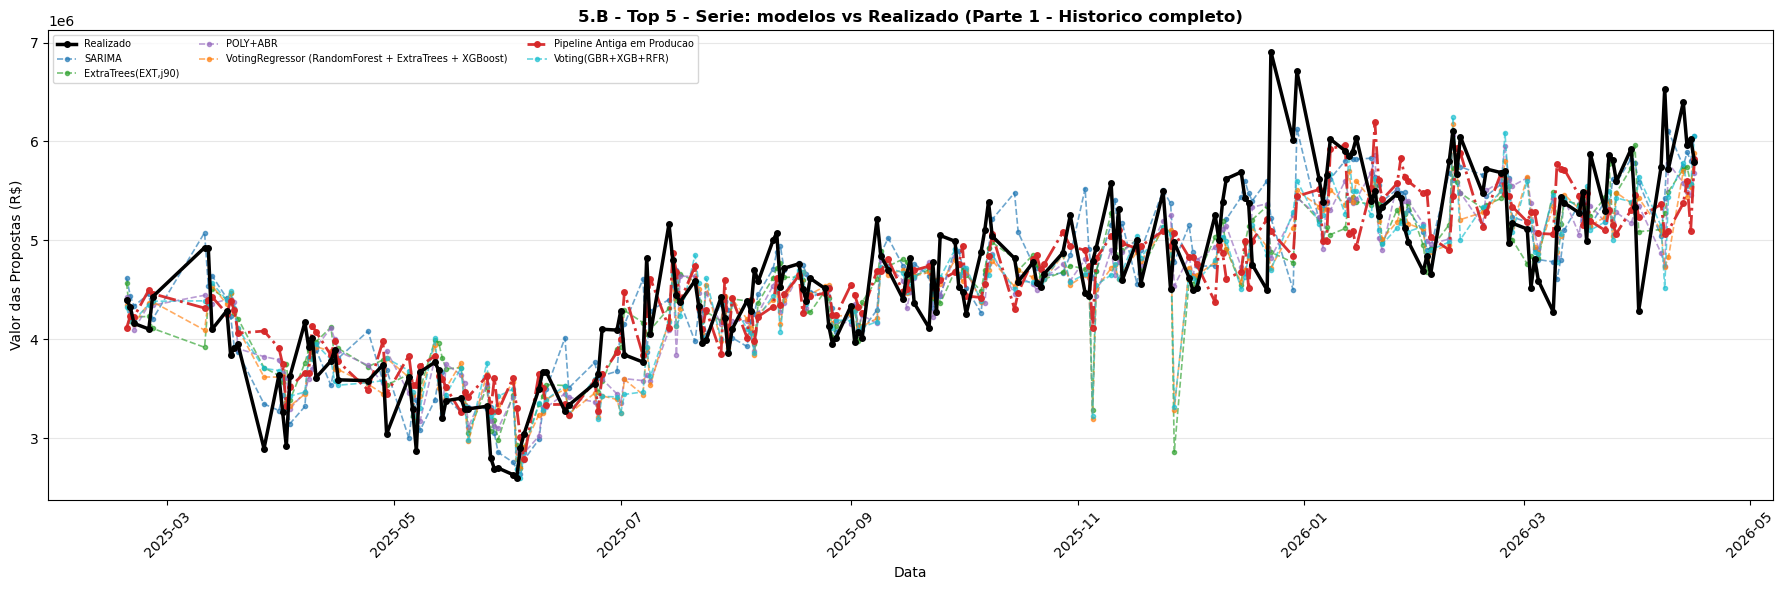

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\daniel.ramazzotte\AppData\Local\anaconda3\Lib\site-packages\PIL\ImageFile.py", line 648, in _save
    fh = fp.fileno()
         ^^^^^^^^^
AttributeError: '_idat' object has no attribute 'fileno'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\daniel.ramazzotte\AppData\Local\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\daniel.ramazzotte\AppData\Local\Temp\ipykernel_16860\1506866139.py", line 14, in <module>
    comparar_todos_modelos(_df_db, df_ranking_int.loc[_top5_ref], _UNID, titulo='5.B - Top 5')
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\daniel.ramazzotte\AppData\Local\Temp\ipykernel_16860\2025045050.py", line 329, in comparar_

In [68]:
# ============================================================
# 5.B - Top 5 - SELECAO FINAL (via comparar_todos_modelos)
# ============================================================
_rank_sem_ref = df_ranking_int[df_ranking_int.index != NOME_ANTIGO]
_top5     = _rank_sem_ref.head(5).index.tolist()
_top5_ref = _top5 + ([NOME_ANTIGO] if NOME_ANTIGO not in _top5 else [])

_top5_ref.append('Voting(GBR+XGB+RFR)')
# _top5_ref.remove('SE(ETR)+SE(RFR)+LSVR')
_top5_ref.remove('MAS+OHE+MAS+OHE+SE(SGDR)+MMS+LSVR')



comparar_todos_modelos(_df_db, df_ranking_int.loc[_top5_ref], _UNID, titulo='5.B - Top 5')

# --- Sumario final ---
_melhor       = _top5[0]
_rmspe_melhor = df_ranking_int.loc[_melhor, 'RMSPE (%)']
_parte_melhor = df_ranking_int.loc[_melhor, 'Parte']
_rmspe_antigo = df_ranking_int.loc[NOME_ANTIGO, 'RMSPE (%)'] if NOME_ANTIGO in df_ranking_int.index else None

print(f'\n{"="*60}')
print('SELECAO FINAL')
print(f'{"="*60}')
print(f'  Melhor modelo  : {_melhor}  [{_parte_melhor}]')
print(f'  RMSPE          : {_rmspe_melhor:.2f}%')
if _rmspe_antigo is not None:
    _ganho = _rmspe_antigo - _rmspe_melhor
    print(f'  Pipeline Antiga: {_rmspe_antigo:.2f}%')
    print(f'  Melhoria       : {_ganho:+.2f} p.p.')
print(f'{"="*60}')
print('\nTop 5 candidatos:')
for _i, _n in enumerate(_top5, 1):
    print(f'  {_i}. {_n}  (RMSPE {df_ranking_int.loc[_n, "RMSPE (%)"]:.2f}%)')


In [ ]:
df_ranking_int[['MAPE Medio (%)', 'R2', 'Vies (real-prev)', 'DP Erro']] 

,MAPE Medio (%),R2,Vies (real-prev),DP Erro
SARIMA,7.17,0.76,-6316.90,427119.70
Pipeline Antiga em Producao,7.19,0.75,29980.40,433778.40
"ExtraTrees(EXT,j90)",7.20,0.72,79400.80,450801.00
POLY+ABR,8.12,0.68,113974.90,472644.70
SE(ETR)+SE(RFR)+LSVR,8.11,0.66,134800.50,486255.90
...,...,...,...,...
KNN,11.37,0.08,257241.50,788673.20
PCA(6) + GradientBoosting,11.10,0.08,258561.40,789714.30
LinearRegression,12.48,0.12,13466.10,812346.60
NRM+SS+RS+PCA+ABR,11.28,0.05,167969.90,824790.90


---
### 4.C - Comparacao Individual de um Modelo (automatizada)

Defina `MODELO_SELECIONADO` e a funcao `comparar_modelo(...)` reproduz **todos os graficos
da Secao 5.C para esse unico modelo** (vs Realizado vs Pipeline Antiga) e imprime as
**metricas comparativas contra a Pipeline Antiga** em um print.


### 5.D - ExtraTrees(EXT,j90) | Parte 1 - Historico completo


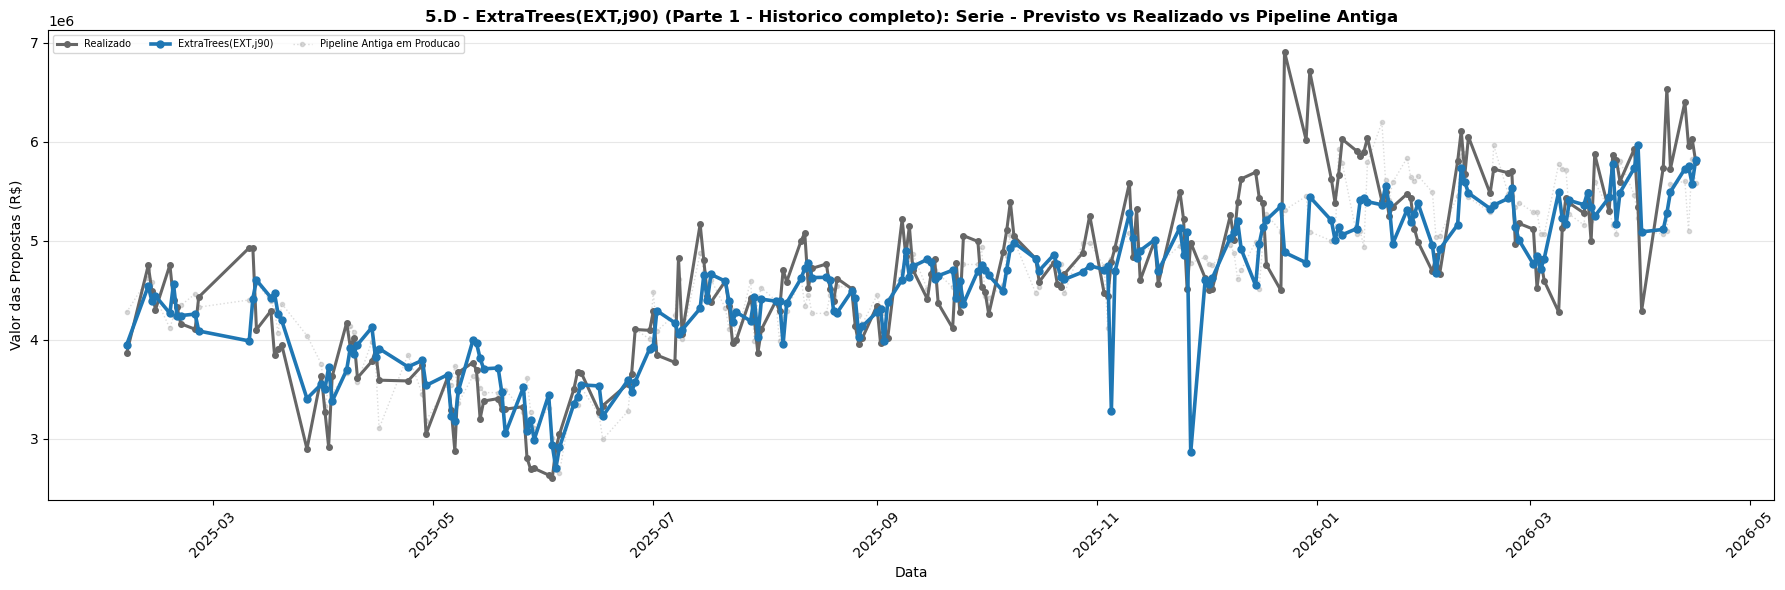

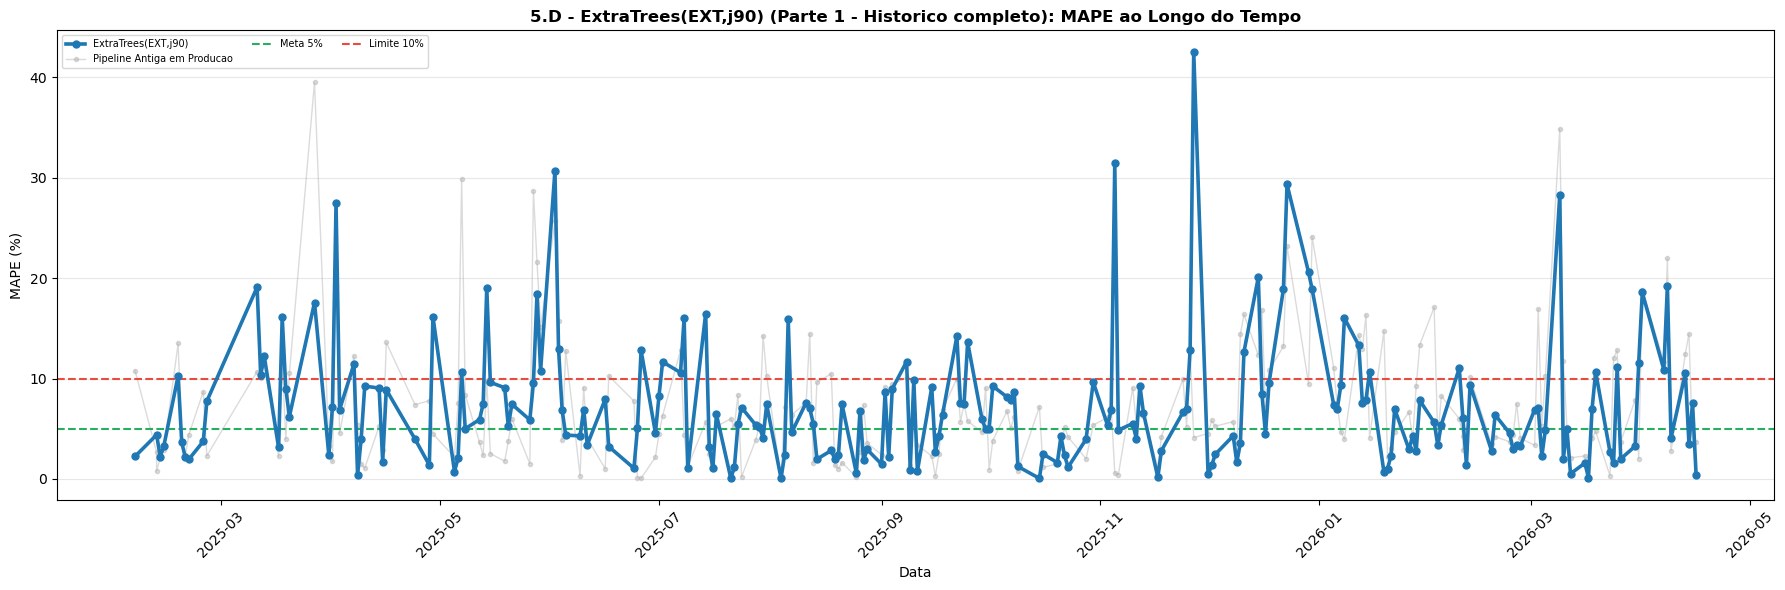

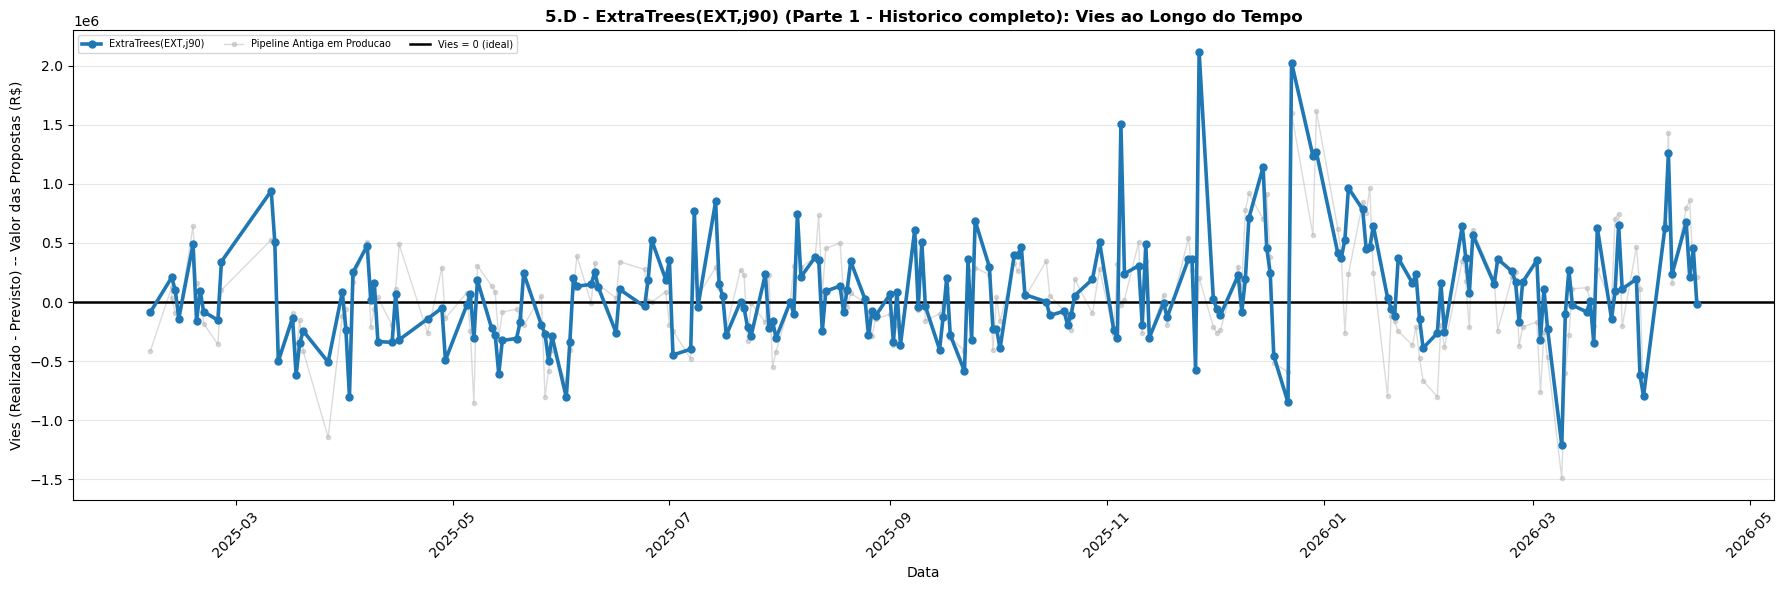


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,"ExtraTrees(EXT,j90)",7.20,9.61,0.72,79400.80,79400.80,0.66,331794.50,450801.00,9.77,5.88,0.05,42.56,92/209,164/209,209
1,Pipeline Antiga em Producao,7.19,9.54,0.75,29980.40,29980.40,-0.30,328752.10,433778.40,9.38,5.29,0.05,39.52,97/211,156/211,211



### 5.D - ExtraTrees(EXT,j90) | Parte 2 - Janeiro em diante


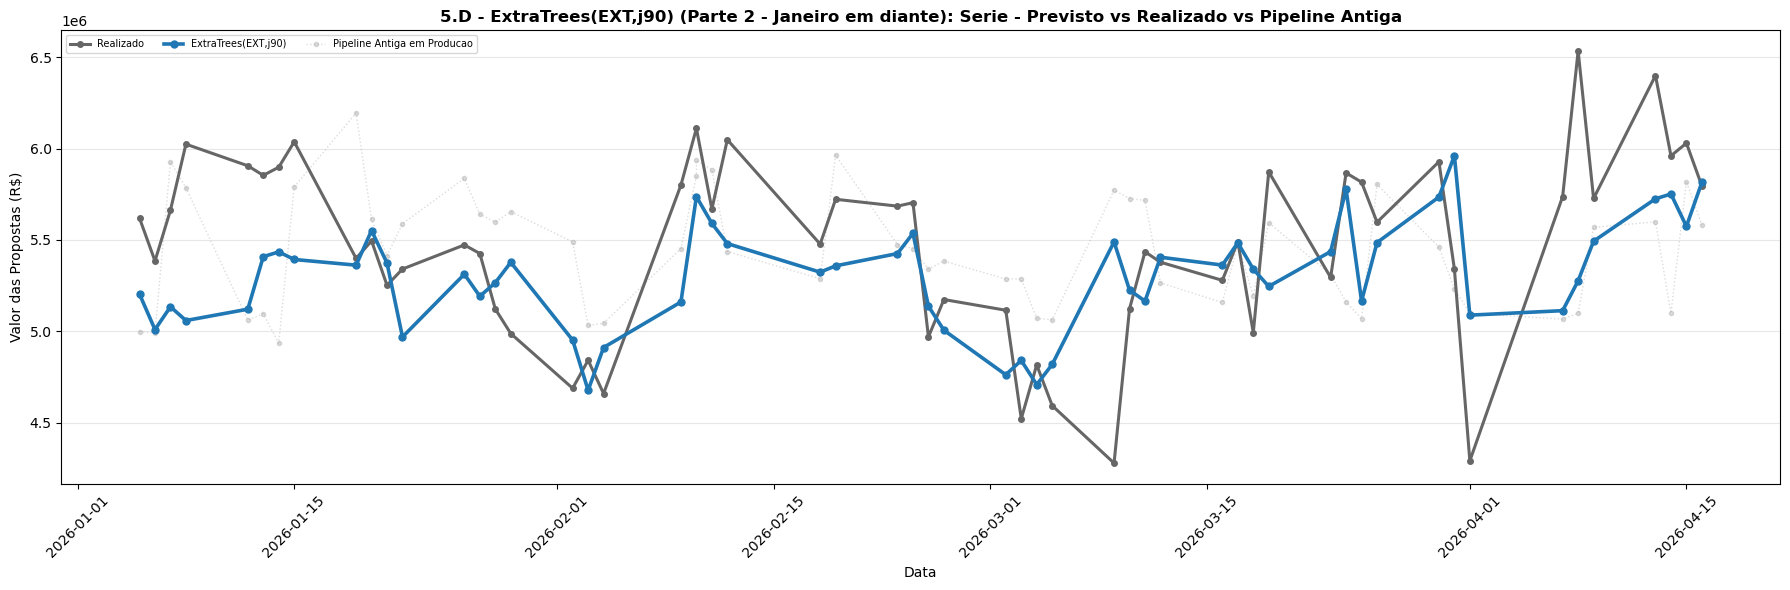

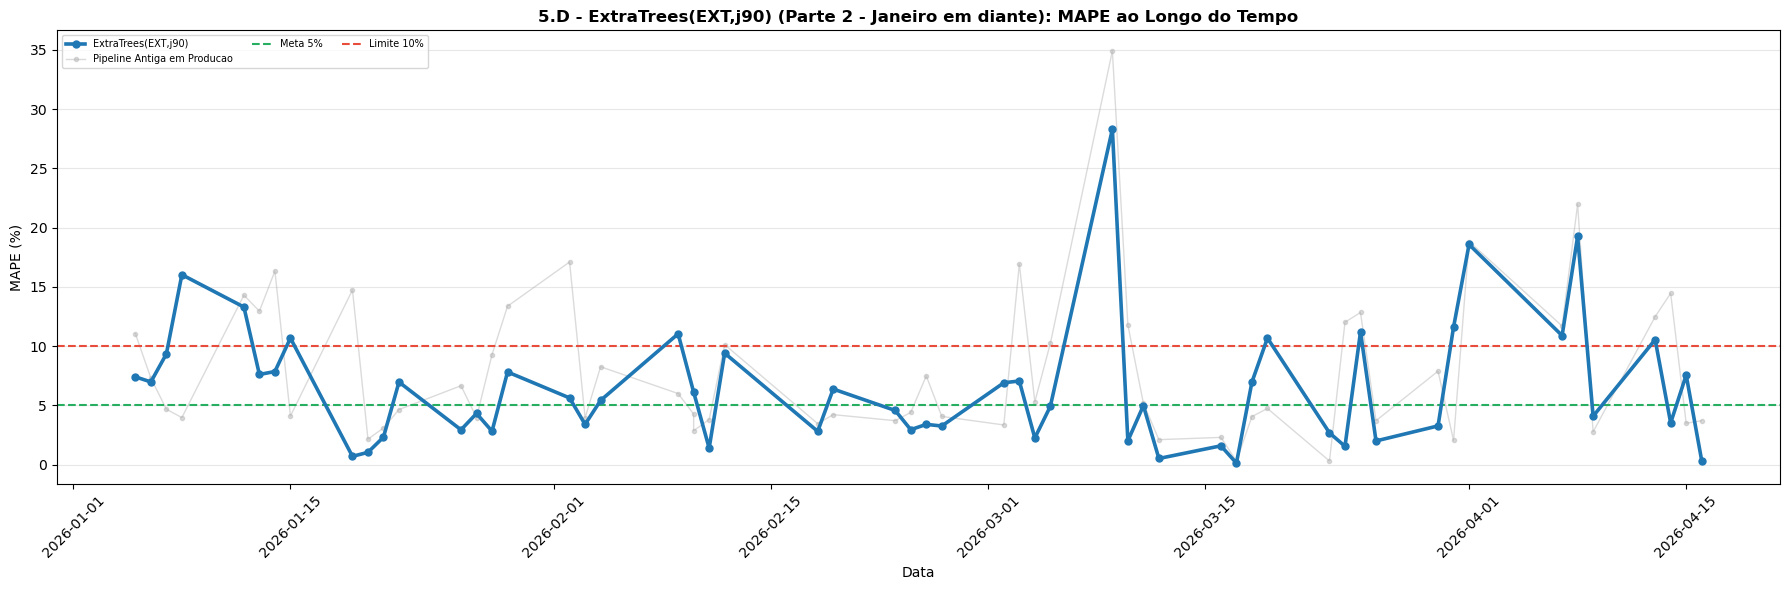

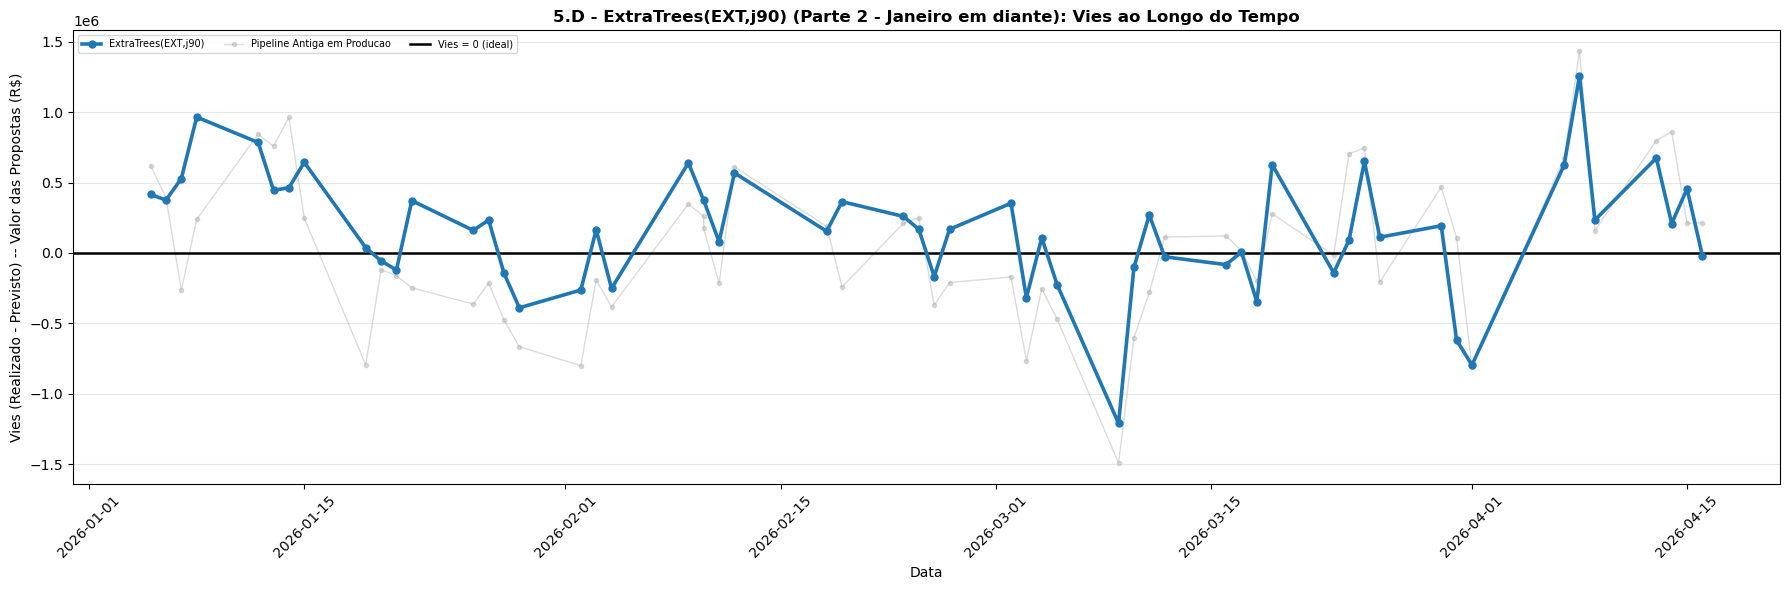


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,"ExtraTrees(EXT,j90)",6.49,8.38,0.17,162485.90,162485.90,2.38,354753.50,423831.00,7.75,5.41,0.12,28.29,27/55,43/55,55
1,Pipeline Antiga em Producao,7.95,10.14,-0.15,36022.20,36022.20,-0.11,428638.30,534534.70,9.76,4.95,0.29,34.90,28/56,37/56,56



### 5.D - ExtraTrees(EXT,j90) | Parte 3 - Recorte de marco


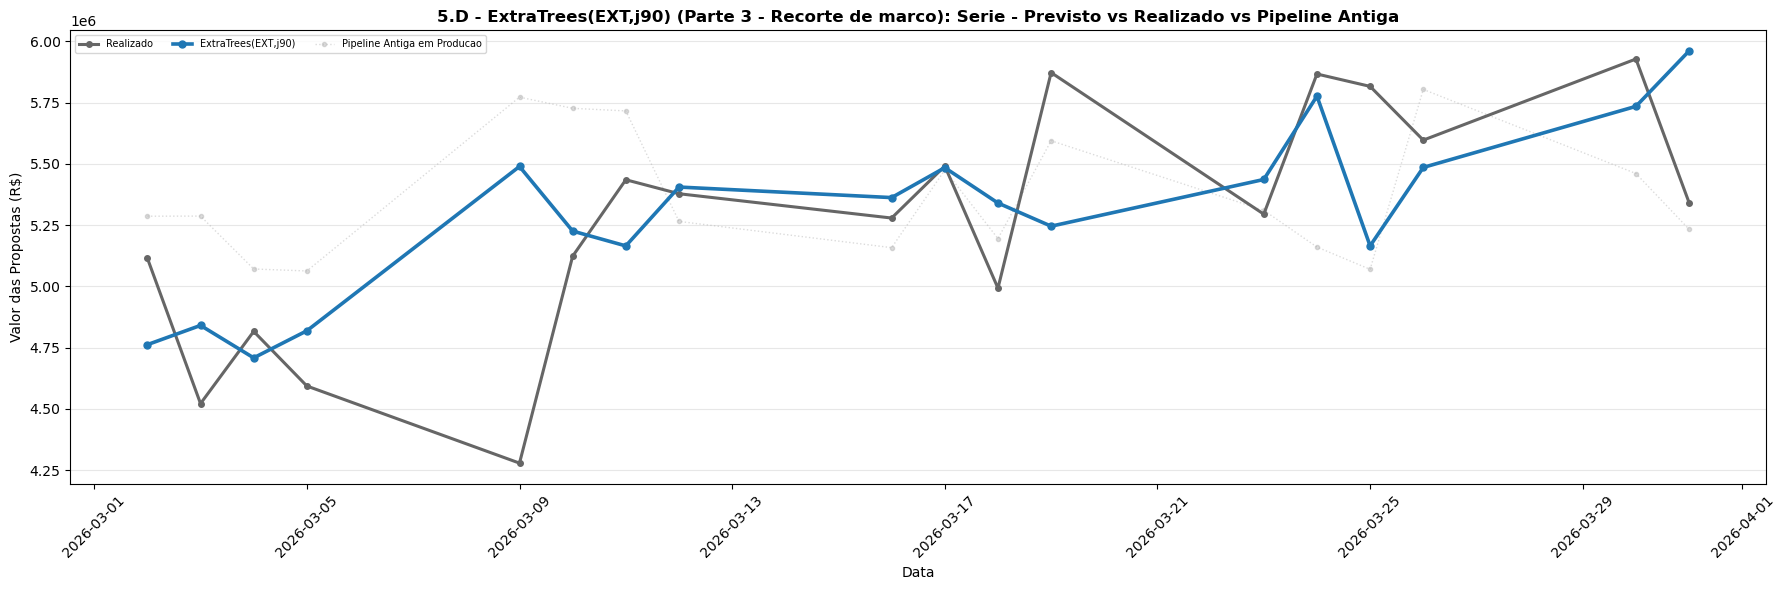

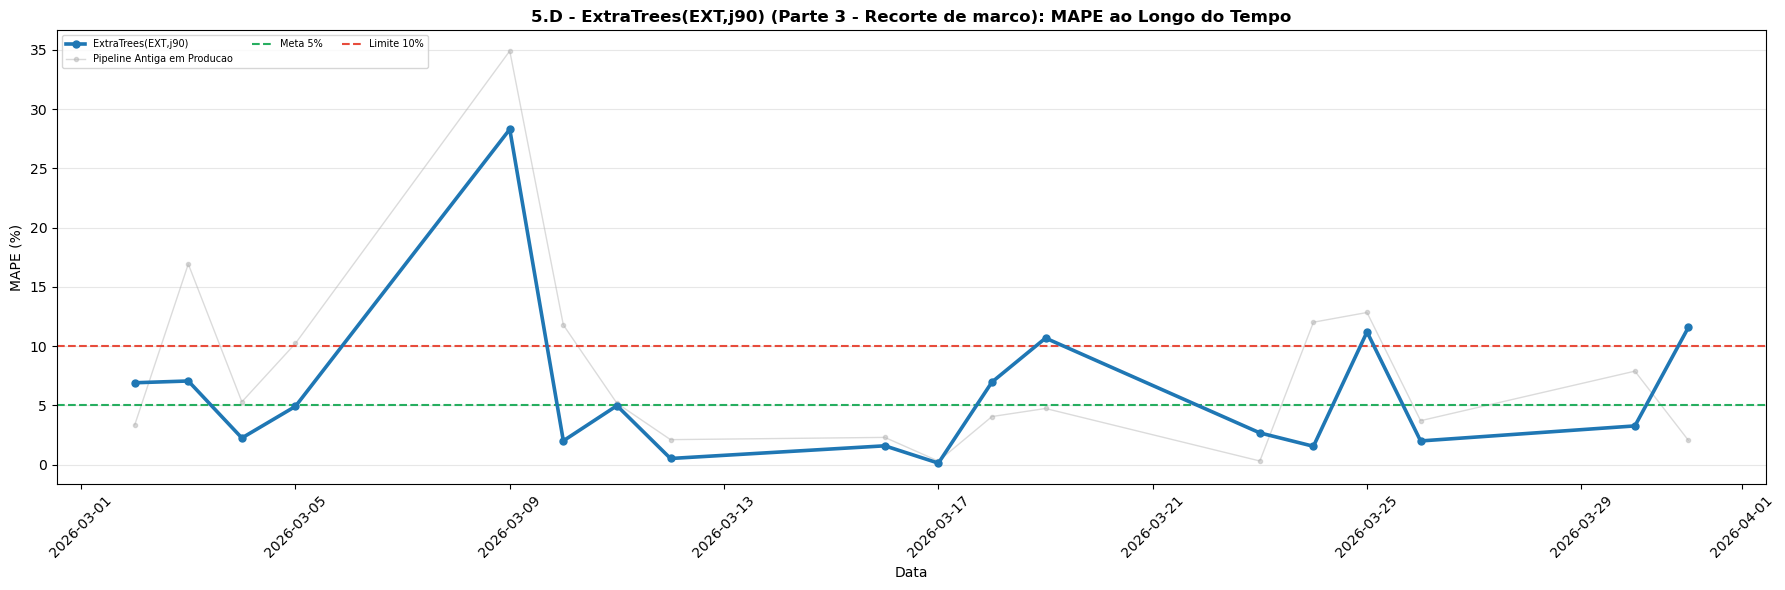

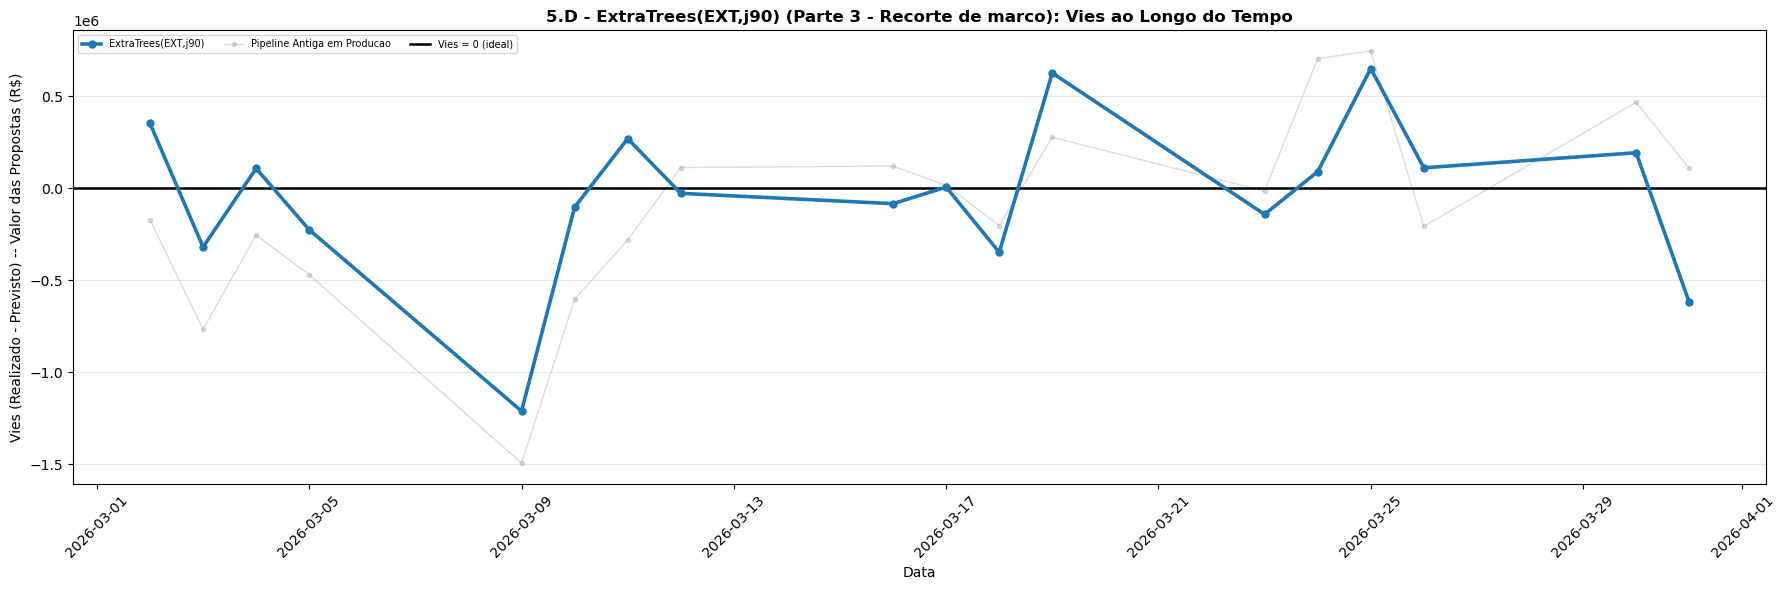


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,"ExtraTrees(EXT,j90)",6.02,8.83,0.18,-36981.50,36981.50,-1.26,304759.30,422852.40,8.03,4.08,0.12,28.29,11/18,14/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105978.80,105978.80,-2.86,389851.20,518702.30,9.86,4.95,0.29,34.90,9/18,12/18,18



### 5.D - ExtraTrees(EXT,j90) | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


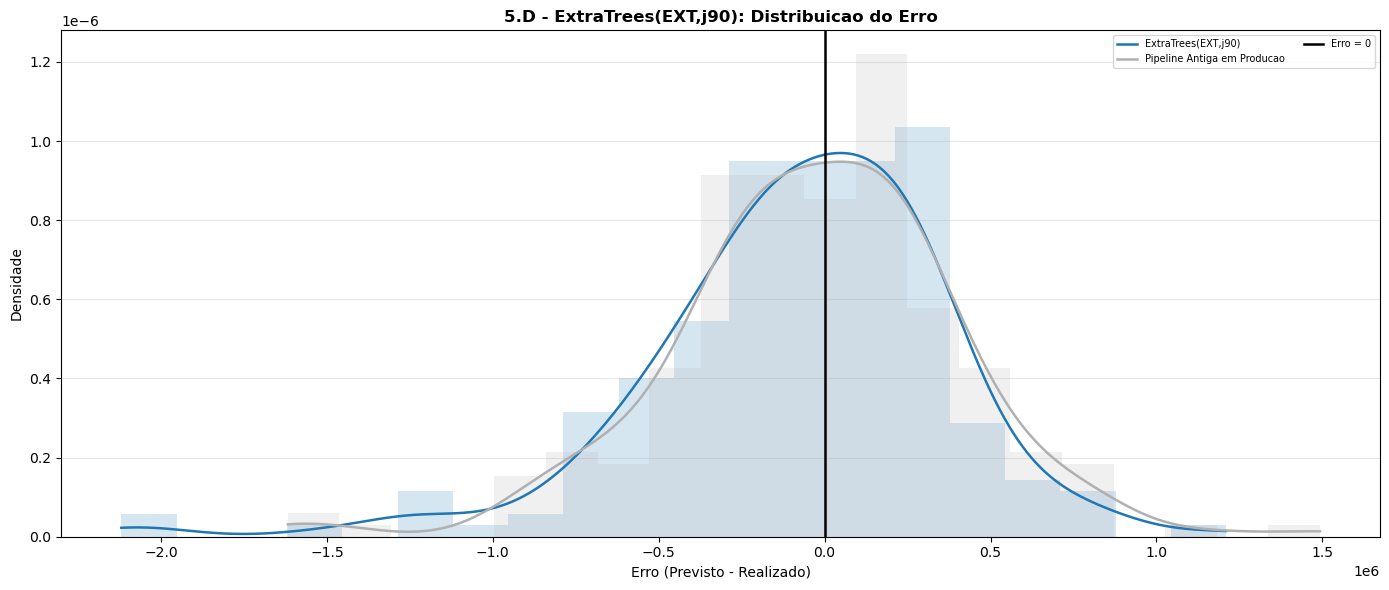

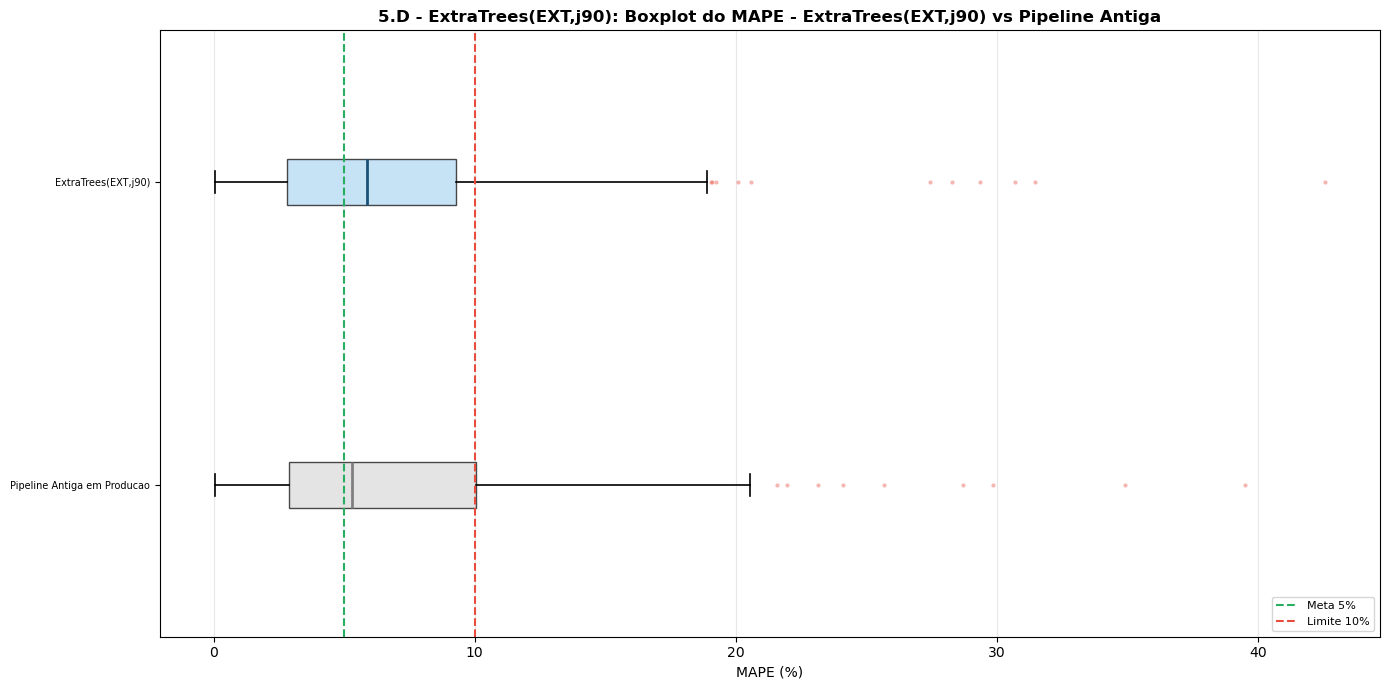

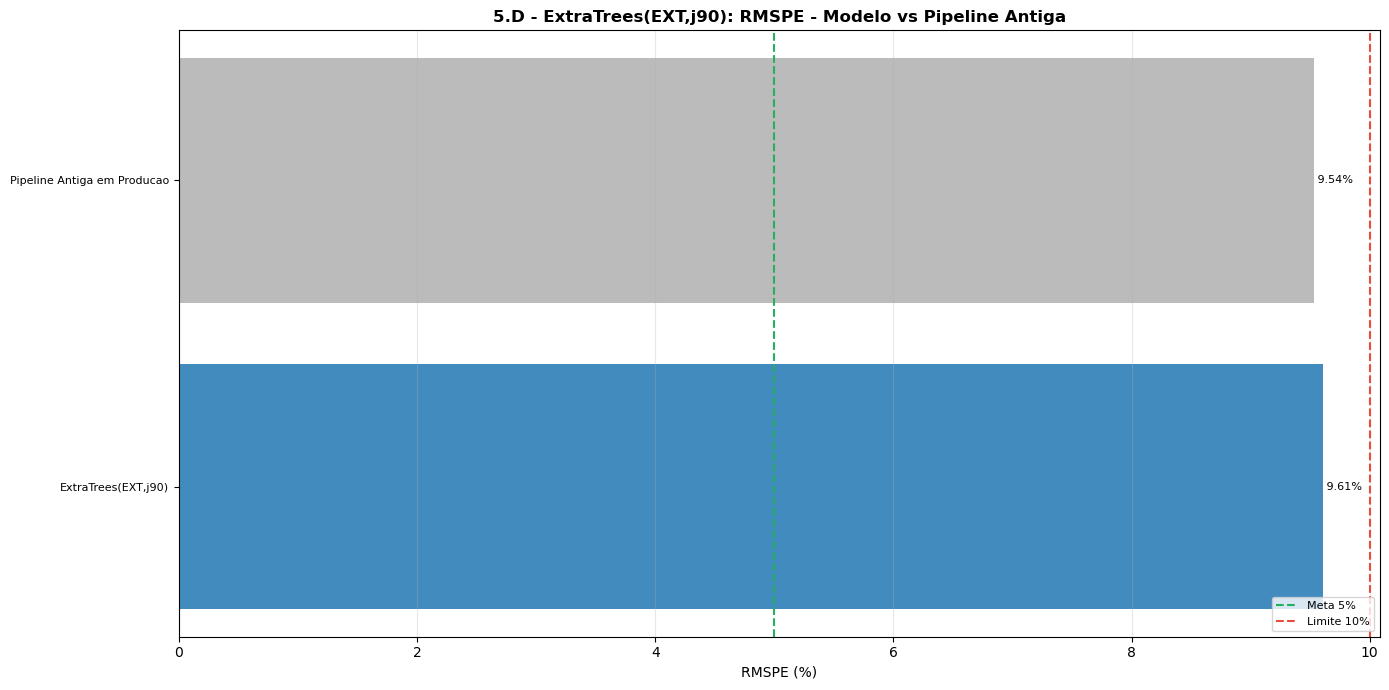

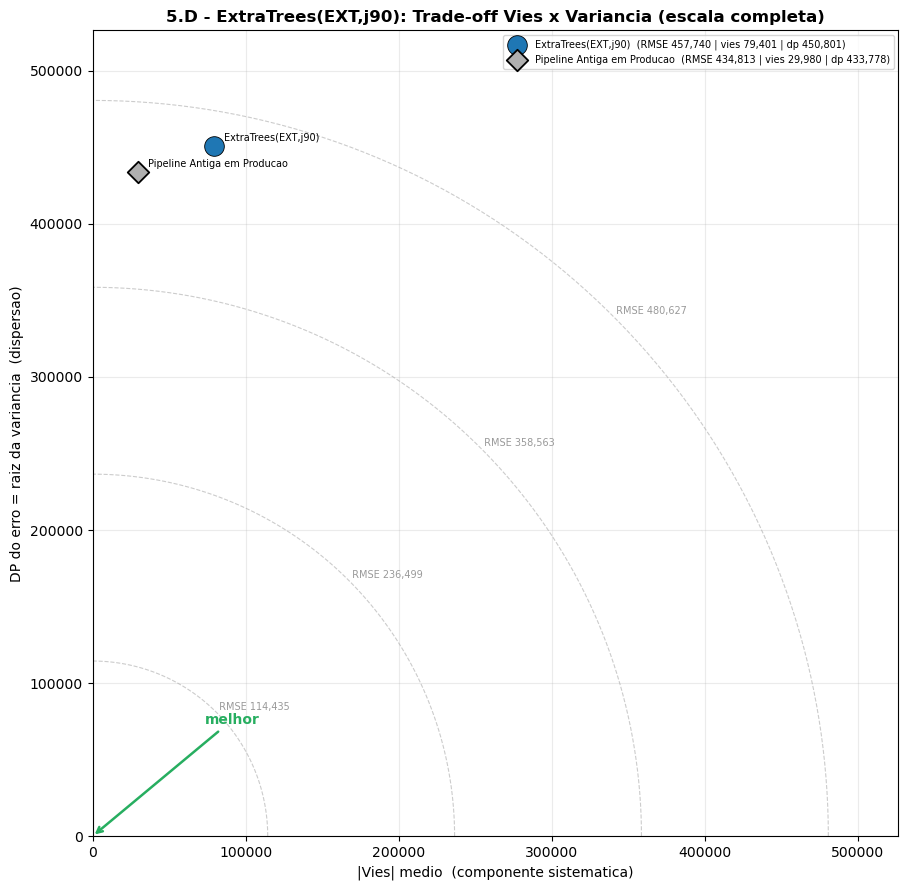


-- Metricas por mes -- ExtraTrees(EXT,j90):


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,"ExtraTrees(EXT,j90)",2025-02,4.16,4.91,0.27,61080.20,61080.20,1.19,185458.90,215392.90,4.94,3.45,1.96,10.28,8/10,9/10,10
1,"ExtraTrees(EXT,j90)",2025-03,10.67,12.13,0.29,-91496.90,91496.90,-3.60,432901.90,491314.20,12.12,10.36,2.34,19.10,2/9,4/9,9
2,"ExtraTrees(EXT,j90)",2025-04,8.29,10.84,0.00,-134386.40,134386.40,-4.53,283618.50,325737.60,8.98,7.19,0.39,27.45,5/13,10/13,13
3,"ExtraTrees(EXT,j90)",2025-05,8.46,9.78,0.23,-200115.70,200115.70,-6.53,266263.10,225242.00,6.89,7.49,0.73,19.06,2/15,11/15,15
4,"ExtraTrees(EXT,j90)",2025-06,8.01,10.88,0.52,32494.40,32494.40,-0.09,254357.00,320785.80,9.47,5.06,1.06,30.70,6/13,10/13,13
5,"ExtraTrees(EXT,j90)",2025-07,6.50,8.07,0.05,1219.20,1219.20,-0.56,283501.60,365113.70,8.50,5.43,0.07,16.47,6/17,13/17,17
6,"ExtraTrees(EXT,j90)",2025-08,4.49,5.88,0.19,92984.50,92984.50,1.81,207042.00,259026.00,5.74,2.88,0.05,15.91,10/16,15/16,16
7,"ExtraTrees(EXT,j90)",2025-09,6.70,7.84,0.12,5641.00,5641.00,-0.42,307642.60,363074.60,7.94,6.92,0.77,14.21,7/18,15/18,18
8,"ExtraTrees(EXT,j90)",2025-10,4.69,5.71,0.15,69688.50,69688.50,1.13,227938.10,272708.20,5.68,4.09,0.05,9.65,8/14,14/14,14
9,"ExtraTrees(EXT,j90)",2025-11,10.41,15.45,-3.27,260063.30,260063.30,4.91,510474.50,712289.10,14.51,6.59,0.15,42.56,4/14,11/14,14


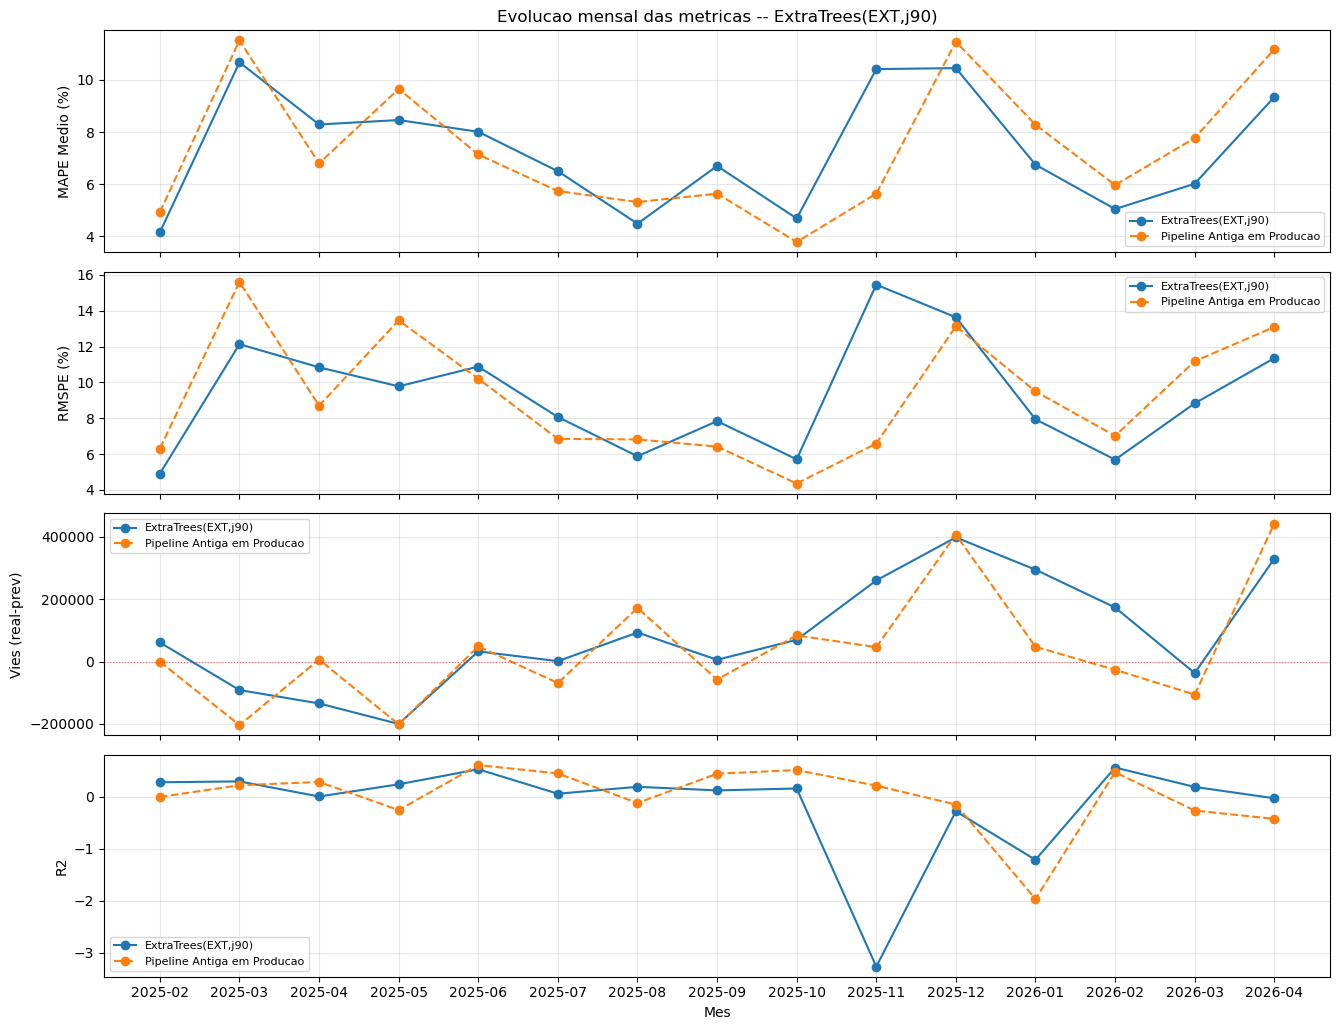

COMPARATIVO  |  ExtraTrees(EXT,j90)   vs   Pipeline Antiga em Producao
Metrica                     Modelo   Pipeline Antiga         Delta   Resultado
------------------------------------------------------------------------------------
MAPE Medio (%)                 7.2              7.19         +0.01   pior
RMSPE (%)                     9.61              9.54         +0.07   pior
R2                            0.72             0.748         -0.03   pior
Vies (real-prev)           79400.8           29980.4     +49420.40   
|Vies|                     79400.8           29980.4     +49420.40   pior
MAE                       331794.5          328752.1      +3042.40   pior
DP Erro                   450801.0          433778.4     +17022.60   pior
Mediana (%)                   5.88              5.29         +0.59   pior
N                              209               211         -2.00   


In [ ]:
# comparar_modelo('ExtraTrees(EXT,j90)')


In [ ]:
# Teste: correlacao ao quadrado (Pearson r^2) entre Previsto e Realizado
# ExtraTrees(EXT,j90), filtrado para 2025-11, a partir de _df_db
_teste_mod  = 'ExtraTrees(EXT,j90)'
_teste_df   = _df_db[_df_db['Modelo'] == _teste_mod].copy()
_teste_df   = _teste_df[_teste_df['Dia Prevista'].dt.to_period('M') == '2025-11']

_teste_prev = pd.to_numeric(_teste_df['Valor Previsto'],  errors='coerce')
_teste_real = pd.to_numeric(_teste_df['Valor Realizado'], errors='coerce')
_teste_r2_corr = np.corrcoef(_teste_prev, _teste_real)[0, 1] ** 2

print(f"{_teste_mod} | 2025-11 | N={len(_teste_df)} | correlacao^2 (Pearson r^2) = {_teste_r2_corr:.4f}")
_teste_df[['Dia Prevista', 'Valor Previsto', 'Valor Realizado']].sort_values('Dia Prevista')


ExtraTrees(EXT,j90) | 2025-11 | N=14 | correlacao^2 (Pearson r^2) = 0.0248


,Dia Prevista,Valor Previsto,Valor Realizado
23628,2025-11-03,4707787.10,4469408.50
23630,2025-11-04,4740361.60,4435878.20
23632,2025-11-05,3282579.70,4788540.30
23634,2025-11-06,4688249.10,4927722.50
23638,2025-11-10,5273703.90,5581241.70
23640,2025-11-11,5028739.50,4834662.90
23642,2025-11-12,4821627.80,5316158.40
23644,2025-11-13,4899649.90,4598378.90
23648,2025-11-17,5008548.70,5000847.30
23650,2025-11-18,4692550.70,4563668.20


## 5 - Metricas de ranking por mes (um modelo)

`metricas_por_mes(modelo)` pega **um** modelo e calcula o mesmo bloco de metricas do ranking integrado (MAPE/RMSPE/R2/Vies/MAE/DP Erro...), mas quebrado por **mes-calendario** da base (`Dia Prevista`). Usa `_df_db` (previsoes cruas, sem correcao de vies) por padrao. A linha `TOTAL` repete o agregado de todos os meses. O nome do modelo aparece como **coluna**, nunca como indice.

In [ ]:
# Exemplo: melhor modelo do ranking integrado, mes a mes
_mod_exemplo = df_ranking_int.index[0]
print(f'Metricas por mes -- {_mod_exemplo}:')
display(metricas_por_mes(_mod_exemplo))

# Pipeline antiga em producao como referencia
print(f'\nMetricas por mes -- {NOME_ANTIGO}:')
display(metricas_por_mes(NOME_ANTIGO))


Metricas por mes -- SARIMA:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMA,2025-02,4.85,5.58,0.12,-62740.90,62740.90,-1.59,212898.30,238668.50,5.48,4.73,0.79,9.63,6/10,10/10,10
1,SARIMA,2025-03,6.94,8.46,0.72,-77359.40,77359.40,-2.43,266488.90,302702.50,7.47,8.29,0.58,15.82,4/9,6/9,9
2,SARIMA,2025-04,9.44,11.36,-0.30,-15812.00,15812.00,-1.32,334288.00,401164.70,11.05,6.05,2.90,21.29,4/13,8/13,13
3,SARIMA,2025-05,8.19,10.68,0.01,-20148.40,20148.40,-1.56,262201.70,341485.70,10.45,6.19,0.65,18.30,7/15,9/15,15
4,SARIMA,2025-06,8.71,10.21,0.43,94511.50,94511.50,2.27,299928.40,341529.70,10.08,8.72,1.16,22.24,4/13,8/13,13
5,SARIMA,2025-07,7.48,9.88,-0.33,18533.60,18533.60,-0.31,324588.70,432460.80,10.06,5.44,0.10,22.55,7/17,12/17,17
6,SARIMA,2025-08,5.02,6.07,0.22,7709.20,7709.20,-0.04,223730.20,269405.80,5.97,4.64,0.23,10.48,8/16,15/16,16
7,SARIMA,2025-09,6.62,8.04,0.04,804.60,804.60,-0.49,305943.60,379820.30,8.31,6.75,0.06,17.68,7/18,15/18,18
8,SARIMA,2025-10,6.46,7.60,-0.46,-219.20,219.20,-0.32,312899.80,370467.40,7.71,6.02,0.29,13.73,6/14,11/14,14
9,SARIMA,2025-11,8.75,10.73,-0.83,-168888.20,168888.20,-3.98,414330.50,467386.30,9.52,7.47,0.01,23.44,5/14,9/14,14



Metricas por mes -- Pipeline Antiga em Producao:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,Pipeline Antiga em Producao,2025-02,4.93,6.31,-0.01,-480.80,480.80,-0.33,213401.90,275503.80,6.27,2.89,0.77,13.49,8/11,9/11,11
1,Pipeline Antiga em Producao,2025-03,11.51,15.60,0.22,-203781.70,203781.70,-6.90,430902.90,484032.80,11.94,10.50,2.25,39.52,3/9,3/9,9
2,Pipeline Antiga em Producao,2025-04,6.80,8.70,0.28,6267.00,6267.00,-0.31,240935.50,299068.50,8.24,5.24,1.07,20.54,6/13,10/13,13
3,Pipeline Antiga em Producao,2025-05,9.65,13.46,-0.26,-201480.20,201480.20,-7.24,289372.80,330041.50,10.10,5.98,1.51,29.84,7/15,11/15,15
4,Pipeline Antiga em Producao,2025-06,7.14,10.21,0.60,48412.80,48412.80,0.72,217335.40,290082.60,8.56,4.04,0.05,25.68,7/13,9/13,13
5,Pipeline Antiga em Producao,2025-07,5.74,6.85,0.44,-68959.50,68959.50,-2.01,240731.40,271266.10,6.31,5.23,0.20,14.27,7/17,14/17,17
6,Pipeline Antiga em Producao,2025-08,5.32,6.82,-0.12,171862.90,171862.90,3.47,246562.60,274007.20,6.07,4.97,0.05,14.45,8/16,13/16,16
7,Pipeline Antiga em Producao,2025-09,5.64,6.42,0.44,-57742.60,57742.60,-1.73,255085.90,283589.10,6.20,5.73,0.30,10.10,8/18,16/18,18
8,Pipeline Antiga em Producao,2025-10,3.79,4.36,0.51,83733.00,83733.00,1.57,184420.10,197486.30,4.11,4.00,0.80,7.19,8/14,14/14,14
9,Pipeline Antiga em Producao,2025-11,5.64,6.59,0.21,46052.00,46052.00,0.58,278085.10,322930.30,6.58,5.82,0.41,12.71,5/14,13/14,14


### Evolucao mensal das metricas (grafico)

`plot_metricas_mes(modelo, metricas=[...])` plota a evolucao **mes a mes** das metricas escolhidas para **um** modelo: eixo **X = meses**, eixo **Y = metrica(s) selecionada(s)**. Reaproveita `metricas_por_mes()`. Escolha qualquer subconjunto de `_METRICAS_PLOT`. Como as metricas tem escalas diferentes (ex.: MAPE % vs MAE em unidades vs R2 em 0-1), use `subplots=True` para um painel por metrica; `subplots=False` sobrepoe tudo num eixo so. A linha `TOTAL` e omitida (nao e um mes).


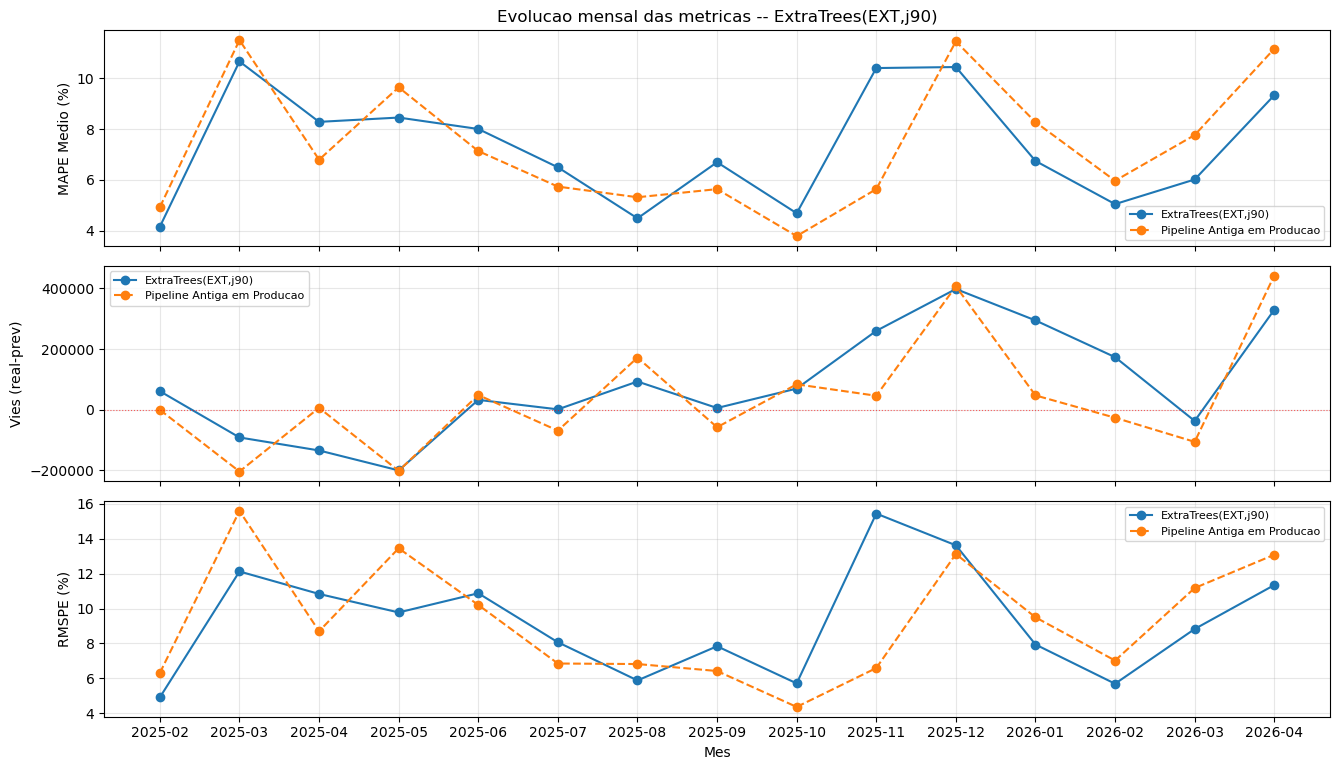

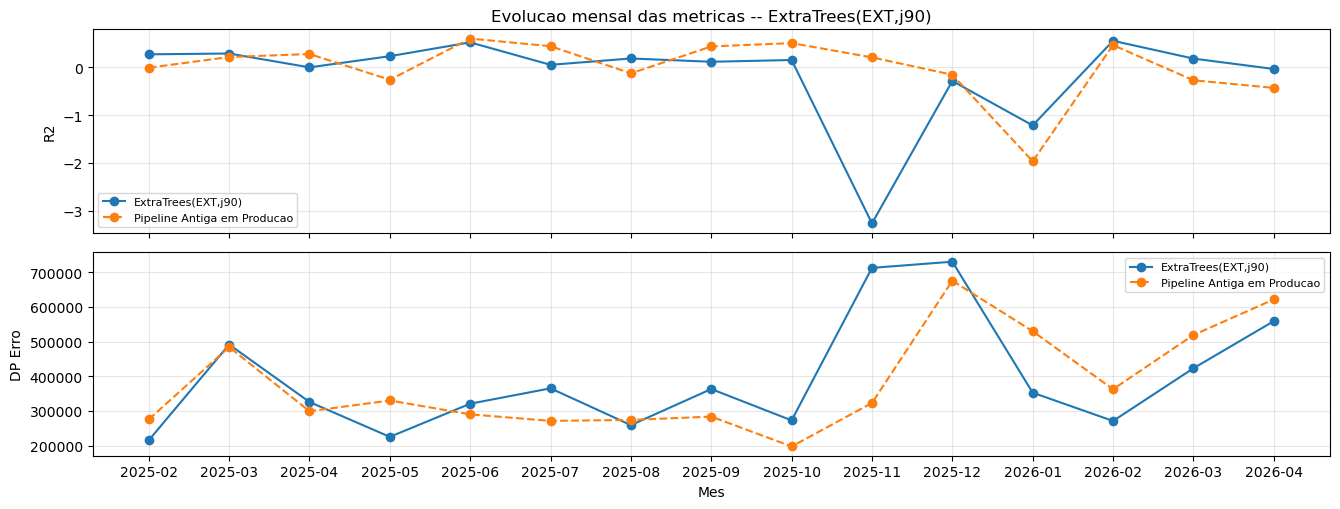

,Mes,Fonte,R2,DP Erro
0,2025-02,"ExtraTrees(EXT,j90)",0.27,215392.90
1,2025-03,"ExtraTrees(EXT,j90)",0.29,491314.20
2,2025-04,"ExtraTrees(EXT,j90)",0.00,325737.60
3,2025-05,"ExtraTrees(EXT,j90)",0.23,225242.00
4,2025-06,"ExtraTrees(EXT,j90)",0.52,320785.80
5,2025-07,"ExtraTrees(EXT,j90)",0.05,365113.70
6,2025-08,"ExtraTrees(EXT,j90)",0.19,259026.00
7,2025-09,"ExtraTrees(EXT,j90)",0.12,363074.60
8,2025-10,"ExtraTrees(EXT,j90)",0.15,272708.20
9,2025-11,"ExtraTrees(EXT,j90)",-3.27,712289.10


In [ ]:
# Exemplo: MAPE e Vies % do melhor modelo, mes a mes
plot_metricas_mes('ExtraTrees(EXT,j90)', ['MAPE Medio (%)', 'Vies (real-prev)', 'RMSPE (%)'],
                  subplots=True)

plot_metricas_mes('ExtraTrees(EXT,j90)', ['R2', 'DP Erro'],
                  subplots=True)


In [ ]:
df_ranking_int.sort_values('MAPE Medio (%)')

,Parte,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Var Erro,Mediana (%),Desvio (%),Min (%),Max (%),< 5%,< 10%,< 50%,< 100%,N
SARIMA,SARIMA,7.17,9.28,0.76,-6316.90,6316.90,-0.72,324521.60,427119.70,9.25,182431232813.70,5.70,5.89,0.01,30.27,89/209,158/209,209/209,209/209,209
Pipeline Antiga em Producao,REF,7.19,9.54,0.75,29980.40,29980.40,-0.30,328752.10,433778.40,9.38,188163689864.10,5.29,6.26,0.05,39.52,97/211,156/211,211/211,211/211,211
"ExtraTrees(EXT,j90)",NEW,7.20,9.61,0.72,79400.80,79400.80,0.66,331794.50,450801.00,9.77,203221550487.90,5.88,6.36,0.05,42.56,92/209,164/209,209/209,209/209,209
Voting(GBR+XGB+RFR),NEW,7.97,10.65,0.66,134676.10,134676.10,1.93,367514.00,485427.50,10.52,235639871890.60,6.44,7.07,0.08,33.35,85/209,146/209,209/209,209/209,209
VotingRegressor (RandomForest + ExtraTrees + XGBoost),P2,8.01,10.58,0.66,142117.20,142117.20,2.06,369446.30,480761.30,10.42,231131437006.90,6.67,6.92,0.03,35.51,90/209,147/209,209/209,209/209,209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NRM+SS+RS+PCA+ABR,P4,11.28,17.49,0.05,167969.90,167969.90,2.30,519182.60,824790.90,17.87,680280026709.40,7.78,13.36,0.06,84.06,72/209,129/209,203/209,209/209,209
KNN,P1,11.37,16.81,0.08,257241.50,257241.50,4.00,533319.10,788673.20,17.09,622005372718.40,8.16,12.38,0.21,81.83,73/209,125/209,204/209,209/209,209
NRM+SE(ENCV)+VT+ABR,P4,12.13,18.54,-0.11,269060.10,269060.10,4.04,562389.60,869253.50,18.83,755601569799.60,8.35,14.02,0.35,80.14,68/209,118/209,203/209,209/209,209
Ridge,P1,12.33,16.76,0.13,14207.20,14207.20,-0.67,576425.80,806030.10,17.46,649684453859.50,9.62,11.36,0.05,63.40,58/209,108/209,204/209,209/209,209


In [ ]:
metricas_por_mes('SE(ETR)+ABR')

,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SE(ETR)+ABR,2025-02,3.71,4.58,0.37,114377.50,114377.50,2.47,165280.80,174167.00,4.00,2.92,0.73,10.22,8/10,9/10,10
1,SE(ETR)+ABR,2025-03,12.18,14.64,0.24,-212270.20,212270.20,-7.05,464694.60,472703.30,11.66,10.65,2.31,33.34,1/9,4/9,9
2,SE(ETR)+ABR,2025-04,11.08,13.54,-0.63,-158766.20,158766.20,-5.49,383358.30,420484.60,11.59,7.73,1.15,26.85,2/13,8/13,13
3,SE(ETR)+ABR,2025-05,8.48,11.07,0.13,-147463.70,147463.70,-5.41,258358.10,284847.10,8.72,5.80,1.05,25.21,6/15,9/15,15
4,SE(ETR)+ABR,2025-06,9.55,11.51,0.34,131907.00,131907.00,2.65,321077.90,355395.10,10.49,9.00,1.21,26.86,4/13,8/13,13
5,SE(ETR)+ABR,2025-07,9.51,11.55,-0.96,170274.90,170274.90,3.52,418552.90,497607.50,11.58,6.93,1.83,23.77,5/17,11/17,17
6,SE(ETR)+ABR,2025-08,6.12,7.28,-0.25,166203.30,166203.30,3.33,280539.80,298061.20,6.61,5.39,0.99,16.26,8/16,13/16,16
7,SE(ETR)+ABR,2025-09,6.93,8.48,-0.12,108239.80,108239.80,1.74,324865.40,395346.60,8.65,6.37,1.06,19.67,6/18,14/18,18
8,SE(ETR)+ABR,2025-10,5.43,6.89,-0.27,179955.60,179955.60,3.42,267324.40,293924.90,6.12,3.30,0.10,11.88,8/14,10/14,14
9,SE(ETR)+ABR,2025-11,13.32,22.79,-8.64,424596.30,424596.30,8.07,665577.60,1057405.40,21.54,7.14,0.73,77.39,3/14,9/14,14



### 5.D - POLY+ABR | Parte 1 - Historico completo


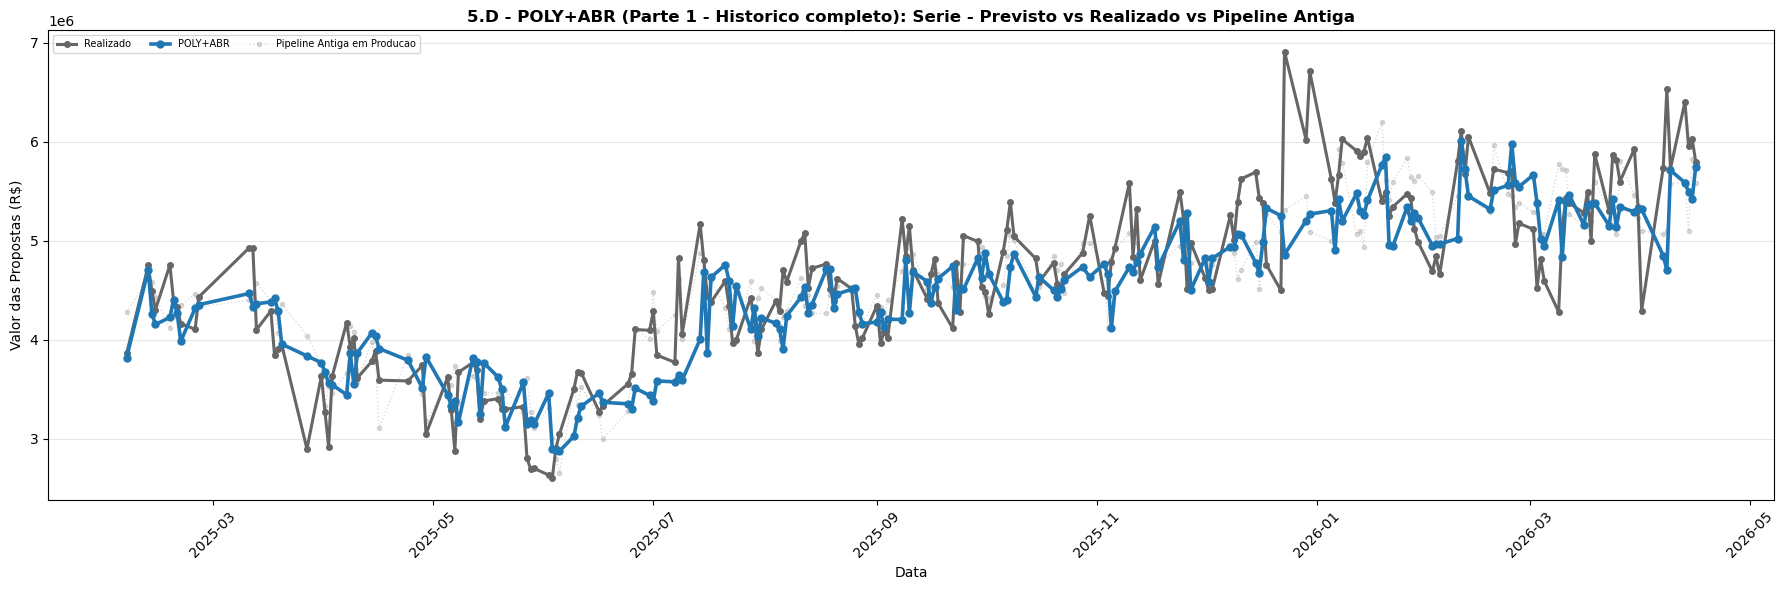

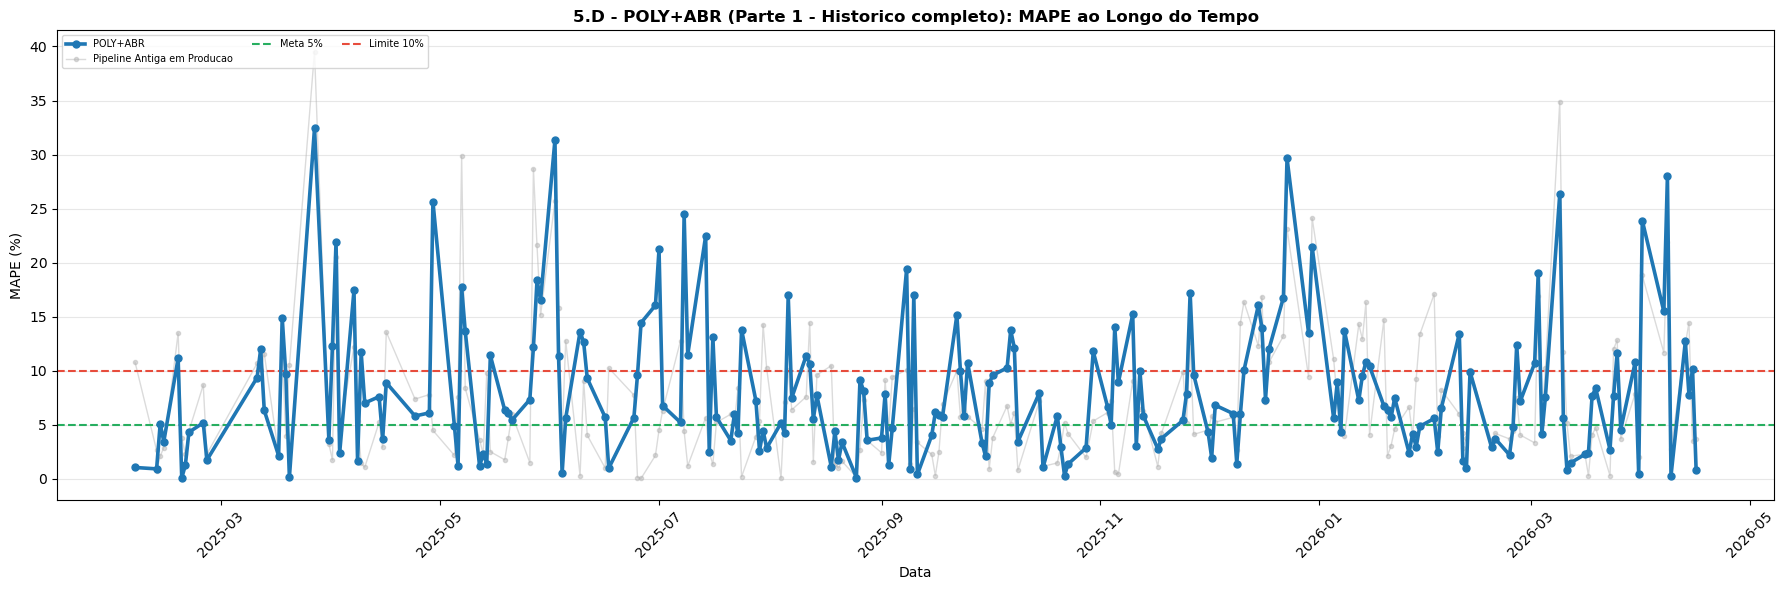

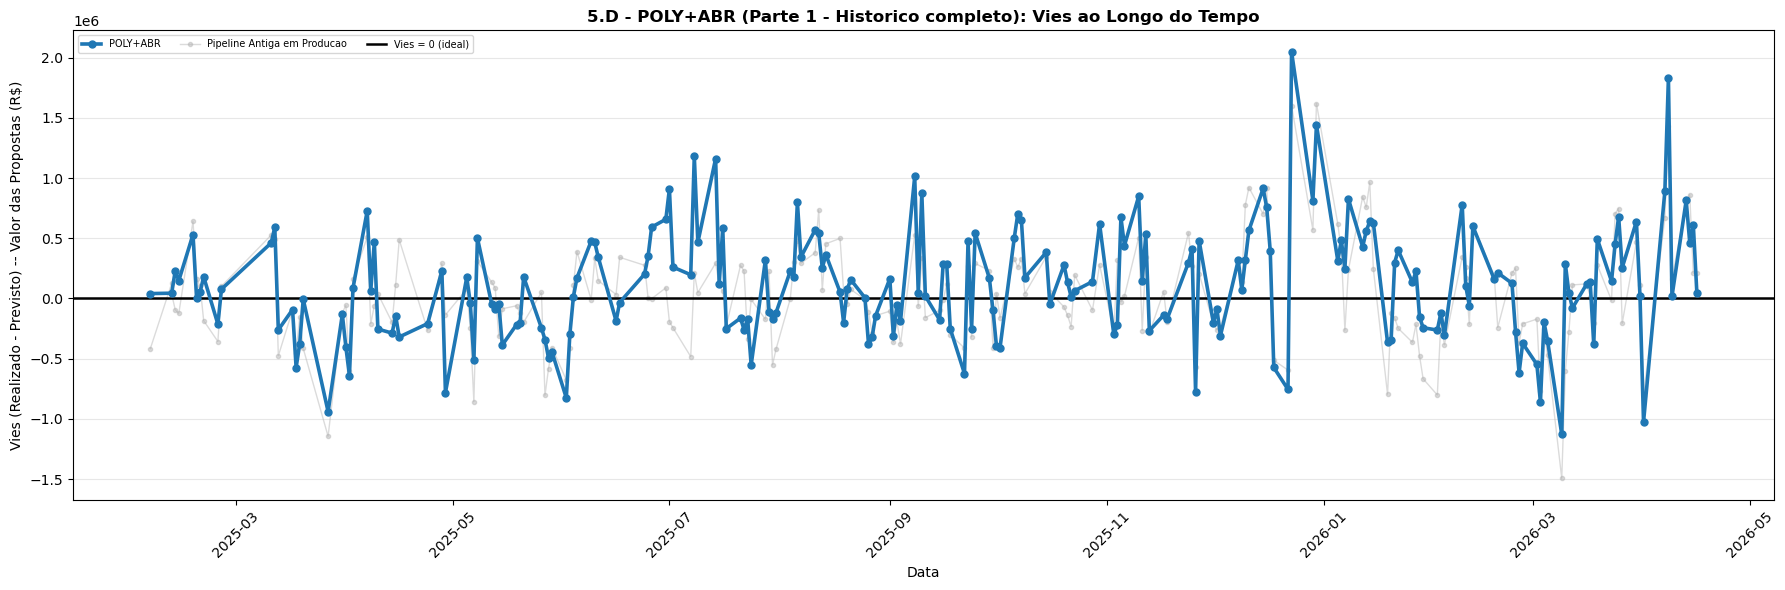


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,POLY+ABR,8.12,10.33,0.68,113974.90,113974.90,1.43,373792.80,472644.70,10.24,6.34,0.09,32.44,75/209,144/209,209
1,Pipeline Antiga em Producao,7.19,9.54,0.75,29980.40,29980.40,-0.30,328752.10,433778.40,9.38,5.29,0.05,39.52,97/211,156/211,211



### 5.D - POLY+ABR | Parte 2 - Janeiro em diante


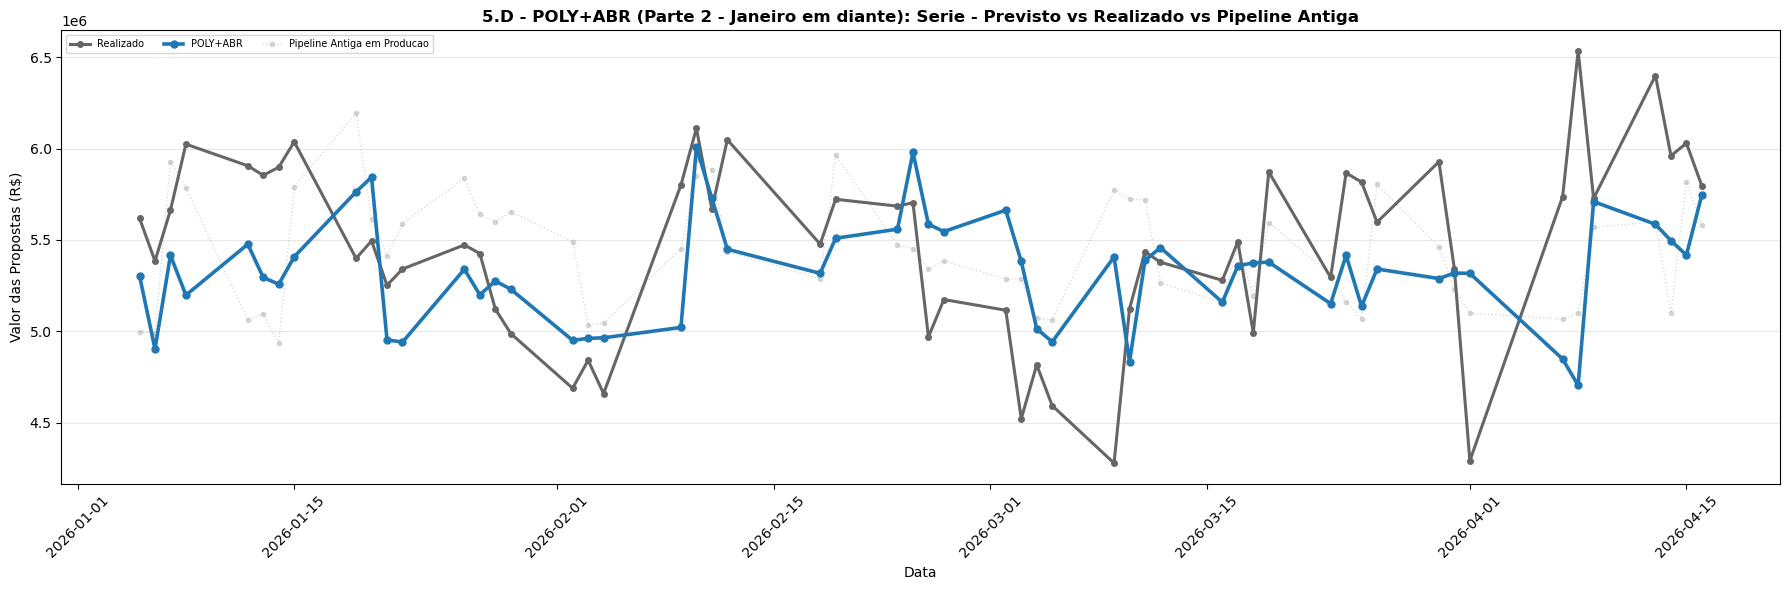

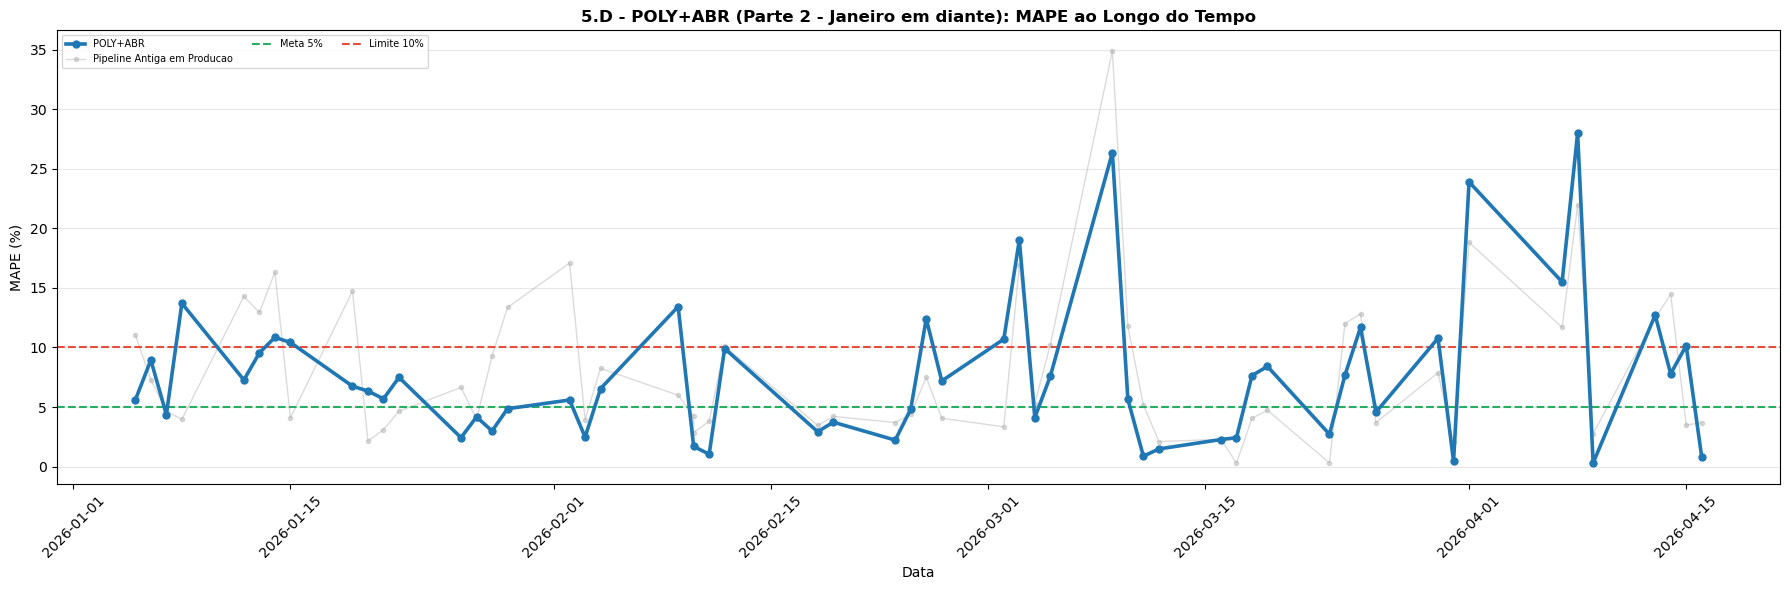

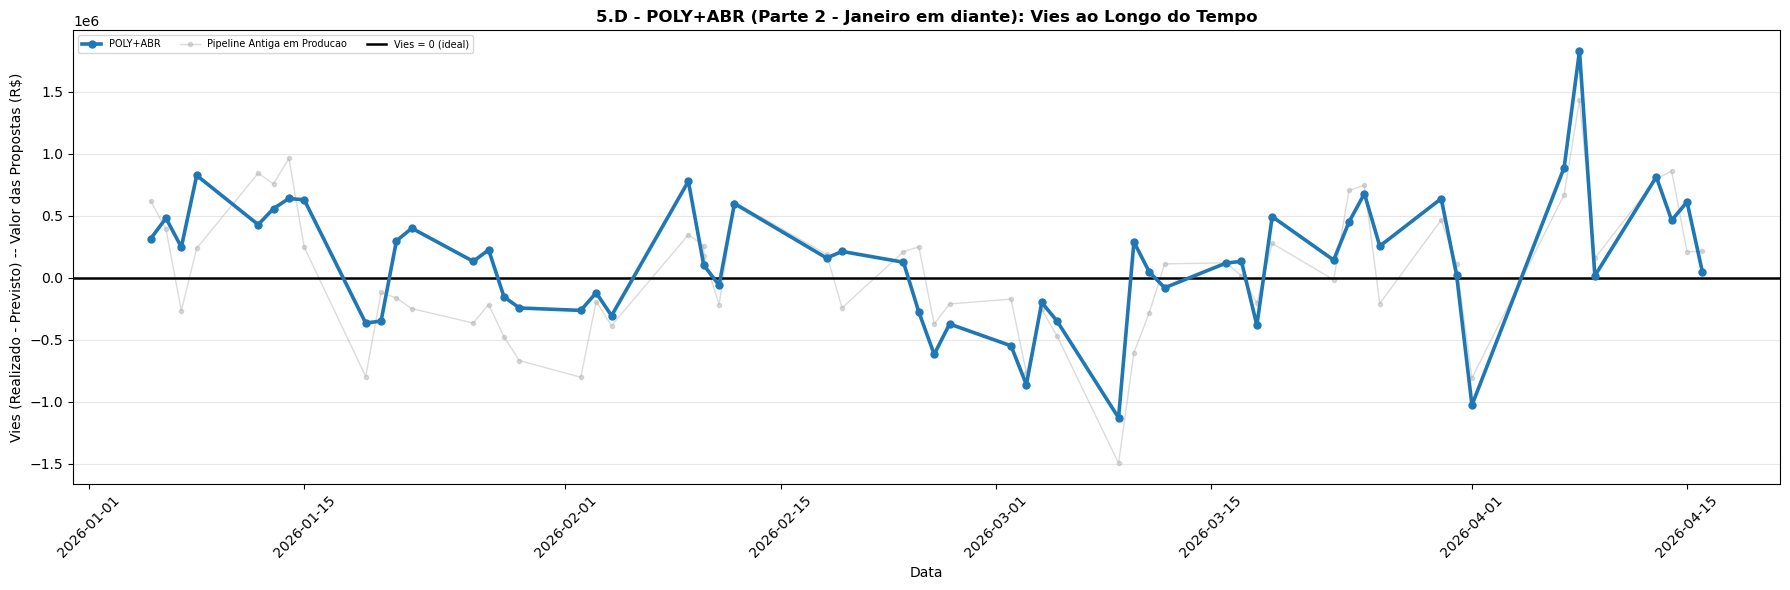


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,POLY+ABR,7.62,9.74,-0.14,135008.30,135008.30,1.73,414553.50,512672.40,9.38,6.55,0.30,28.00,22/55,40/55,55
1,Pipeline Antiga em Producao,7.95,10.14,-0.15,36022.20,36022.20,-0.11,428638.30,534534.70,9.76,4.95,0.29,34.90,28/56,37/56,56



### 5.D - POLY+ABR | Parte 3 - Recorte de marco


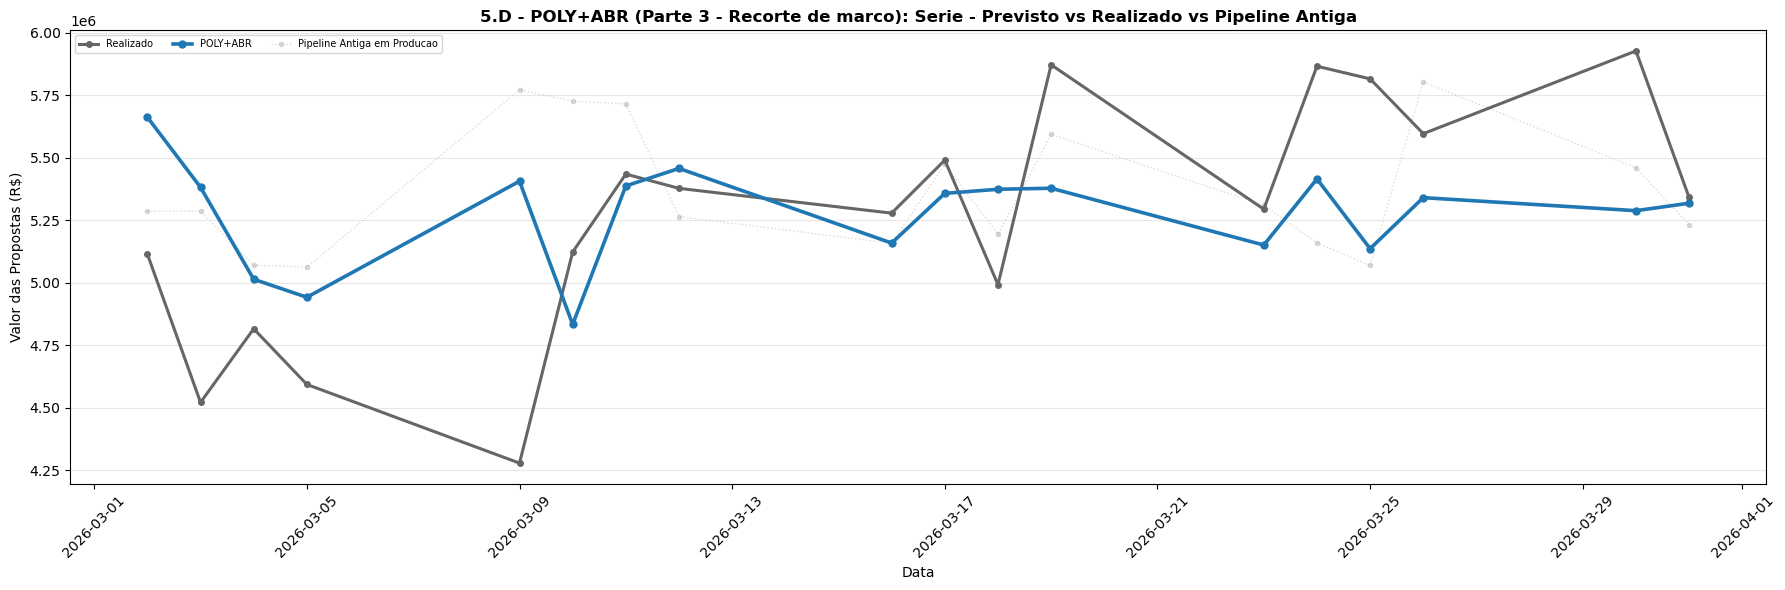

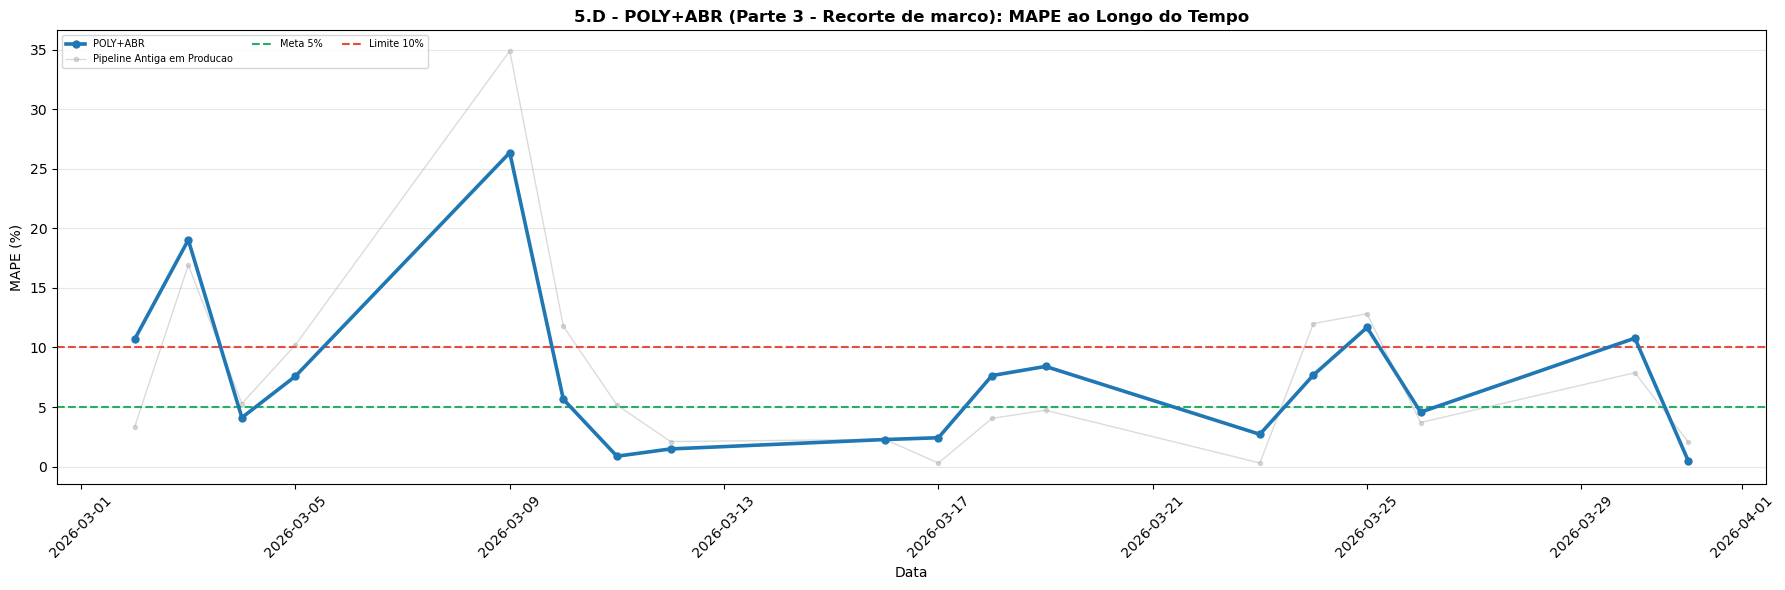

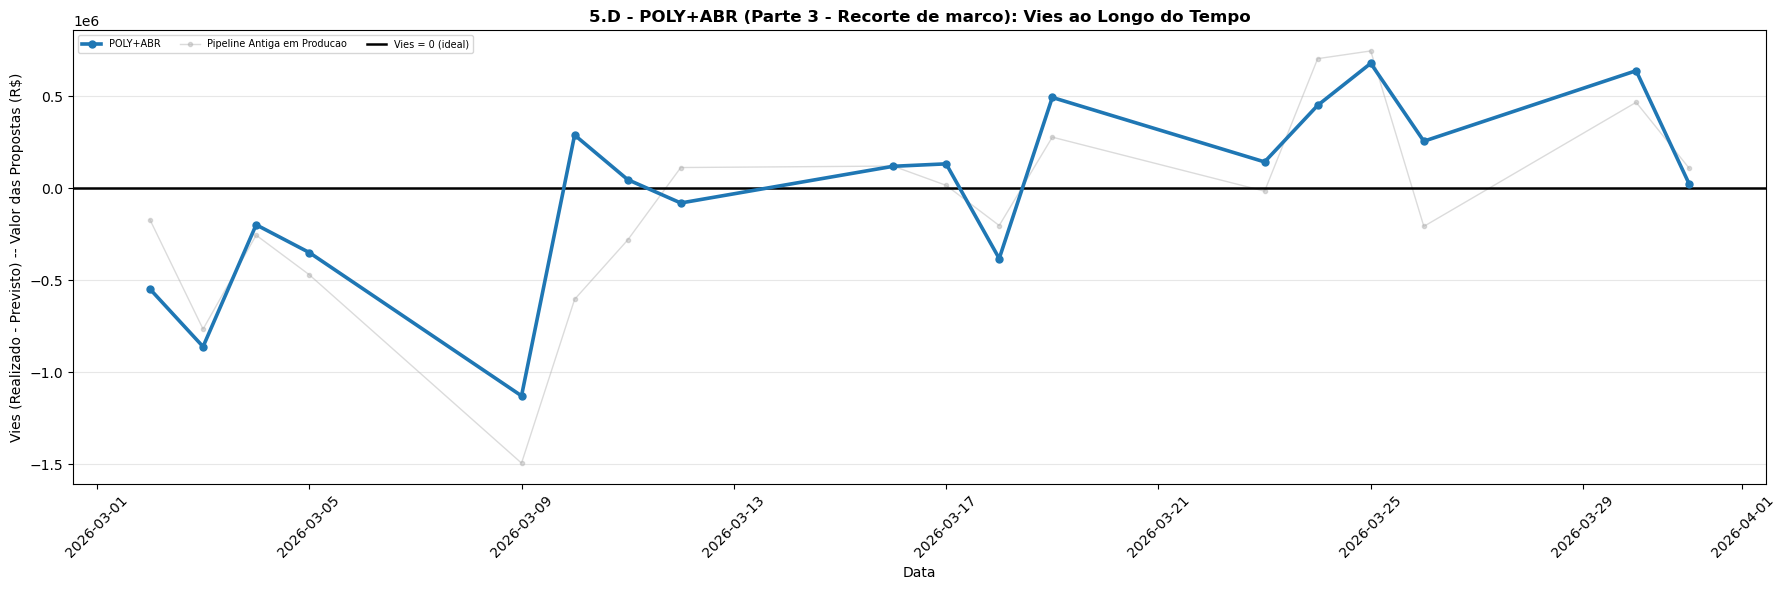


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,POLY+ABR,7.47,9.89,-0.04,-14958.20,14958.20,-1.08,378817.90,479715.10,9.11,6.62,0.43,26.36,8/18,13/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105978.80,105978.80,-2.86,389851.20,518702.30,9.86,4.95,0.29,34.90,9/18,12/18,18



### 5.D - POLY+ABR | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


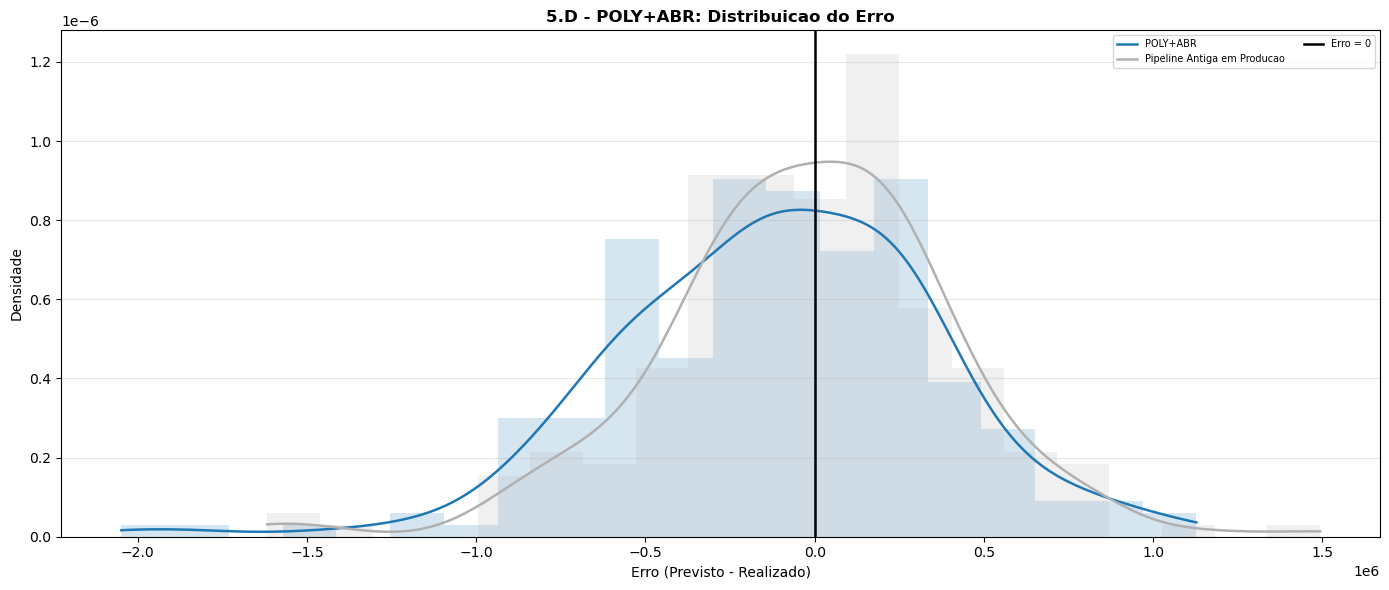

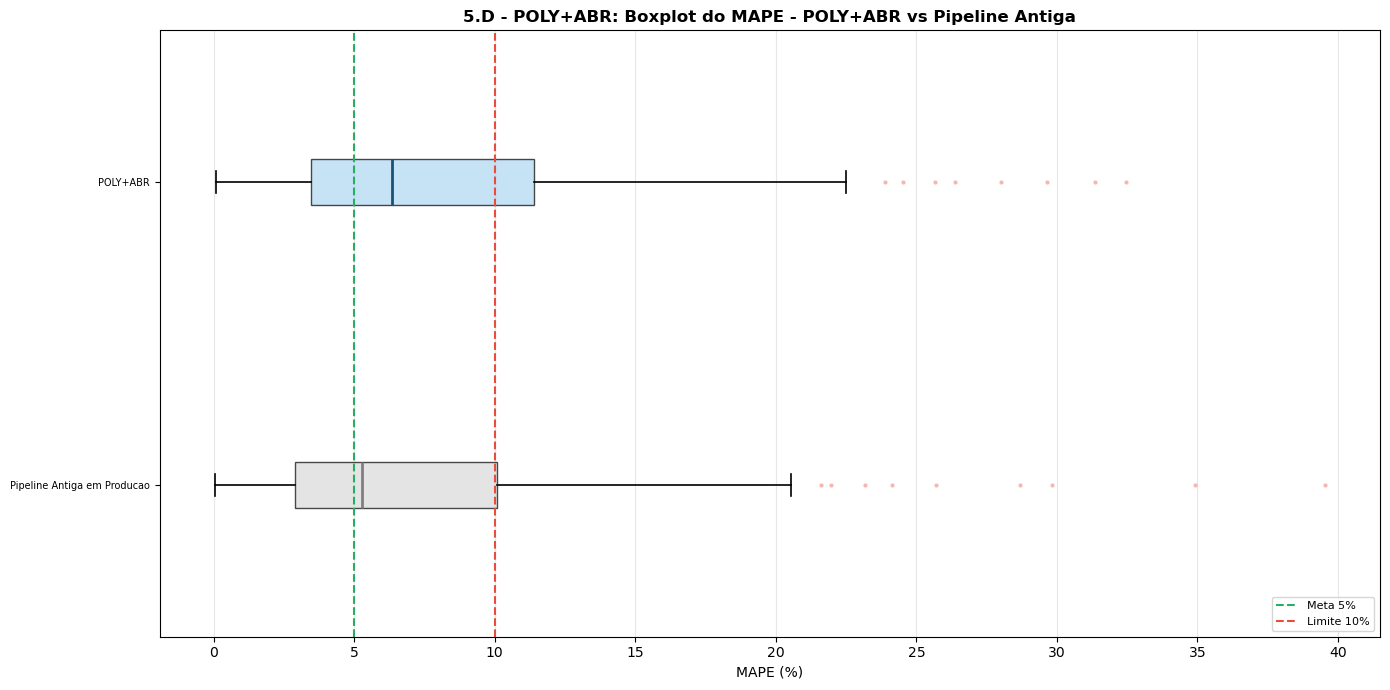

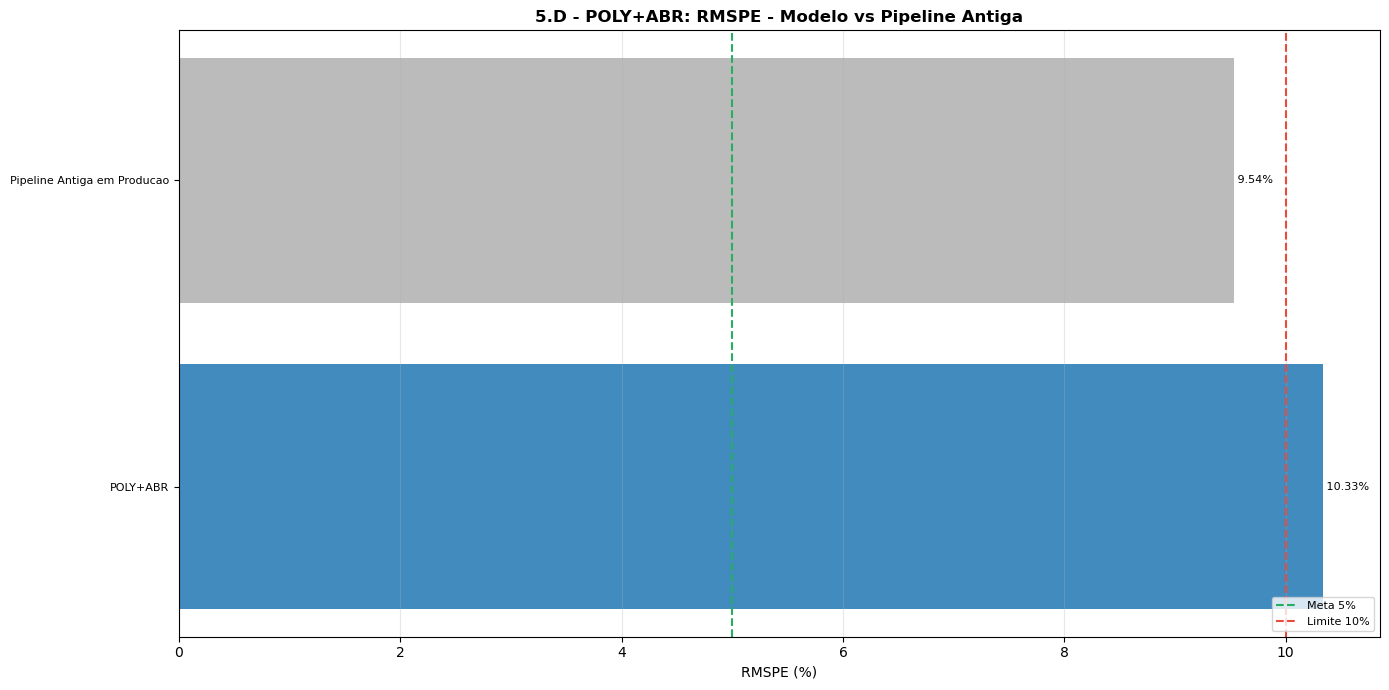

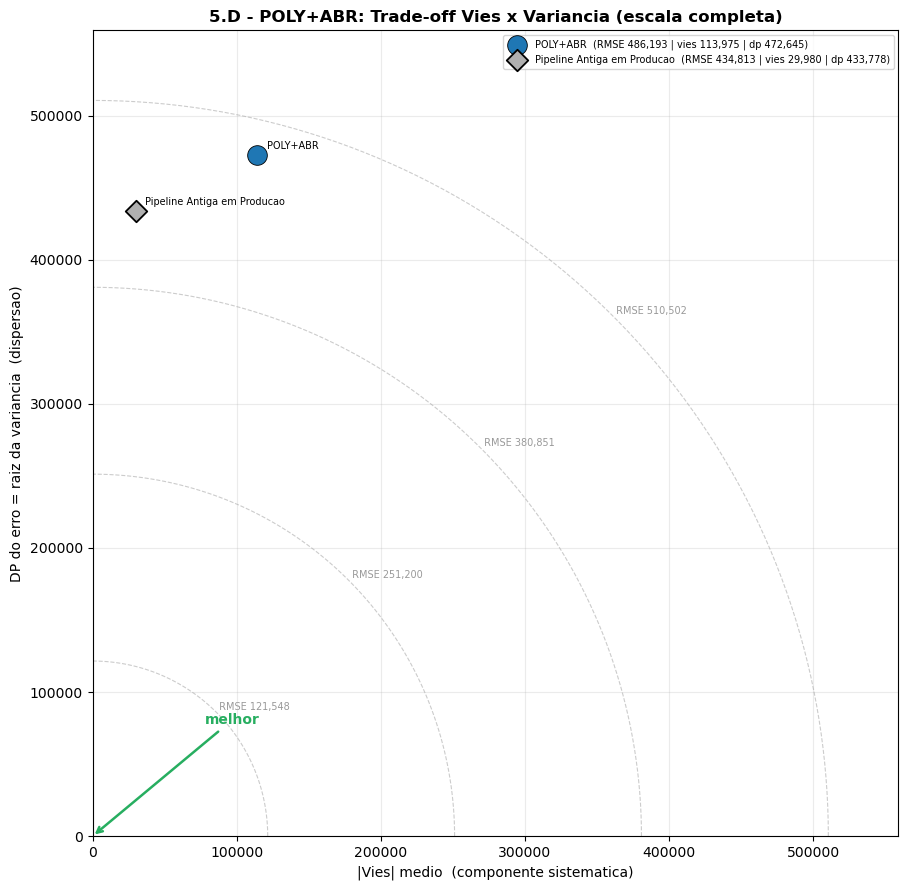


-- Metricas por mes -- POLY+ABR:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,POLY+ABR,2025-02,3.43,4.63,0.35,109568.80,109568.80,2.39,152169.50,180753.10,4.15,2.60,0.09,11.16,7/10,9/10,10
1,POLY+ABR,2025-03,10.08,13.58,0.37,-147730.80,147730.80,-5.33,381724.00,449071.30,11.08,9.37,0.15,32.44,3/9,6/9,9
2,POLY+ABR,2025-04,10.18,12.44,-0.43,-112355.60,112355.60,-4.13,355093.20,406309.70,11.20,7.61,1.66,25.65,3/13,8/13,13
3,POLY+ABR,2025-05,8.41,10.28,0.19,-146584.70,146584.70,-5.21,260801.50,273390.90,8.37,6.37,1.18,18.36,5/15,9/15,15
4,POLY+ABR,2025-06,10.54,13.02,0.18,148470.30,148470.30,2.93,354952.70,397636.70,11.74,9.60,0.52,31.36,2/13,7/13,13
5,POLY+ABR,2025-07,9.28,11.68,-1.04,200669.80,200669.80,4.20,411203.00,498066.30,11.59,5.96,2.48,24.51,6/17,11/17,17
6,POLY+ABR,2025-08,6.31,7.59,-0.34,157819.20,157819.20,3.14,288414.20,315938.50,7.00,5.38,0.13,16.98,7/16,13/16,16
7,POLY+ABR,2025-09,6.91,8.77,-0.20,107043.50,107043.50,1.72,323688.80,409459.80,8.95,5.79,0.41,19.42,8/18,14/18,18
8,POLY+ABR,2025-10,6.59,7.93,-0.66,200990.50,200990.50,3.80,322819.60,339695.20,7.07,6.90,0.31,13.76,6/14,10/14,14
9,POLY+ABR,2025-11,8.24,9.35,-0.60,139960.90,139960.90,2.36,407343.80,442844.90,9.02,7.27,2.78,17.21,3/14,10/14,14


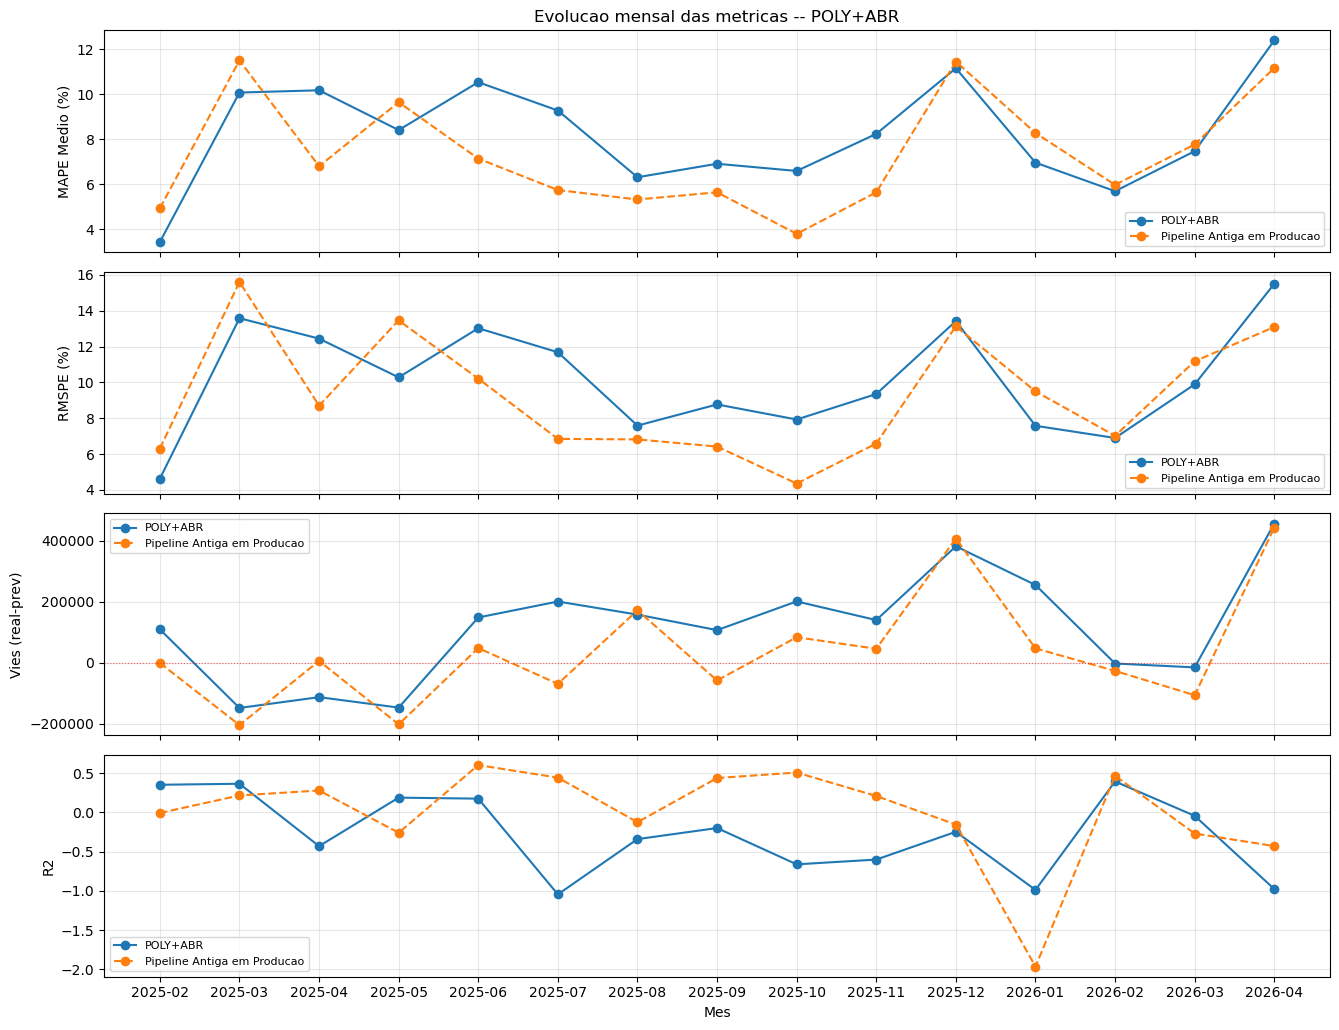


### 5.D - SE(ETR)+ABR | Parte 1 - Historico completo


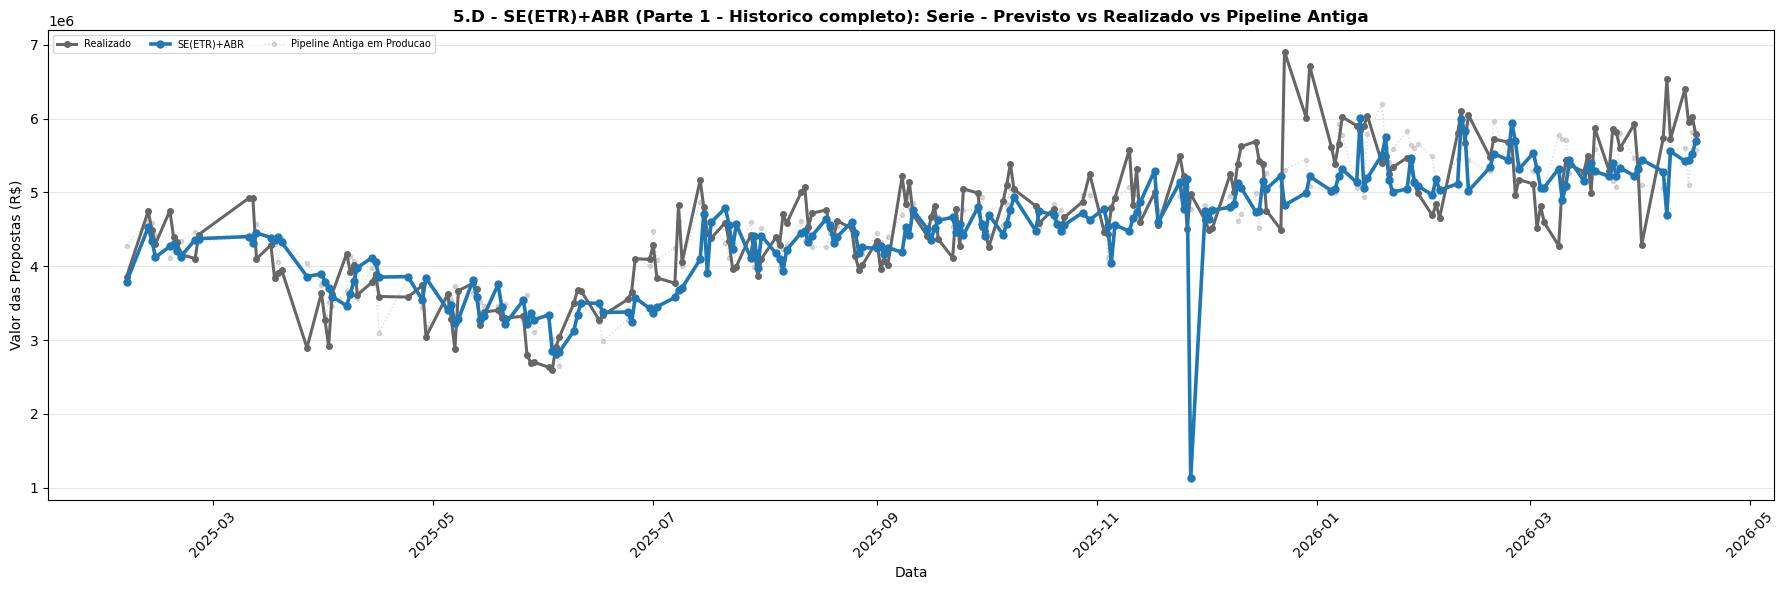

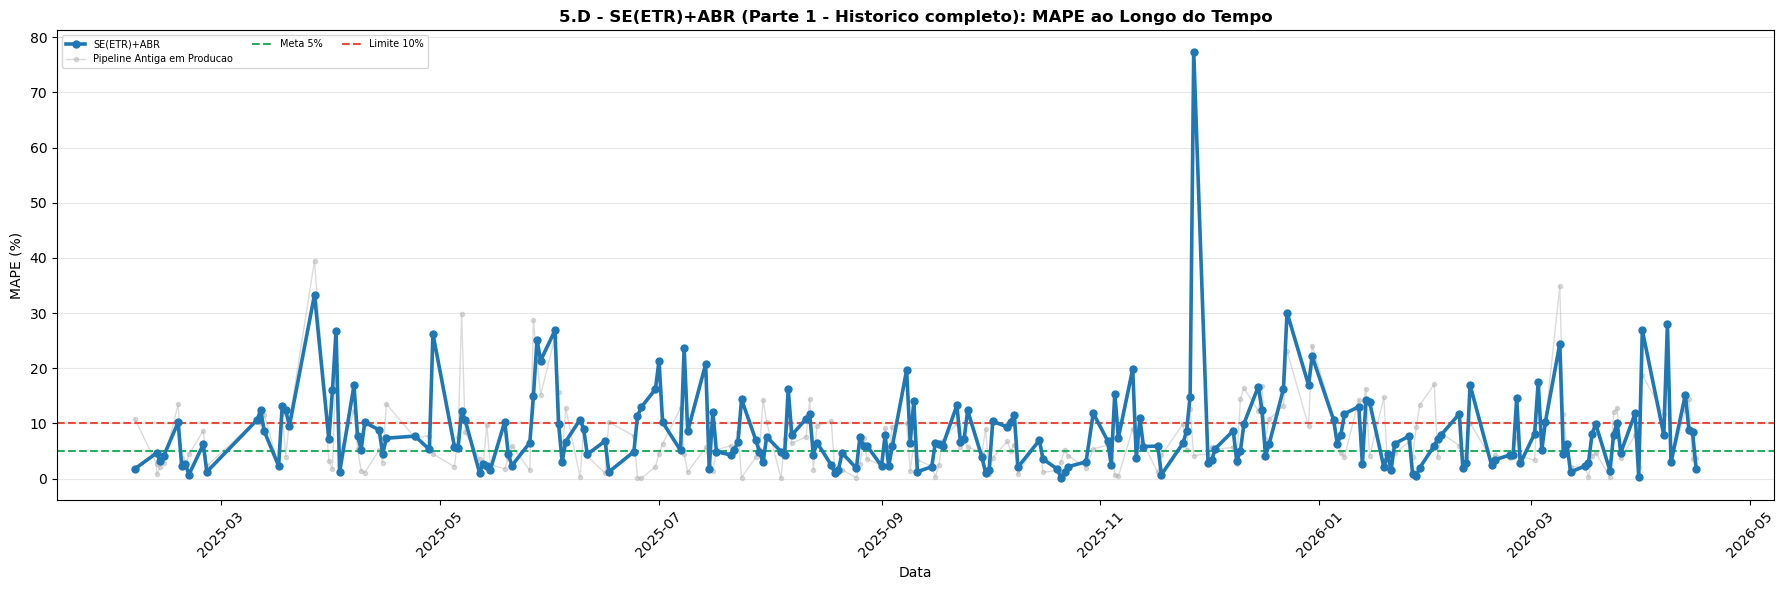

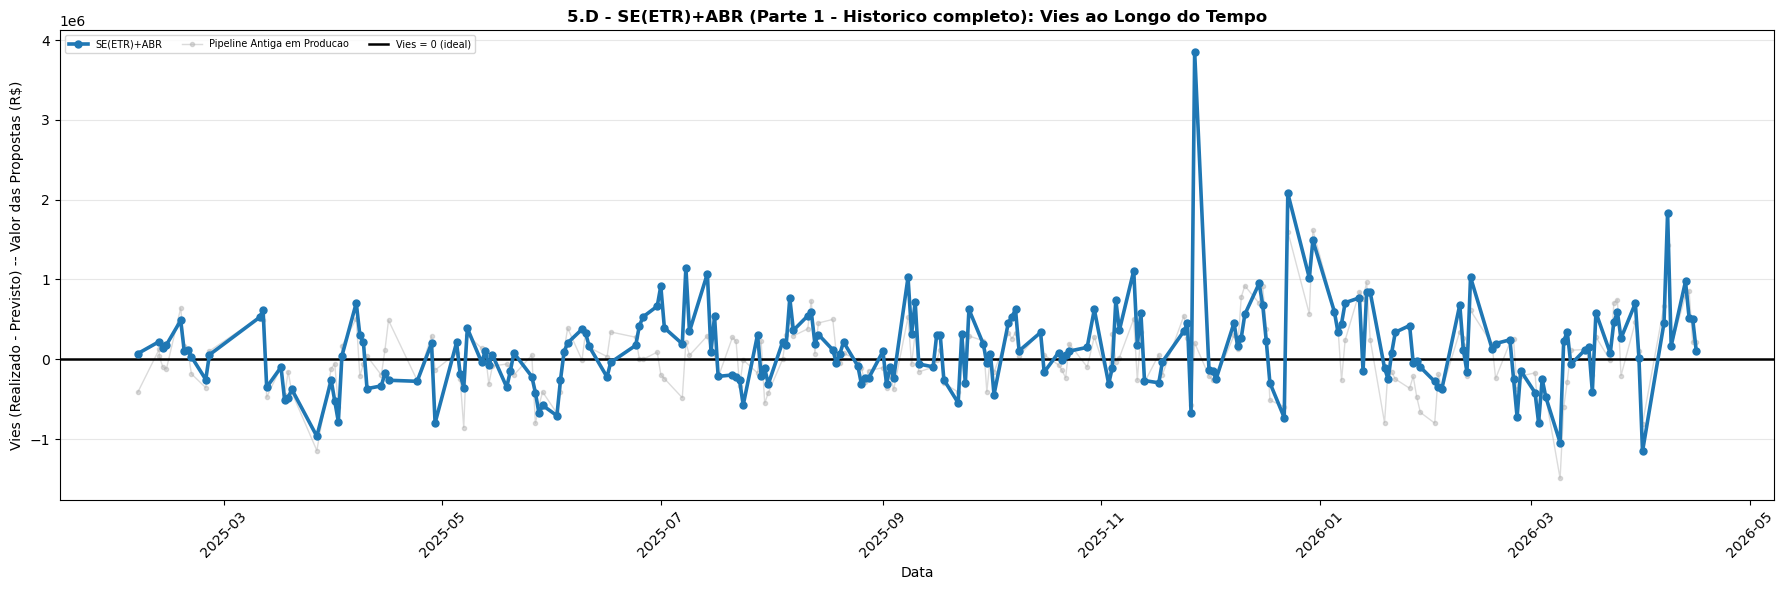


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SE(ETR)+ABR,8.53,11.72,0.58,130733.20,130733.20,1.69,393640.20,543600.00,11.78,6.55,0.10,77.39,79/209,143/209,209
1,Pipeline Antiga em Producao,7.19,9.54,0.75,29980.40,29980.40,-0.30,328752.10,433778.40,9.38,5.29,0.05,39.52,97/211,156/211,211



### 5.D - SE(ETR)+ABR | Parte 2 - Janeiro em diante


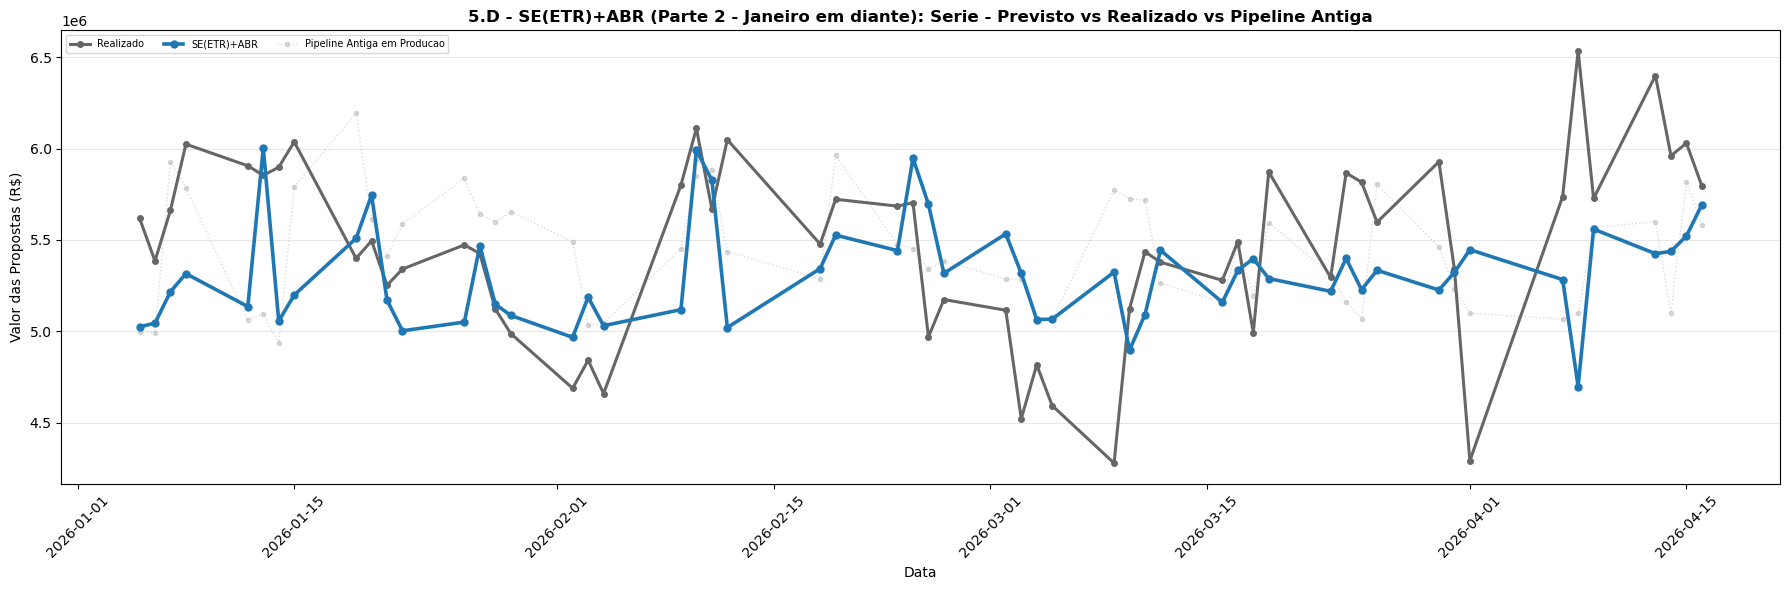

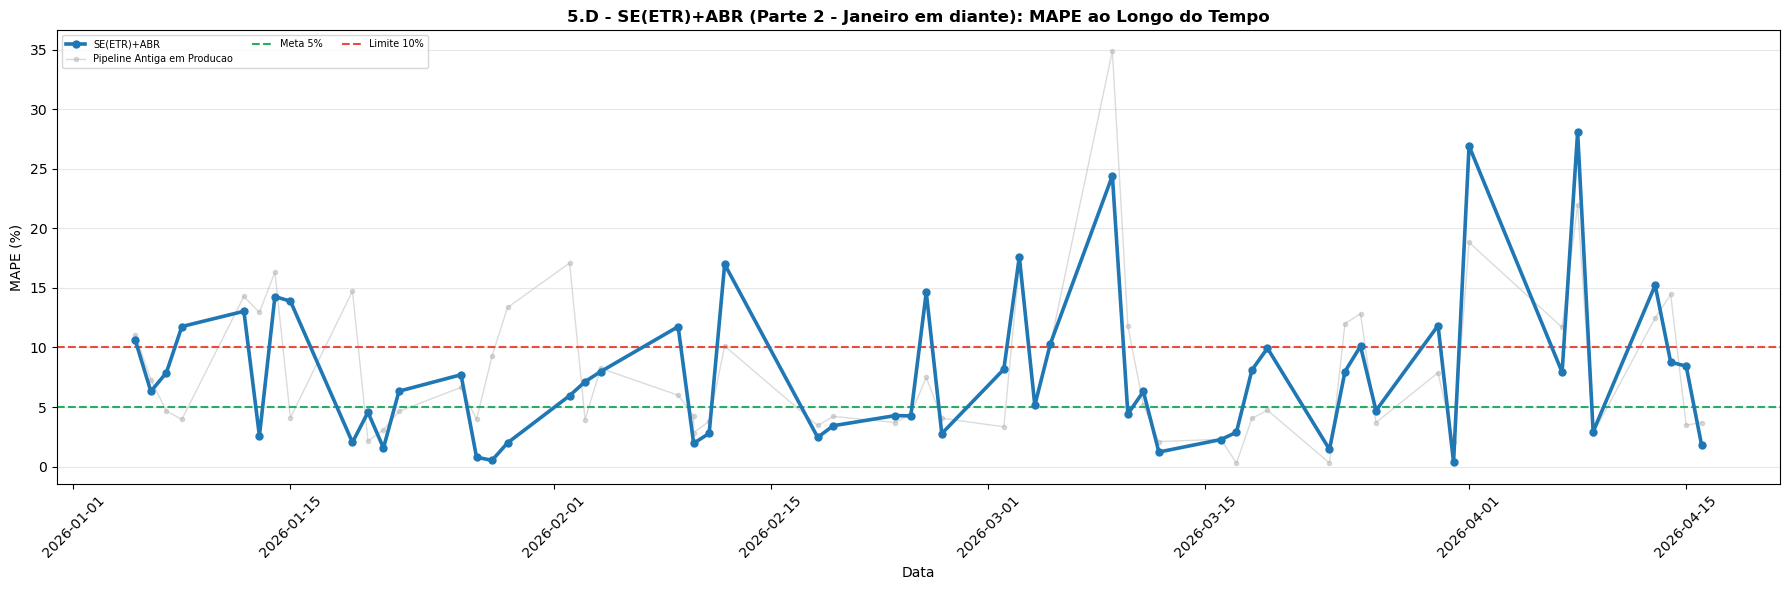

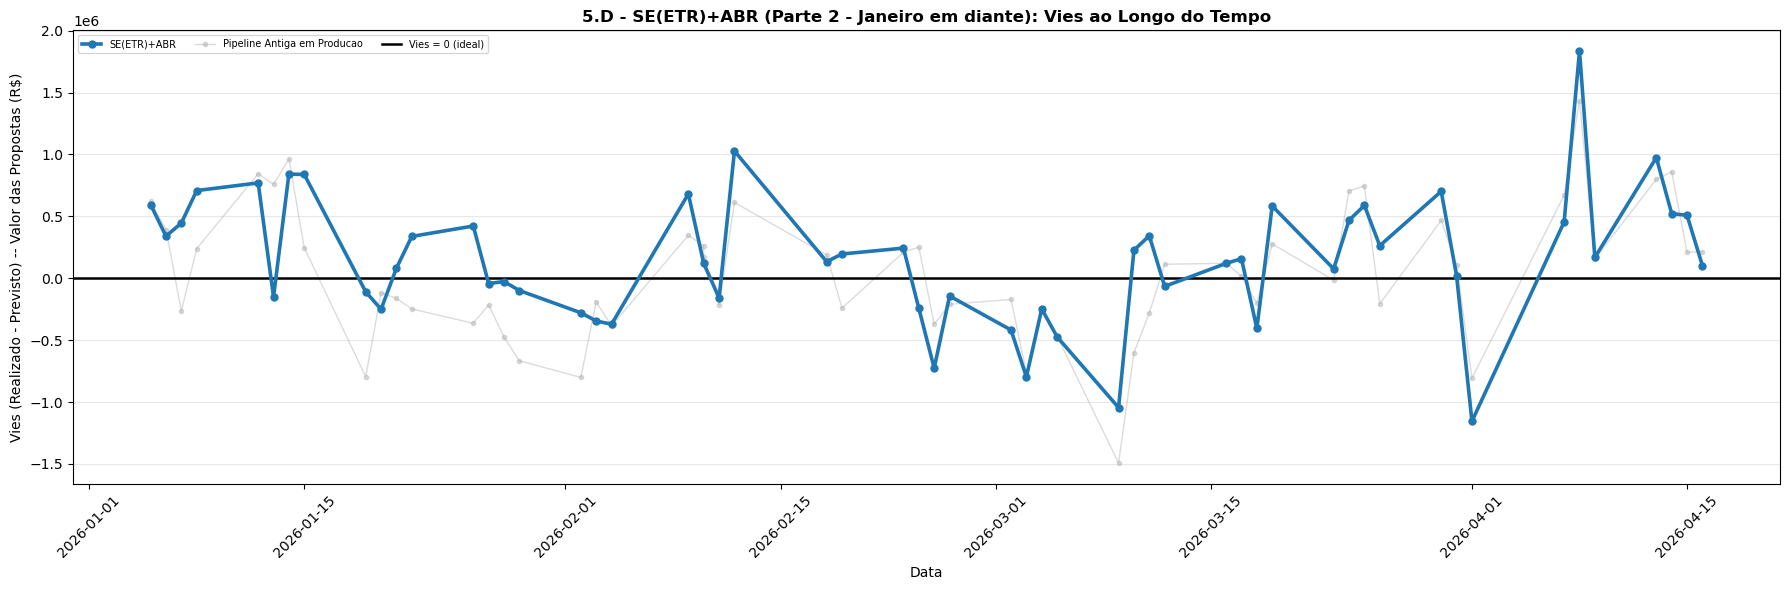


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SE(ETR)+ABR,7.81,10.06,-0.22,151741.10,151741.10,2.00,426335.90,529200.50,9.68,6.33,0.37,28.10,23/55,39/55,55
1,Pipeline Antiga em Producao,7.95,10.14,-0.15,36022.20,36022.20,-0.11,428638.30,534534.70,9.76,4.95,0.29,34.90,28/56,37/56,56



### 5.D - SE(ETR)+ABR | Parte 3 - Recorte de marco


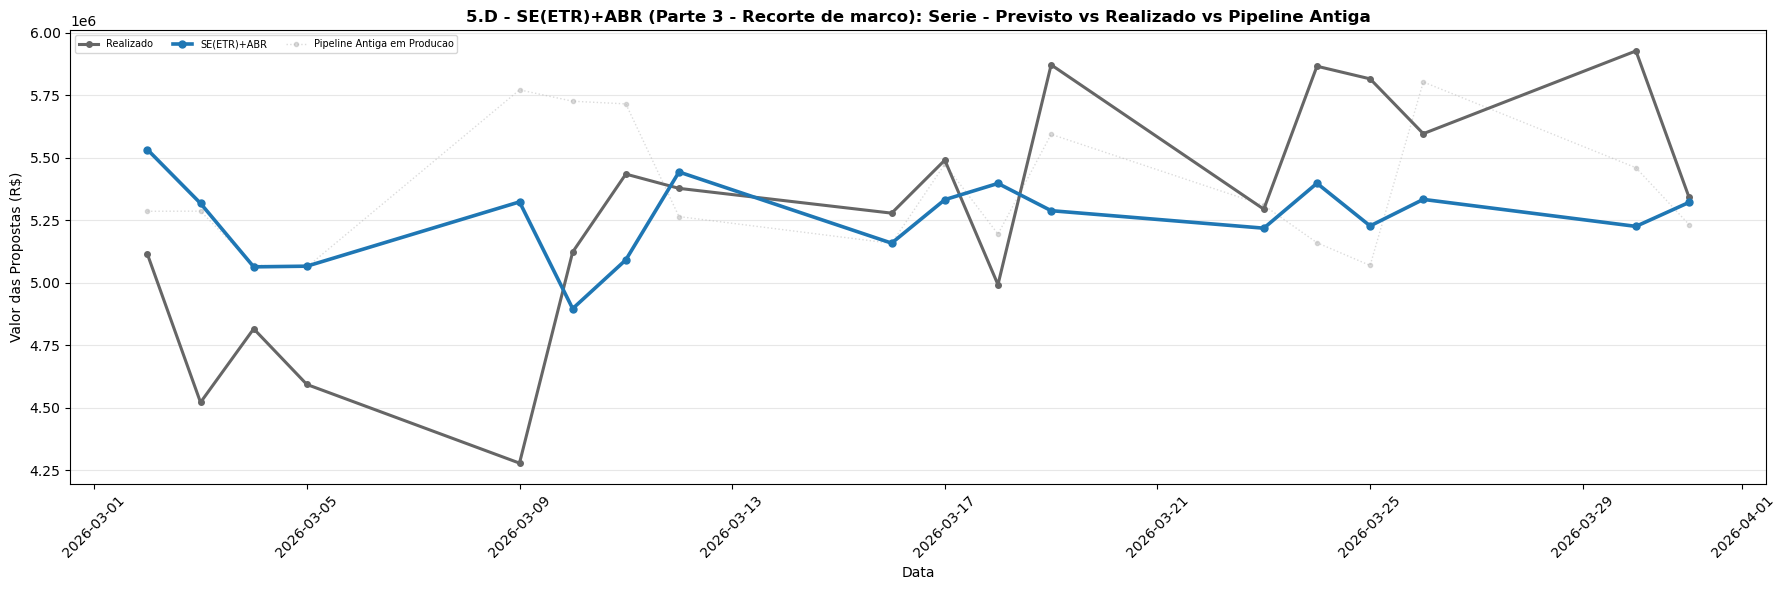

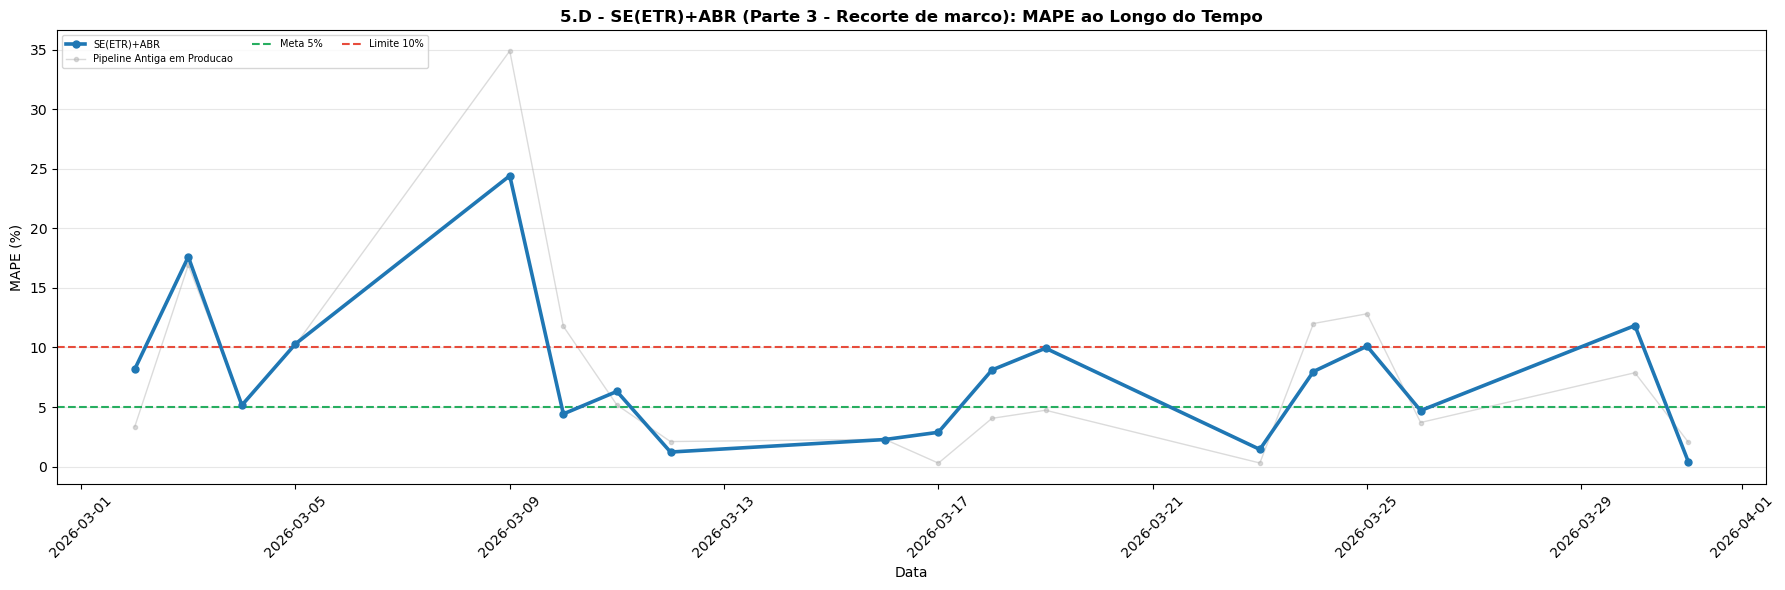

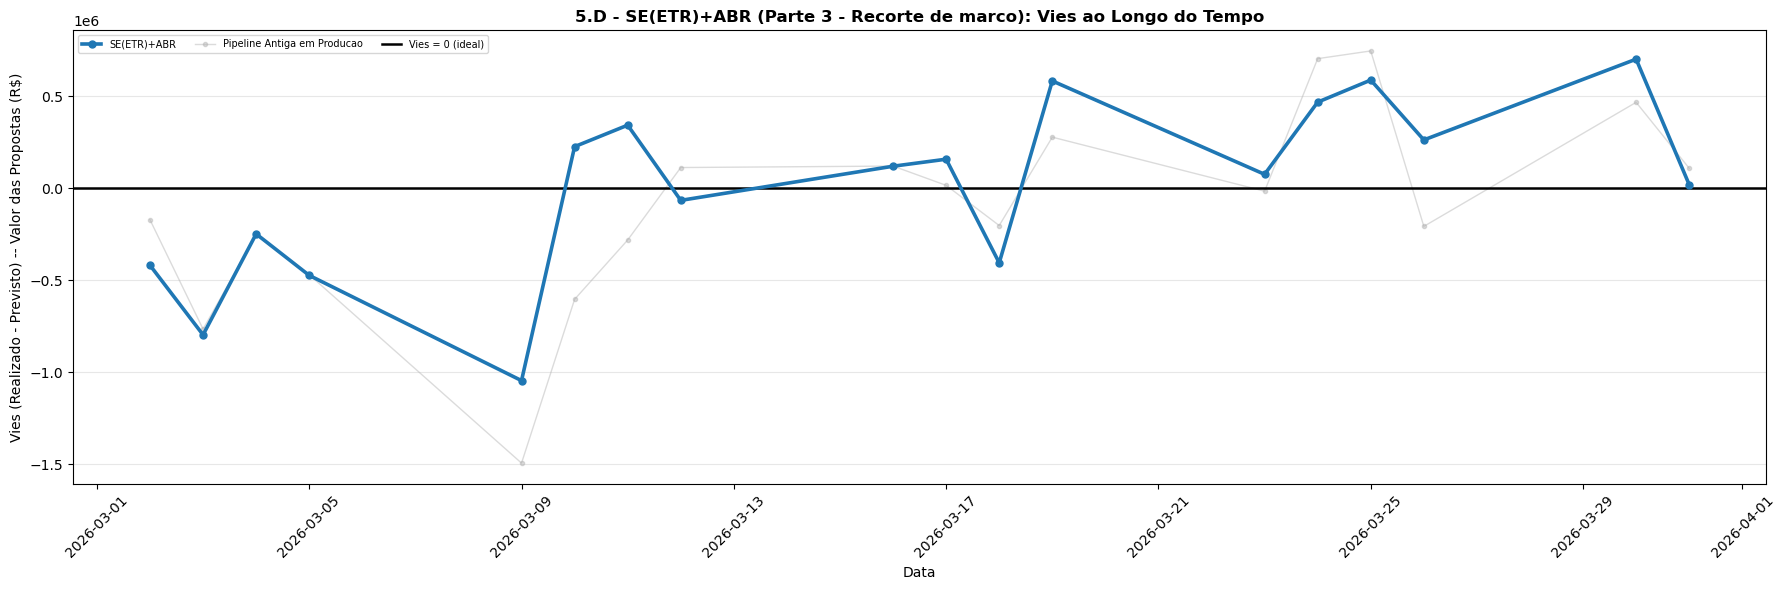


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SE(ETR)+ABR,7.62,9.65,-0.01,5406.90,5406.90,-0.71,388843.80,473532.50,9.00,7.14,0.37,24.42,7/18,13/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105978.80,105978.80,-2.86,389851.20,518702.30,9.86,4.95,0.29,34.90,9/18,12/18,18



### 5.D - SE(ETR)+ABR | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


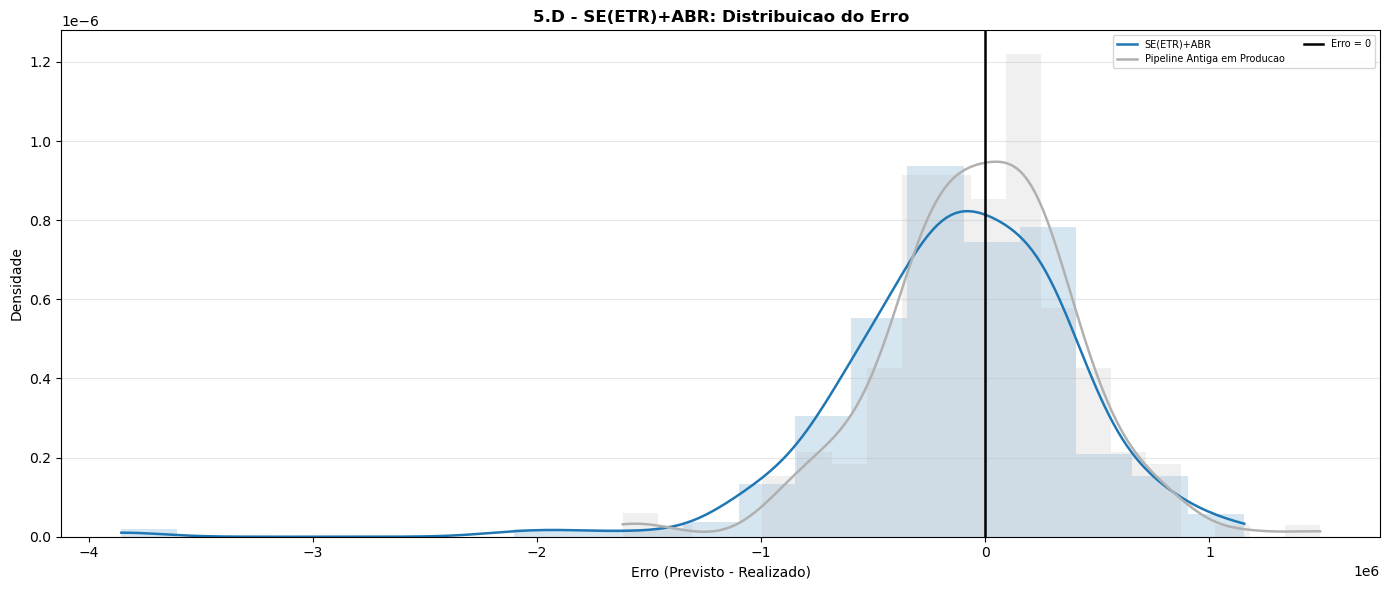

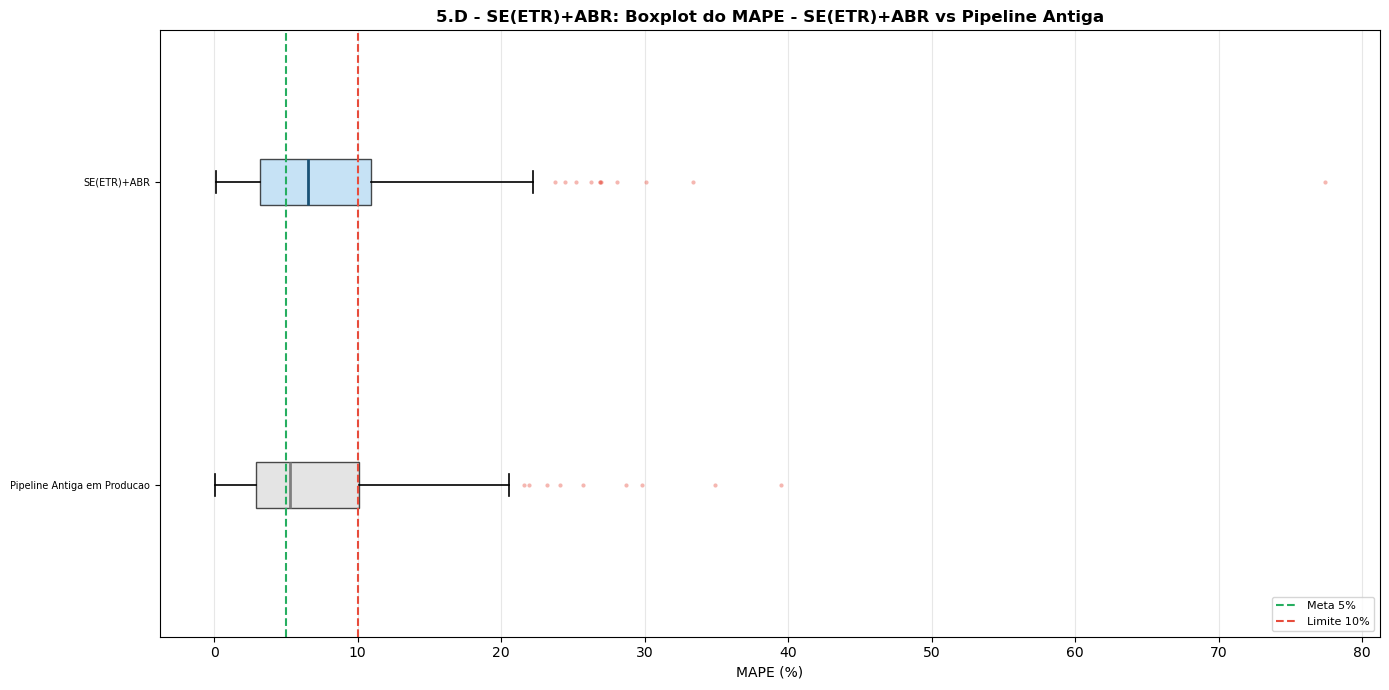

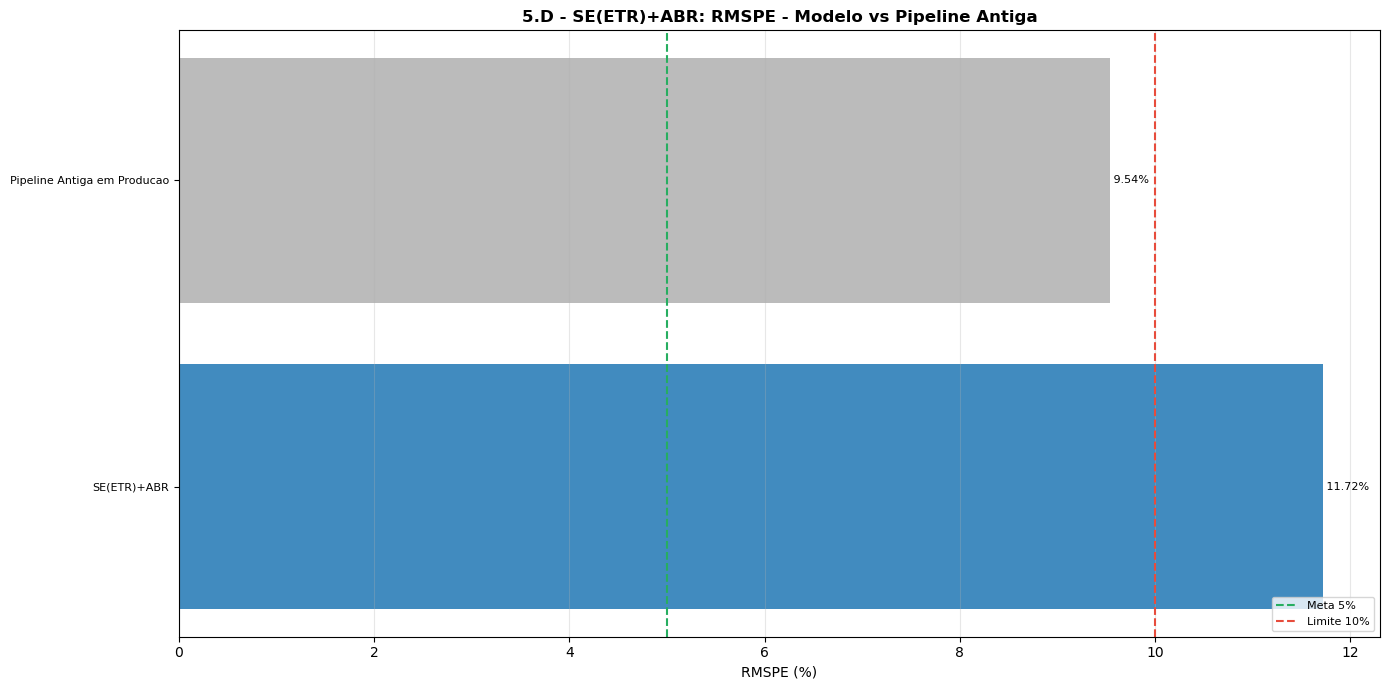

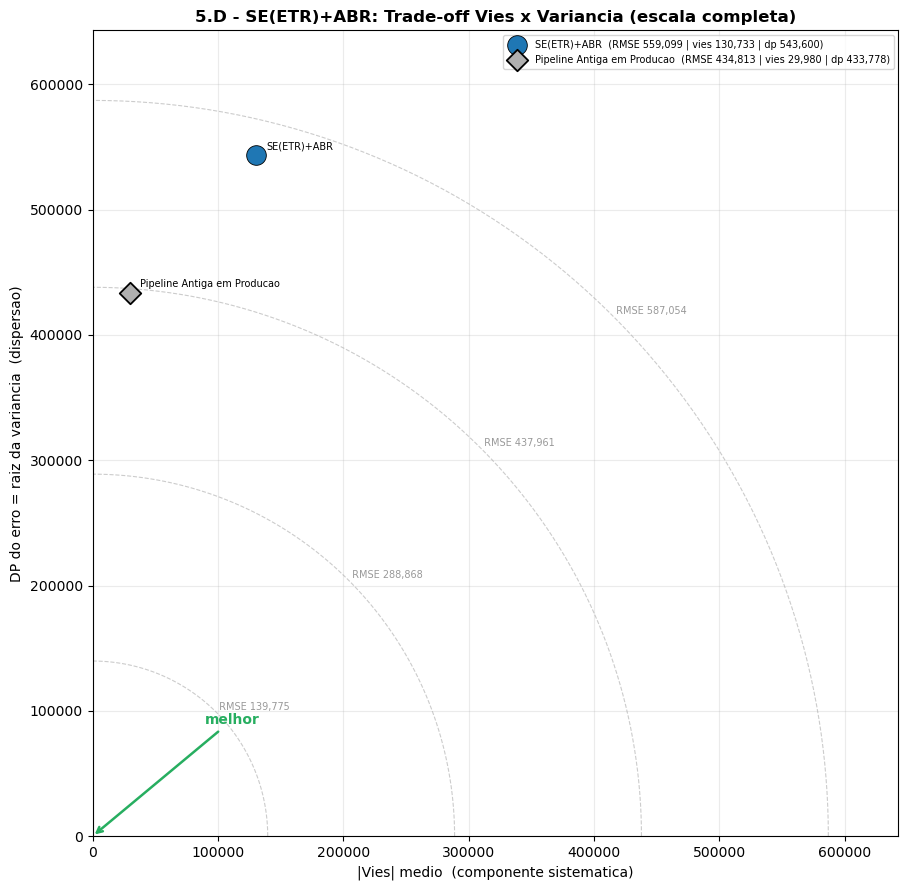


-- Metricas por mes -- SE(ETR)+ABR:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SE(ETR)+ABR,2025-02,3.71,4.58,0.37,114377.50,114377.50,2.47,165280.80,174167.00,4.00,2.92,0.73,10.22,8/10,9/10,10
1,SE(ETR)+ABR,2025-03,12.18,14.64,0.24,-212270.20,212270.20,-7.05,464694.60,472703.30,11.66,10.65,2.31,33.34,1/9,4/9,9
2,SE(ETR)+ABR,2025-04,11.08,13.54,-0.63,-158766.20,158766.20,-5.49,383358.30,420484.60,11.59,7.73,1.15,26.85,2/13,8/13,13
3,SE(ETR)+ABR,2025-05,8.48,11.07,0.13,-147463.70,147463.70,-5.41,258358.10,284847.10,8.72,5.80,1.05,25.21,6/15,9/15,15
4,SE(ETR)+ABR,2025-06,9.55,11.51,0.34,131907.00,131907.00,2.65,321077.90,355395.10,10.49,9.00,1.21,26.86,4/13,8/13,13
5,SE(ETR)+ABR,2025-07,9.51,11.55,-0.96,170274.90,170274.90,3.52,418552.90,497607.50,11.58,6.93,1.83,23.77,5/17,11/17,17
6,SE(ETR)+ABR,2025-08,6.12,7.28,-0.25,166203.30,166203.30,3.33,280539.80,298061.20,6.61,5.39,0.99,16.26,8/16,13/16,16
7,SE(ETR)+ABR,2025-09,6.93,8.48,-0.12,108239.80,108239.80,1.74,324865.40,395346.60,8.65,6.37,1.06,19.67,6/18,14/18,18
8,SE(ETR)+ABR,2025-10,5.43,6.89,-0.27,179955.60,179955.60,3.42,267324.40,293924.90,6.12,3.30,0.10,11.88,8/14,10/14,14
9,SE(ETR)+ABR,2025-11,13.32,22.79,-8.64,424596.30,424596.30,8.07,665577.60,1057405.40,21.54,7.14,0.73,77.39,3/14,9/14,14


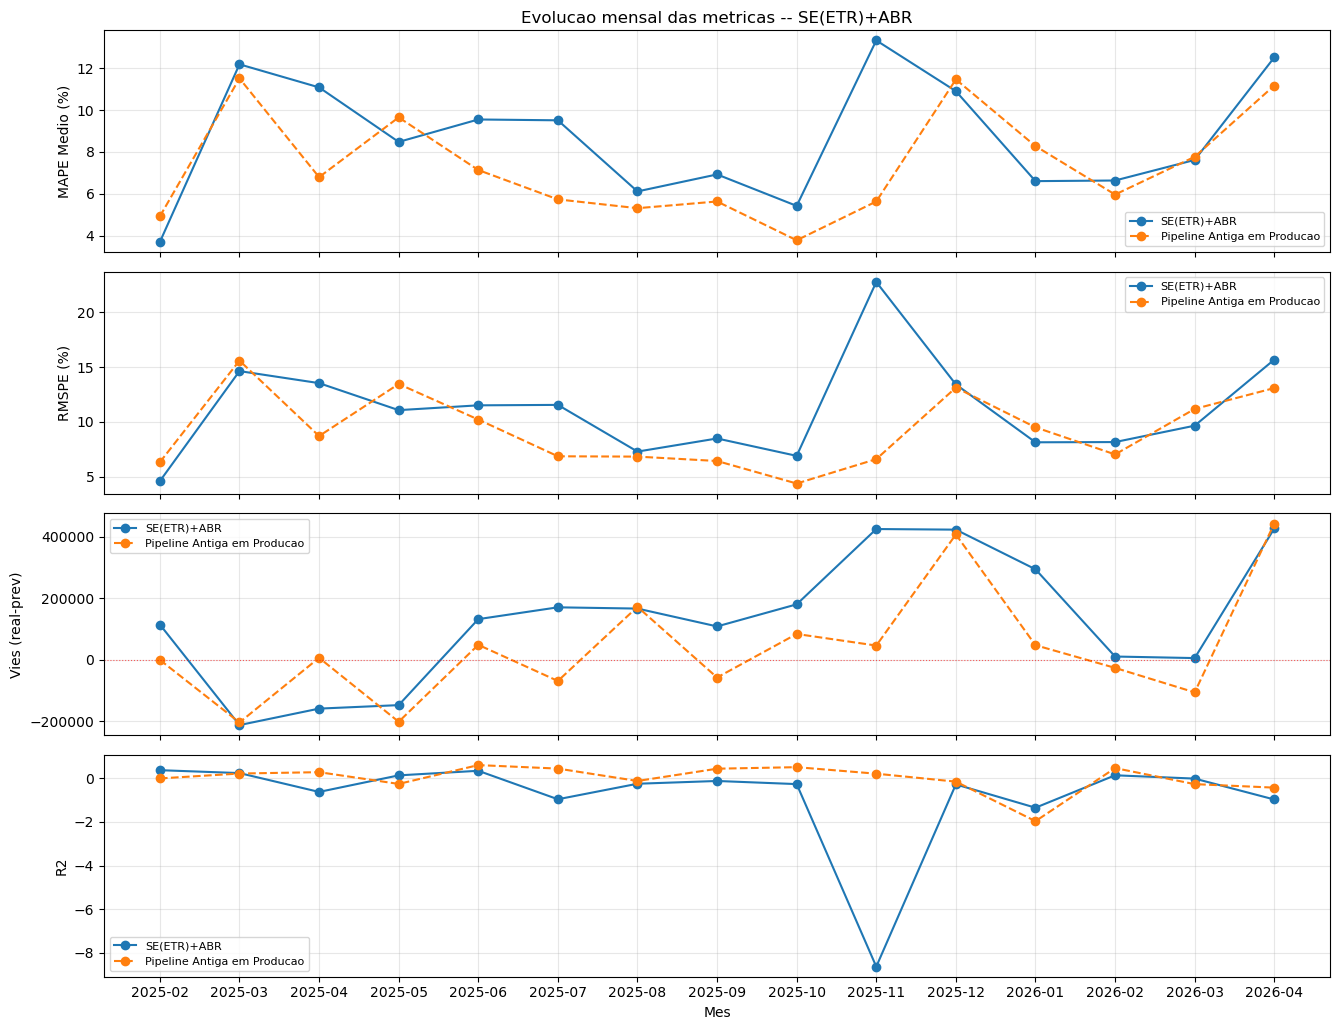

COMPARATIVO  |  POLY+ABR   vs   Pipeline Antiga em Producao
Metrica                     Modelo   Pipeline Antiga         Delta   Resultado
------------------------------------------------------------------------------------
MAPE Medio (%)                8.12              7.19         +0.93   pior
RMSPE (%)                    10.33              9.54         +0.79   pior
R2                           0.684             0.748         -0.06   pior
Vies (real-prev)          113974.9           29980.4     +83994.50   
|Vies|                    113974.9           29980.4     +83994.50   pior
MAE                       373792.8          328752.1     +45040.70   pior
DP Erro                   472644.7          433778.4     +38866.30   pior
Mediana (%)                   6.34              5.29         +1.05   pior
N                              209               211         -2.00   
COMPARATIVO  |  SE(ETR)+ABR   vs   Pipeline Antiga em Producao
Metrica                     Modelo   Pipeline Antiga   

In [ ]:
comparar_modelo(['POLY+ABR', 'SE(ETR)+ABR'])


In [ ]:
import pandas as pd
d = pd.to_datetime(pd.read_pickle(r'resultados\datas_avaliadas_valor.pkl'))
print('valor: total dias =', d.nunique(), '| sextas =', (d.dt.dayofweek==4).sum())
print('março:', d[(d>='2026-03-01')&(d<='2026-03-31')].nunique(),
    '| janeiro:', d[(d>='2026-01-01')&(d<='2026-01-31')].nunique())

valor: total dias = 202 | sextas = 0
março: 18 | janeiro: 16
